# Methods for Data Science: Coursework 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import defaultdict

We're going to introduce some auxiliary functions prior to commencing the tasks.

The `standardise()` function standardizes a set of inputs, using the provided mean $\operatorname{mean}$ and standard deviation $\operatorname{std}$.

In [2]:
def standardise(X, mean, std):
    """
    Parameters
    ----------
    :param X : (numpy.ndarray) of shape (N, D)
        Matrix of inputs.
    :param mean:
        Mean used for standardisation.
    :param std:
        Standard deviation used for standardisation.

    Returns
    ----------
    :rtype: (numpy.ndarray) of shape (N, D)
    :return: Standardised input.
    """

    return (X - mean) / std

To facilitate cross-validation, the `generate_folds()` function produces folds. Moreover, to ensure that the results can be reproduced, we are passing a random generator to this function as an argument.

*Note*: By providing a seed value to `np.random.default_rng()`, the randomness of its number generation can be made predictable.

In [3]:
def generate_folds(
        num_instances,
        num_folds=5,
        random_generator=np.random.default_rng(),
):
    """
    Parameters
    ----------
    :param num_instances: (int).
        Number of indexes.
    :param num_folds: (int).
        Number of folds.
    :param random_generator: (np.Generator), optional, default=np.random.default_rng().
        Random generator used for shuffling the indexes.

    Returns
    ----------
    :rtype: (list)
    :return: Folds.
    """

    if random_generator is None:
        return np.array_split(np.arange(num_instances), num_folds)

    shuffled_indexes = random_generator.choice(
        np.arange(num_instances),
        size=num_instances,
        replace=False
    )

    return np.array_split(shuffled_indexes, num_folds)

Using the given validation indices, the `get_train_val_sets()` function divides the inputs and outputs into training and validation sets.

In [4]:
def get_train_val_sets(X, y, val_fold):
    """
    Parameters
    ----------
    :param X: (numpy.ndarray) of shape (N, D).
        Input data.
    :param y: (numpy.ndarray) of shape (N, 1).
        Output data.
    :param val_fold: (list).
        Validation fold.

    Returns
    ----------
    :rtype: (tuple)
    :return:
        (numpy.ndarray) X_train (Train input)
        (numpy.ndarray) y_train (Train output)
        (numpy.ndarray) X_val (Validation input)
        (numpy.ndarray) y_val (Validation output)
    """

    N = X.shape[0]  # number of samples

    # Extract the train and validation indexes.
    val_indexes = val_fold
    train_indexes = list(set(range(N)) - set(val_indexes))

    # Extract the training data.
    X_train = X[train_indexes, :]
    y_train = y[train_indexes]

    # Extract the validation data.
    X_val = X[val_indexes, :]
    y_val = y[val_indexes]

    return X_train, y_train, X_val, y_val

## Task 1:  Regression (50 marks)

Load the dataset and preview it.

In [5]:
# Load the datasets.
airfoil_noise_samples = pd.read_csv('airfoil_noise_samples.csv')
airfoil_noise_test = pd.read_csv('airfoil_noise_test.csv')

# Visualise the first 5 rows.
airfoil_noise_samples.head(5)

,Frequency,Angle,Displacement,Chord length,Velocity,Thickness,Sound Pressure
0,2175.611424,15.138865,21.075119,0.088194,66.764401,0.044771,122.365215
1,2962.923620,13.400893,13.200889,0.048462,78.221903,0.011041,129.296236
2,4430.810843,2.164599,13.959536,0.226743,57.053201,0.011499,121.827380
3,4939.695645,13.857682,18.203793,0.021705,23.896377,0.021475,114.998132
4,2193.979785,9.298757,11.007713,0.052737,38.917034,0.001741,125.639641


Print summaries of the training labels.

In [6]:
airfoil_noise_samples["Sound Pressure"].describe()

count    3890.000000
mean      123.970283
std         4.775422
min       102.372432
25%       120.890188
50%       124.111408
75%       127.204799
max       140.469281
Name: Sound Pressure, dtype: float64

We notice that the outputs have a mean of $\approx 123.9$ and a standard deviation of $\approx 4.7$.

Extract the predictors and true labels and then standardise the data.

In [7]:
# Extract the predictors and true labels.
X_train = airfoil_noise_samples.drop(columns=["Sound Pressure"]).to_numpy()  # size (N_train, D)
y_train = airfoil_noise_samples["Sound Pressure"].to_numpy().reshape((-1, 1))  # size (N_train, 1)

# Extract the mean and std of the train inputs.
X_train_mean = np.mean(X_train, axis=0)  # shape (D, 1)
X_train_std = np.std(X_train, axis=0)  # shape (D, 1)

# Standardise the training inputs.
X_train = standardise(X_train, X_train_mean, X_train_std)

# Print the shapes of the arrays.
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (3890, 6)
y_train shape: (3890, 1)


In [8]:
# Extract the predictors and true labels.
X_test = airfoil_noise_test.drop(columns=["Sound Pressure"]).to_numpy()  # size (N_test, D)
y_test = airfoil_noise_test["Sound Pressure"].to_numpy().reshape((-1, 1))  # size (N_test, 1)

# Standardise the test inputs using the train set's mean and std.
X_test = standardise(X_test, X_train_mean, X_train_std)

# Print the shapes of the arrays.
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (973, 6)
y_test shape: (973, 1)


#### 1.0 Helper Functions

Before starting the tasks, we will introduce some additional functions.

##### 1.0.1 Prediction function

The `predict_linear()` function will return the linear predictions:
$$
y_{\text{pred}} = X \beta + \beta_0
$$
where
- $X$ is the matrix $N \times D$ of inputs, where
    - $N$ is the number of input samples.
    - $D$ is the number of features.
- $\beta = (\beta_1, \beta_2, \ldots, \beta_{D})^T$ is the matrix $D \times 1$ of parameters.
- $\beta_0$ is a scalar representing the offset (intercept).

In [9]:
def predict_linear(X, params, offset=0):
    """
    Parameters
    ----------
    :param X: (numpy.ndarray) of shape (N, D)
        Matrix of inputs.
    :param params: (numpy.ndarray) of shape (D, 1)
        Vector of parameters.
    :param offset: (scalar)
        Offset.

    Returns
    ----------
    :rtype: (numpy.ndarray) of shape (N, 1)
    :return: Prediction of X @ params + offset.
    """

    return X @ params + offset

##### 1.0.2 Metrics

The `mse()` function returns the Mean Squared Error (MSE) of some predictions given the true values:
$$
\text{MSE} (y_{\text{true}}, y_{\text{pred}})
    = \frac{1}{N} \sum_{i = 1}^N (y_{\text{true}}^{(i)} - y_{\text{pred}}^{(i)})^2
$$
where
- $y_{\text{true}}$ is the vector of true values.
- $y_{\text{pred}}$ is the vector of predicted values.

MSE is a useful metric in evaluating the overall performance of a model because it provides a quantitative measure of the magnitude of the errors between the predicted and actual values in a dataset.
It penalizes larger errors more severely than smaller errors. Hence, the lower it is, the better the model's performance, as it indicates that the predicted values are closer to the actual values.

In [10]:
def mse(y_true, y_pred):
    """
    Parameters
    ----------
    :param y_true: (numpy.ndarray) of shape (N, 1)
        Vector of true values.
    :param y_pred: (numpy.ndarray) of shape (N, 1)
        Vector of predicted values.

    Returns
    ----------
    :rtype: (scalar)
    :return: MSE error.
    """

    return np.mean((y_true - y_pred) ** 2)

The `r2_score()` function returns the R2-score of some predictions given the true values:
$$
R^2 (y_{\text{true}}, y_{\text{pred}})
    = 1 - \frac{\sum_{i=1}^n (y_{\text{true}}^{(i)} - y_{\text{pred}}^{(i)})^2}{\sum_{i=1}^n (y_{\text{true}}^{(i)} - \bar{y}_{\text{true}})^2}
$$
where
- $y_{\text{true}}$ is the vector of true values.
- $y_{\text{pred}}$ is the vector of predictions.
- $\bar{y}_{\text{true}}$ is the sample mean of the target variables.

R2-score is a useful metric for evaluating a model's performance because it provides a measure of how well the model fits the data.
Notice that
- $\sum_{i=1}^n (y_{\text{true}}^{(i)} - y_{\text{pred}}^{(i)})^2$ is the variation around the prediction line.
- $\sum_{i=1}^n (y_{\text{true}}^{(i)} - \bar{y}_{\text{true}})^2$ is the variation in the data.

A high R2 score indicates that the variation around the prediction line is small, hence the model is better at capturing the patterns in the data and is more accurate in predicting the outcome variable. Conversely, a low R2 score indicates that the variation around the prediction line is high, hence the model is not able to explain much of the variation in the dependent variable and is not performing well.
In addition, R2-score is independent of the scale of the data, which means that it can be used to compare the performance of models across different datasets or with different units of measurement.

In [11]:
def r2_score(y_true, y_pred):
    """
    Parameters
    ----------
    :param y_true: (numpy.ndarray) of shape (N, 1)
        Vector of true values.
    :param y_pred: (numpy.ndarray) of shape (N, 1)
        Vector of predicted values.

    Returns
    ----------
    :rtype: (scalar)
    :return: R2 score.
    """

    var_pred_error = np.sum((y_true - y_pred) ** 2)
    mean = np.mean(y_true)
    var_mean = np.sum((y_true - mean) ** 2)

    return 1 - var_pred_error / var_mean

The function `regression_metrics()` returns a dictionary containing the MSE and R2 score using the provided true labels and predictions.

In [12]:
def regression_metrics(y_true, y_pred):
    """
    Parameters
    ----------
    :param y_true: (numpy.ndarray) of shape (N, 1)
        Vector of true values.
    :param y_pred: (numpy.ndarray) of shape (N, 1)
        Vector of predicted values.

    Returns
    ----------
    :rtype: (dict)
    :return: Dictionary of regression metrics.
        (scalar) "mse": Mean Squared Error.
        (scalar) "r2_score": R2 score.
    """

    metrics = {
        "mse": mse(y_true, y_pred),
        "r2_score": r2_score(y_true, y_pred)
    }

    return metrics

The function `regression_metrics_table()` returns a Pandas DataFrame containing the MSE and R2 score using the provided true labels and predictions.

In [13]:
def regression_metrics_table(entries):
    """
    Parameters
    ----------
    :param entries: (list)
        A list containing lists of the form:
            (string)
                Entry name.
            (dict)
                Dictionary of metrics obtained using regression_metrics().

    Returns
    ----------
    :rtype: (pd.DataFrame)
    :return: Dataframe which contains the given metrics.
    """

    data = []
    columns = ['MSE', 'R2 Score']
    indexes = []

    for entry in entries:
        # Append index.
        indexes.append(entry[0])

        # Append metrics.
        metrics = entry[1]
        data.append([metrics["mse"], metrics["r2_score"]])

    return pd.DataFrame(data, columns=columns, index=indexes)

##### 1.0.3 Loss functions

The gradients of the MSE loss $L = \frac{1}{N} \lVert y - X \beta - \beta_0 \rVert^2$ function with respect to the weights and bias are given by:

$$
\frac{\partial L}{\partial \beta}
    = \frac{- 2}{N} X^T (y - X \beta - \beta_0)
    = \frac{2}{N} X^T (y_{\text{pred}} - y)
$$

$$
\frac{\partial L}{\partial \beta_0}
    = \frac{2}{N} \cdot (- 1) \cdot (y - X \beta - \beta_0)
    = \frac{2}{N} \cdot (y_{\text{pred}} - y)
$$

where $y_{\text{pred}} = X \beta + \beta_0$.

In [14]:
def der_mse(y_true, X, beta, beta_0):
    """
    Parameters
    ----------
    :param y_true: (numpy.ndarray) of shape (N, 1)
        Vector of true values.
    :param X: (numpy.ndarray) of shape (N, D)
        Matrix of inputs.
    :param beta: (numpy.ndarray) of shape (D, 1)
        Vector of parameters.
    :param beta_0: (scalar)
        Offset.

    Returns
    ----------
    :rtype: (tuple):
        (scalar) d_Loss/d_beta (derivative of loss with respect to beta)
        (scalar) d_Loss/d_beta_0 (derivative of loss with respect to beta_0)
    :return: Derivatives of MSE with respect to beta and beta_0.
    """

    N = X.shape[0]  # number of samples

    # Compute predictions.
    y_pred = predict_linear(X, beta, offset=beta_0)

    # Compute gradients.
    dbeta = (2 / N) * X.T @ (y_pred - y_true)  # shape (D,1)
    dbeta_0 = (2 / N) * (y_pred - y_true)  # shape (N, 1)
    dbeta_0 = dbeta_0.sum()  # scalar

    # Store gradients in a dictionary.
    grads = {
        "dbeta": dbeta,
        "dbeta_0": dbeta_0
    }

    return grads

The derivative of  $\beta \mapsto \lVert \beta \rVert_1$ is given by

$$
\frac{\partial \lVert \beta \rVert_1}{\partial \beta} = \operatorname{sign} (\beta)
$$

In [15]:
def der_l1_norm(beta):
    """
    Parameters
    ----------
    :param beta: (numpy.ndarray) of shape (D, 1)
        Vector of parameters.

    Returns
    ----------
    :rtype: (scalar)
    :return: Derivative of the l1-norm w.r.t. beta. (d_norm1(beta)/d_beta)
    """

    return np.sign(beta)

The derivative of  $\beta \mapsto \lVert \beta \rVert_2^2$ is given by

$$
\frac{\partial \lVert \beta \rVert_2^2}{\partial \beta} = 2 \beta
$$

In [16]:
def der_l2_norm_squared(beta):
    """
    Parameters
    ----------
    :param beta: (numpy.ndarray) of shape (D, 1)
        Vector of parameters.

    Returns
    ----------
    :rtype: (scalar)
    :return: Derivative of l2-norm squared w.r.t. beta. (d_norm2(beta)**2/d_beta)
    """

    return 2 * beta

#### 1.1 Linear regression (8 marks)

Linear regression is a machine learning algorithm which fits a straight line (or hyperplane for more than one independent variable) to the data in such a way that the following loss function is minimized:

$$
L = \frac{1}{2N} \lVert y - X \beta - \beta_0 \rVert^2
$$

From the lecture we know that the solution to this minimisation problem can be found analitically. It is called MLE (maximum likelihood estimator) and it is given by:

$$
\mathbf{\beta^{\text{ML}}} = (X^T X)^{-1}  X^T y
$$

In [17]:
def max_lik_estimate(X, y):
    """
    Parameters
    ----------
    :param X : (numpy.ndarray) of shape (N, D)
        Vector of training inputs.
    :param y : (numpy.ndarray) of shape (N, 1)
        Vector of training targets.

    Returns
    ----------
    :rtype: (numpy.ndarray) of shape (D, 1)
    :return: Maximum Likelihood parameters.
    """

    return np.linalg.inv(X.T @ X) @ X.T @ y

##### 1.1.1

We train this model on `airfoil_noise_samples.csv`:

In [18]:
# Augment the training inputs.
N = X_train.shape[0]  # number of samples
X_train_aug = np.hstack([np.ones((N, 1)), X_train])  # size (N_train, D+1)

# Compute the maximum likelihood estimator.
beta_ml_aug = max_lik_estimate(X_train_aug, y_train)

# Extract beta_0 and beta.
beta0_mle = beta_ml_aug[0, :][0]
beta_mle = beta_ml_aug[1:, :].squeeze()

# Make predictions on the train set.
y_train_pred = predict_linear(X_train_aug, beta_ml_aug)

At this point, we output the inferred values for the model parameters.

In [19]:
# Print the inferred values of the model parameters (beta and beta_0).
print("MLE beta0:\n", beta0_mle)
print("MLE beta:\n", beta_mle)

MLE beta0:
 123.97028331480641
MLE beta:
 [-3.57549693  0.834478   -3.92864721 -0.0783342   1.72495668 -0.0135634 ]


We now compute the in-sample mean squared error (MSE) and R2 score.

In [20]:
# Print the in-sample metrics.
metrics_mle_in_sample = regression_metrics(y_train, y_train_pred)  # save for future reference
regression_metrics_table([
    ["In-sample", metrics_mle_in_sample],
])

,MSE,R2 Score
In-sample,1.875557,0.917734


##### 1.1.2

Currently, we employ the model on the test data `airfoil_noise_test.csv` for forecasting the target variable and evaluate the out-of-sample MSE and R2 score for this test set.

In [21]:
# Augment the test inputs.
N_test = X_test.shape[0]  # number of samples
X_test_aug = np.hstack([np.ones((N_test, 1)), X_test])  # size (N_test, D+1)

# Make predictions on the test set.
y_test_pred = predict_linear(X_test_aug, beta_ml_aug)

# Print the out-of-sample metrics.
metrics_mle_out_of_sample = regression_metrics(y_test, y_test_pred)  # save for future reference
regression_metrics_table([
    ["Out-of-sample", metrics_mle_out_of_sample]
])

,MSE,R2 Score
Out-of-sample,1.98439,0.908317


We observe that the MSE and R2 score for the training/test datasets are very similar.

By looking at the training labels statistics, we notice that the outputs have a mean of $\approx 123.9$ and a standard deviation of $\approx 4.7$. Since our in-sample and out-of-sample MSE are close to $2$, we may say that we have a low in-sample MSE and a low out-of-sample MSE.

A **low in-sample MSE** indicates that the model is able to fit the training data well and is able to make accurate predictions on it. However, it's important to note that a low in-sample MSE alone is not sufficient to evaluate the performance of a model, as it can be influenced by overfitting.
A **low out-of-sample MSE** indicates that the model is able to generalize well to new, unseen data and is likely to make accurate predictions. This suggests that the model is able to capture the underlying patterns in the data and is not overfitting to the training data.

The **in-sample R2 score** is calculated by evaluating the model on the same data that was used to train the model. Thus, it can be influenced by overfitting, and it is not enough to draw conclusions on. In our case, the model's in-sample R2 score is around $\approx 0.91$. This means that the model is able to explain a large proportion of the variance in the dependent variable using the independent variable(s) on the training data. The model is likely to be a good fit for the training data.
On the other hand, the **out-of-sample R2 score** is calculated by evaluating the model on new, unseen data, making this a more reliable measure of a model's performance. In our case, the out-of-sample R2 score is around $\approx 0.90$. This suggests that the model is able to generalize well to new, unseen data that was not used in the model training process. The model is likely to be a good fit for new data and has the potential to make accurate predictions.

Therefore, we may deduce that the model is performing well and has high capability of generalizing to new data.

#### 1.2 Lasso regression (12 marks)

The loss function for the Lasso regression is given by:

$$
L_{\text{LASSO}} (\beta, \beta_0) = \frac{1}{2N} \left\lVert y - X \beta - \beta_0 \right\rVert^2 + \lambda \left\lVert \beta \right\rVert_{1}
$$

Lasso regression adds a penalty term to the cost function of the linear regression model which constrains the sum of the absolute values of the coefficients. This encourages the model to reduce the coefficients of less important features to zero, effectively performing feature selection.

By selecting only the most relevant features, the model's interpretability can be improved and its variance can be reduced.

The gradients of the loss function with respect to the weights and bias are given by:

$$
\frac{\partial L}{\partial \beta}
    = \frac{1}{N} X^T (y_{\text{pred}} - y)  + \lambda \operatorname{sign}(\beta)
$$

$$
\frac{\partial L}{\partial \beta_0}
    = \frac{1}{N} (y_{\text{pred}} - y)
$$

where $y_{\text{pred}} = X \beta + \beta_0$.

In [22]:
def gradients_lasso(X, y_true, beta, beta_0, lamb):
    """
    Parameters
    ----------
    :param X: (numpy.ndarray) of shape (N, D)
        Vector of inputs.
    :param y_true: (numpy.ndarray) of shape (N, 1)
        Vector of true values.
    :param beta: (numpy.ndarray) of shape (D, 1)
        Parameters.
    beta_0: (scalar)
        Offset.
    :param lamb: (scalar)
        Lasso penalty hyperparameter.

    Returns
    ----------
    :rtype: (tuple)
    :return:
        (scalar) Derivative of loss with respect to beta. (dLoss/dbeta)
        (scalar) Derivative of loss with respect to beta_0. (dLoss/dbeta_0)
    """

    # Compute derivatives of square error.
    d_mse = der_mse(y_true, X, beta, beta_0)

    # Compute gradients.
    dbeta = d_mse["dbeta"] / 2 + lamb * der_l1_norm(beta)  # shape (D,1)
    dbeta_0 = d_mse["dbeta_0"] / 2  # scalar

    # Store gradients in a dictionary.
    grads = {
        "dbeta": dbeta,
        "dbeta_0": dbeta_0
    }

    return grads

The `optimise_lasso()` function employs gradient descent to tune the weights/intercept parameters in the following way:

1. Gradients $\frac{\partial L}{\partial \beta}$ and $\frac{\partial L}{\partial \beta_0}$ are computed using the previously defined `gradients_lasso()` function.
2. At iteration $k$, the weights $\beta$ and intercept $\beta_0$ are updated using the step size $\eta_{k} = \frac{1}{k}$ :
    $$
    \beta = \beta - \eta_{k} \frac{\partial L}{\partial \beta}
    $$
    $$
    \beta_0 = \beta_0 - \eta_{k} \frac{\partial L}{\partial \beta_0}
    $$

In [23]:
def optimise_lasso(
        X_train, y_train,
        lamb=0,
        num_iterations=1000,
):
    """
    Parameters
    ----------
    :param X_train: (numpy.ndarray) of shape (N, D).
        Vector of training inputs.
    :param y_train: (numpy.ndarray) of shape (N, 1)
        Vector of training targets.
    :param lamb: (scalar), optional, default=0.
        Lasso penalty hyperparameter.
    :param num_iterations: (int), optional, default=1000.
        Number of iterations gradient descent shall update the parameters.

    Returns
    ----------
    :rtype: (tuple)
    :return:
        (scalar) Derivative of loss with respect to beta. (dLoss/dbeta)
        (scalar) Derivative of loss with respect to beta_0. (dLoss/dbeta_0)
    """

    D = X_train.shape[1]  # number of features

    # Initialise beta and beta_0.
    beta = np.zeros(shape=(D, 1))
    beta_0 = 0

    # Gradient Descent.
    for k in range(1, num_iterations + 1):
        # Compute cost and gradients.
        grads = gradients_lasso(X_train, y_train, beta, beta_0, lamb)

        # Retrieve derivatives from grads.
        dbeta = grads["dbeta"]
        dbeta_0 = grads["dbeta_0"]

        # Updating procedure.
        step_size_k = 1 / k
        beta -= step_size_k * dbeta
        beta_0 -= step_size_k * dbeta_0

    # Save parameters in a dictionary.
    params = {
        "beta": beta,
        "beta_0": beta_0
    }

    return params

The `cross_validation_lasso()` function employs $T$-fold cross-validation and returns the average score (in our case, MSE) of the provided hyperparameters in the following way:

1. Partition the training data into $T$ equal subsets $S_1, \ldots, S_T$ called folds.
2. Iterate through the folds. For every fold $S_i$, we
    - Keep $S_i$ as the validation set.
    - Train a model on the rest of the folds.
    - Evaluate the model's performance on the validation set and compute a score (in our case, MSE).
3. Compute the average score (in our case, average MSE) over all $T$ folds.

This average score can be seen as a measure of how well the model predicts out-of-sample (that is, on unseen data during the training).


In [24]:
def cross_validation_lasso(
        X_train, y_train,
        folds=None,
        lamb=0,
        num_iterations=1000,
):
    """
    Parameters
    ----------
    :param X_train: (numpy.ndarray) of shape (N, D)
        Vector of training inputs.
    :param y_train: (numpy.ndarray) of shape (N, 1)
        Vector of training targets.
    :param folds: (list), optional, default=None.
        Folds used in cross-validation.
        If folds=None, 5 folds are randomly generated.
    :param lamb: (scalar), optional, default=0.
        Lasso penalty hyperparameter.
    :param num_iterations: (int), optional, default=1000.
        Number of iterations gradient descent shall update the parameters.

    Returns
    ----------
    :rtype: (scalar)
    :return: Average MSE.
    """

    N = X_train.shape[0]  # number of samples

    # Generate folds if they are missing.
    if folds is None:
        folds = generate_folds(N, num_folds=5)

    scores = []

    # Cross-Validation.
    for i in range(len(folds)):
        # Get the training/validation data.
        X_train_i, y_train_i, X_val_i, y_val_i = get_train_val_sets(X_train, y_train, val_fold=folds[i])

        # Compute the parameters.
        params = optimise_lasso(
            X_train_i, y_train_i,
            lamb=lamb,
            num_iterations=num_iterations,
        )
        # Retrieve parameters.
        beta = params["beta"]
        beta_0 = params["beta_0"]

        # Compute the MSE.
        pred_i = predict_linear(X_val_i, beta, offset=beta_0)
        score_i = mse(y_val_i, pred_i)
        scores.append(score_i)

    # Return the average MSE.
    return np.mean(scores)

The `grid_search_lasso()` function searches for the best hyperparameter $\lambda$ from a list which needs to be provided as a parameter. It conducts $T$-fold cross-validation for each hyperparameter in the list and produces a corresponding score. Finally, the function selects the value of $\lambda$ that results in the lowest score.

In [25]:
def grid_search_lasso(
        X_train, y_train,
        lambda_values,
        folds=None,
        return_scores=False,
):
    """
    Parameters
    ----------
    :param X_train: (numpy.ndarray) of shape (N, D).
        Vector of training inputs.
    :param y_train: (numpy.ndarray) of shape (N, 1).
        Vector of training targets.
    :param lambda_values: (list).
        List of lambda values used for hyperparameter search.
    :param folds: (list), optional, default=None.
        Folds used in cross-validation.
        If folds=None, 5 folds are randomly generated.
    :param return_scores: (boolean), optional, default=False.
        Boolean to indicate if the function need to return the scores or not.

    Returns
    ----------
    :rtype: (tuple)
    :return:
        (scalar) Best lambda value.
        (list) List of the scores of the lambda_values.
    """

    N = X_train.shape[0]  # number of samples

    # Generate folds if they are missing.
    if folds is None:
        folds = generate_folds(N, num_folds=5)

    # Returns the score at a given index.
    def score_at_index(i: int):
        score_i = cross_validation_lasso(
            X_train, y_train,
            lamb=lambda_values[i],
            folds=folds,
        )
        return score_i

    # Find all the scores.
    scores = np.fromfunction(
        np.vectorize(score_at_index),
        (len(lambda_values),),
        dtype=int,
    )

    # Find the best lambda.
    best_lambda_index = np.argmin(scores)
    best_lambda = lambda_values[best_lambda_index]

    if return_scores:
        return best_lambda, scores

    return best_lambda

##### 1.2.1

Now we employ a 5-fold cross-validation on the dataset `airfoil_noise_samples.csv` to tune the Lasso penalty hyper-parameter $\lambda$.

We then plot the average MSE of all scanned $\lambda$ values and report the one that gives us the lowest score (MSE).

In [26]:
rng = np.random.default_rng(60012)

lambda_values = np.linspace(0, 0.1, num=50)

# Generate folds.
N = X_train.shape[0]  # number of samples
folds = generate_folds(N, num_folds=5, random_generator=rng)

# Employ a 5-fold cross-validation to tune the Lasso penalty hyperparameter.
best_lambda, scores = grid_search_lasso(
    X_train, y_train,
    lambda_values=lambda_values,
    folds=folds,
    return_scores=True,
)

# Print the scores of the lambda values.
for lamb, score in zip(lambda_values, scores):
    print("CV_AVG-MSE@penalty=", lamb, ": ", score, sep="")

CV_AVG-MSE@penalty=0.0: 2.0458437400917626
CV_AVG-MSE@penalty=0.0020408163265306124: 2.0449687363822577
CV_AVG-MSE@penalty=0.004081632653061225: 2.044159505443756
CV_AVG-MSE@penalty=0.006122448979591837: 2.043416658065408
CV_AVG-MSE@penalty=0.00816326530612245: 2.0427455973476123
CV_AVG-MSE@penalty=0.010204081632653062: 2.0421572710734894
CV_AVG-MSE@penalty=0.012244897959183675: 2.0416447190231026
CV_AVG-MSE@penalty=0.014285714285714287: 2.041201798261315
CV_AVG-MSE@penalty=0.0163265306122449: 2.040828902740744
CV_AVG-MSE@penalty=0.018367346938775512: 2.0405258435377425
CV_AVG-MSE@penalty=0.020408163265306124: 2.04029496019963
CV_AVG-MSE@penalty=0.022448979591836737: 2.040133464158708
CV_AVG-MSE@penalty=0.02448979591836735: 2.0400428100576686
CV_AVG-MSE@penalty=0.02653061224489796: 2.0400235258515695
CV_AVG-MSE@penalty=0.028571428571428574: 2.0400642639032585
CV_AVG-MSE@penalty=0.030612244897959186: 2.0401712408224646
CV_AVG-MSE@penalty=0.0326530612244898: 2.0403339859932794
CV_AVG-MSE

In [27]:
# Print the best lambda value.
print("Best Lasso penalty:", best_lambda)

Best Lasso penalty: 0.02653061224489796


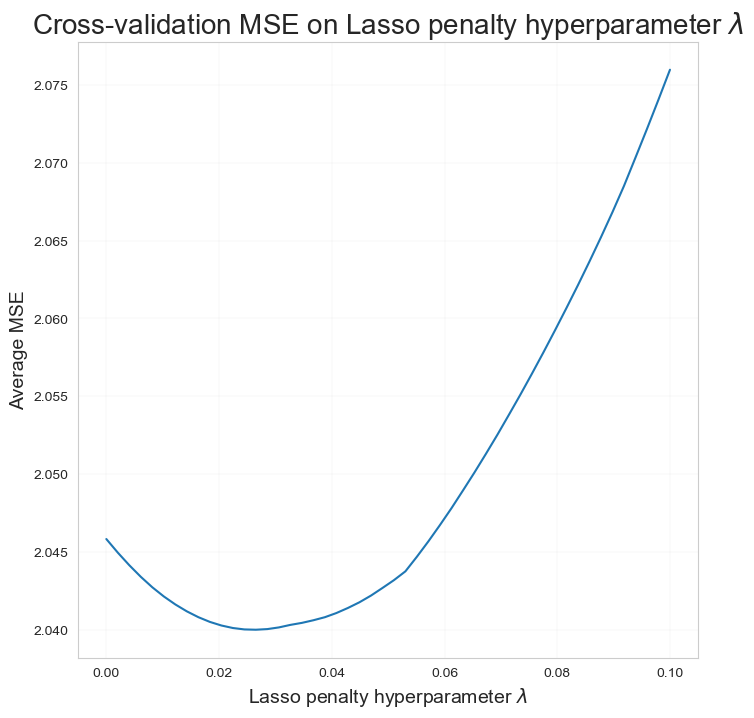

In [28]:
plt.figure(figsize=(8, 8))
font_size = 10

plt.grid(visible=True, linewidth=0.1)

plt.title(r"Cross-validation MSE on Lasso penalty hyperparameter $\lambda$", fontsize=2 * font_size)

plt.xlabel(r"Lasso penalty hyperparameter $\lambda$", fontsize=font_size + 4)
plt.ylabel("Average MSE", fontsize=font_size + 4)
plt.xticks(size=font_size)
plt.yticks(size=font_size)

plt.plot(lambda_values, scores)

plt.show()

We now train the model on `airfoil_noise_samples.csv` using the best lambda value, report the inferred values for the model parameters and print the in-sample and out-of-sample metrics.

In [29]:
# Train the model on the whole dataset using the best penalty hyperparameter.
params = optimise_lasso(
    X_train, y_train, best_lambda,
    num_iterations=1000,
)
# Retrieve parameters.
beta = params["beta"]
beta_0 = params["beta_0"]
# Store beta.
beta_best_lambda = beta.squeeze()

# Make predictions on the train/test sets.
y_train_pred = predict_linear(X_train, beta, offset=beta_0)
y_test_pred = predict_linear(X_test, beta, offset=beta_0)

# Print inferred parameters.
print("beta0:\n", beta_0.squeeze())
print("beta:\n", beta.squeeze())
# Print the in-sample and out-of-sample metrics.
metrics_best_lambda_in_sample = regression_metrics(y_train, y_train_pred)
metrics_best_lambda_out_of_sample = regression_metrics(y_test, y_test_pred)
regression_metrics_table([
    ["In-sample", metrics_best_lambda_in_sample],
    ["Out-of-sample", metrics_best_lambda_out_of_sample]
])

beta0:
 123.97028331480635
beta:
 [-3.54143622  0.01660398 -3.21161268 -0.59765995  1.68268733 -0.04841439]


,MSE,R2 Score
In-sample,2.023163,0.911260
Out-of-sample,2.216025,0.897615


##### 1.2.2

Using a specific training/validation split, we derive the inferred parameters for every value of the Lasso penalty $\lambda$.

In [30]:
lambda_values = np.linspace(0, 10, num=30)

# Choose one training/validation split.
fold = folds[0]

# Get the training data.
X_train_0, y_train_0, _, _ = get_train_val_sets(
    X_train, y_train, val_fold=folds[0]
)

# For every Lasso penalty, compute the inferred parameters.
parameters = [
    optimise_lasso(
        X_train_0, y_train_0,
        lamb=lamb,
        num_iterations=1000,
    )
    for lamb in lambda_values
]

At this point we plot the effect of the Lasso penalty on the inferred parameters $\beta$.

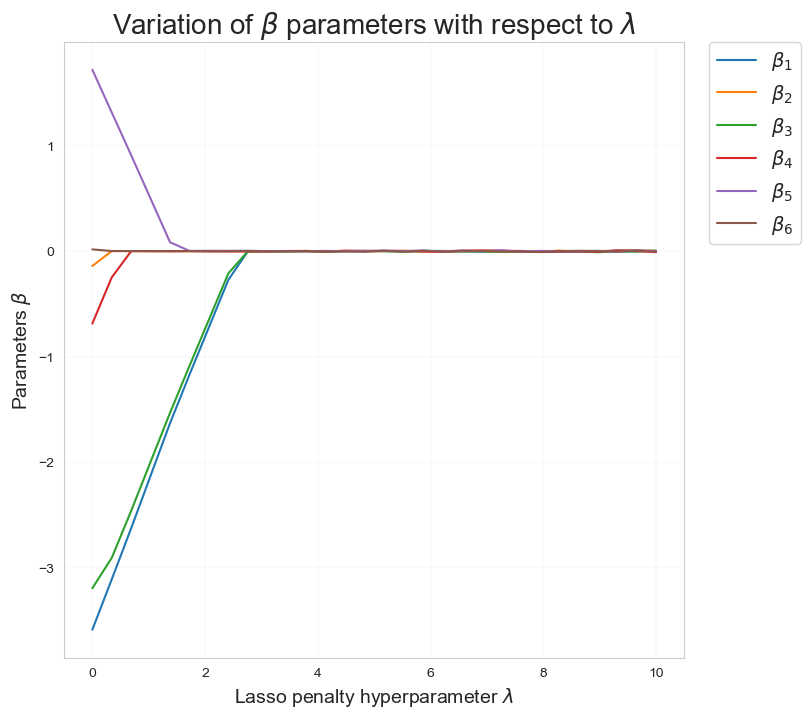

In [31]:
plt.figure(figsize=(8, 8))
font_size = 10

plt.grid(visible=True, linewidth=0.1)

plt.title(
    r"Variation of $\beta$ parameters with respect to $\lambda$",
    fontsize=2 * font_size
)

plt.xlabel(r"Lasso penalty hyperparameter $\lambda$", fontsize=font_size + 4)
plt.ylabel(r"Parameters $\beta$", fontsize=font_size + 4)
plt.xticks(size=font_size)
plt.yticks(size=font_size)

D = X_train.shape[1]  # number of features
for i in range(D):
    plt.plot(
        lambda_values,
        [params["beta"][i] for params in parameters],
        label=r"$\beta_{}$".format(str(i + 1))
    )

plt.legend(
    bbox_to_anchor=(1.04, 1),
    borderaxespad=0,
    loc="upper left",
    fontsize=font_size + 4
)

plt.show()

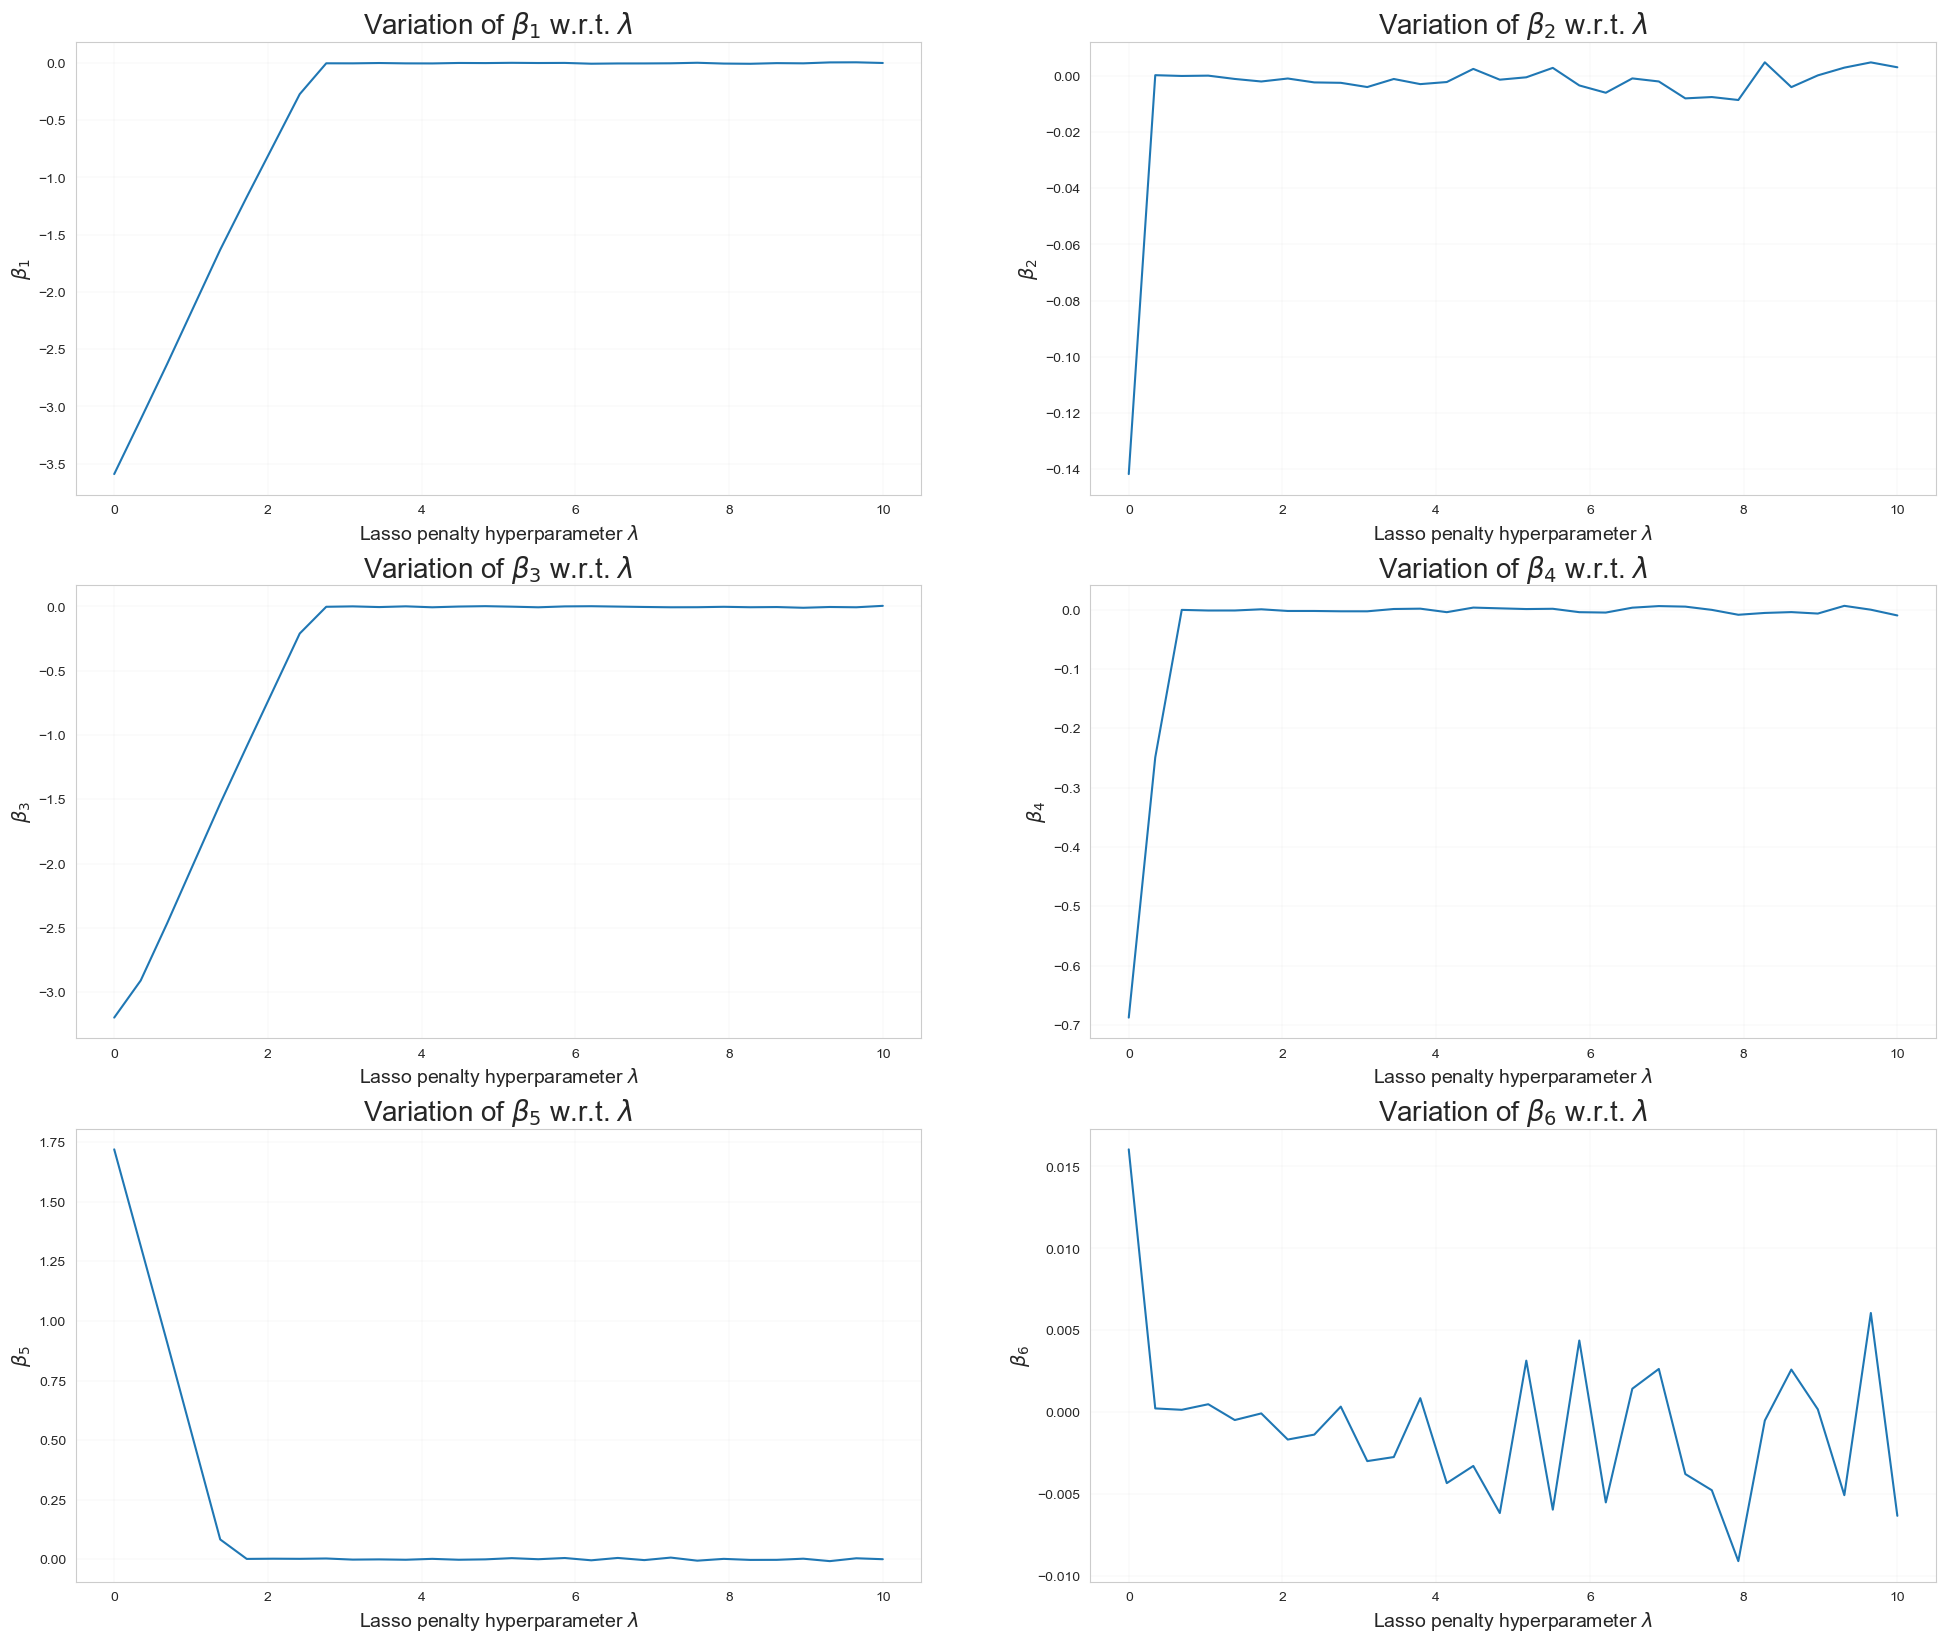

In [32]:
fig = plt.figure(figsize=(24, 20))
font_size = 10

D = X_train.shape[1]  # number of features
for i in range(D):
    ax = plt.subplot(3, 2, i + 1)

    plt.grid(visible=True, linewidth=0.1)

    plt.title(
        r"Variation of $\beta_{}$ w.r.t. $\lambda$".format(str(i + 1)),
        fontsize=2 * font_size
    )

    plt.xlabel(r"Lasso penalty hyperparameter $\lambda$", fontsize=font_size + 4)
    plt.ylabel(r"$\beta_{}$".format(str(i + 1)), fontsize=font_size + 4)
    plt.xticks(size=font_size)
    plt.yticks(size=font_size)

    plt.plot(lambda_values, [params["beta"][i] for params in parameters])

plt.show()

In Lasso regression, increasing the value of the penalty hyperparameter $\lambda$ increases the degree of regularization applied to the model (i.e., the model is more heavily penalized for having large values of the regression coefficients). This means that more and more of the coefficients are driven towards $0$. By shrinking the coefficients, the model selects the most relevant features for predicting the target variable. This can help to reduce overfitting in the model and improve its ability to generalize to new, unseen data.

By looking at the plots above, we notice that all the coefficients go to $0$, which is as expected.

We can say the following about the bias-variance tradeoff:

1. When the penalty hyperparameter is small, the model has low bias and high variance, meaning that it can fit the data well but may overfit.
2. As the penalty hyperparameter is increased, the model becomes more biased and less variable, meaning that it may miss some important features but is less likely to overfit the data.

Overall, the trend of the coefficients in Lasso regression can be seen as a way of balancing the bias-variance tradeoff. By increasing the Lasso penalty parameter, the model becomes more biased but less variable, which can help to reduce overfitting and improve the model's ability to generalize to new data.



##### 1.2.3

We fix the penalty hyperparameter $\lambda$ to the optimal value found in 1.2.1 and retrain the model on the entire dataset `airfoil_noise_samples.csv`. Then, we report the inferred parameters and in-sample/out-of-sample metrics (MSE and R2 score).

In [33]:
# Train the model on the whole dataset using the best penalty hyperparameter.
params = optimise_lasso(
    X_train, y_train, best_lambda,
    num_iterations=1000,
)
# Retrieve parameters.
beta = params["beta"]
beta_0 = params["beta_0"]
# Store beta.
beta_best_lambda = beta.squeeze()
beta0_best_lambda = beta_0.squeeze()

# Make predictions on the train/test sets.
y_train_pred = predict_linear(X_train, beta, offset=beta_0)
y_test_pred = predict_linear(X_test, beta, offset=beta_0)

# Print inferred parameters.
print("beta0:\n", beta_0.squeeze())
print("beta:\n", beta.squeeze())
# Print the in-sample and out-of-sample metrics.
metrics_best_lambda_in_sample = regression_metrics(y_train, y_train_pred)
metrics_best_lambda_out_of_sample = regression_metrics(y_test, y_test_pred)
regression_metrics_table([
    ["In-sample", metrics_best_lambda_in_sample],
    ["Out-of-sample", metrics_best_lambda_out_of_sample]
])

beta0:
 123.97028331480635
beta:
 [-3.54143622  0.01660398 -3.21161268 -0.59765995  1.68268733 -0.04841439]


,MSE,R2 Score
In-sample,2.023163,0.911260
Out-of-sample,2.216025,0.897615


We do the same for $\lambda = 0$:

In [34]:
# Train the model on the whole dataset using the best penalty hyperparameter.
params = optimise_lasso(
    X_train, y_train, 0,
    num_iterations=1000,
)
# Retrieve parameters.
beta = params["beta"]
beta_0 = params["beta_0"]
# Store beta.
beta_lambda_0 = beta.squeeze()
beta0_lambda_0 = beta_0.squeeze()

# Make predictions on the train/test sets.
y_train_pred = predict_linear(X_train, beta, offset=beta_0)
y_test_pred = predict_linear(X_test, beta, offset=beta_0)

# Print the in-sample and out-of-sample metrics.
metrics_lambda_0_in_sample = regression_metrics(y_train, y_train_pred)
metrics_lambda_0_out_of_sample = regression_metrics(y_test, y_test_pred)
regression_metrics_table([
    ["In-sample", metrics_lambda_0_in_sample],
    ["Out-of-sample", metrics_lambda_0_out_of_sample]
])

,MSE,R2 Score
In-sample,2.033990,0.910785
Out-of-sample,2.242742,0.896381


We see that we get low MSE and high R2 score on both training and test sets. Thus, using the same reasoning as for the MLE model, we may deduce that the model is performing well and has high capability of generalizing to new data.

We now look at the best lambda value, parameter values of the models and their performance:

In [35]:
# Print the best lambda value.
print("Best Lasso penalty:", best_lambda)

Best Lasso penalty: 0.02653061224489796


In [36]:
pd.DataFrame(
    [
        np.concatenate(([beta0_mle], beta_mle)),
        np.concatenate(([beta0_lambda_0], beta_lambda_0)),
        np.concatenate(([beta0_best_lambda], beta_best_lambda)),
    ],
    columns=["Beta_0", "Beta_1", "Beta_2", "Beta_3", "Beta_4", "Beta_5", "Beta_6", ],
    index=["MLE", "lambda 0", "best lambda", ],
)

,Beta_0,Beta_1,Beta_2,Beta_3,Beta_4,Beta_5,Beta_6
MLE,123.970283,-3.575497,0.834478,-3.928647,-0.078334,1.724957,-0.013563
lambda 0,123.970283,-3.580838,-0.025333,-3.201306,-0.655022,1.713859,-0.065595
best lambda,123.970283,-3.541436,0.016604,-3.211613,-0.597660,1.682687,-0.048414


In [37]:
pd.DataFrame(
    [
        [metrics_mle_in_sample["mse"], metrics_mle_in_sample["r2_score"], ],
        [metrics_lambda_0_in_sample["mse"], metrics_lambda_0_in_sample["r2_score"], ],
        [metrics_best_lambda_in_sample["mse"], metrics_best_lambda_in_sample["r2_score"], ],
    ],
    columns=["MSE", "R2 Score"],
    index=pd.Index(
        ["MLE", "lambda 0", "best lambda"],
        name="In-sample metrics"
    ),
)

,MSE,R2 Score
In-sample metrics,,
MLE,1.875557,0.917734
lambda 0,2.033990,0.910785
best lambda,2.023163,0.911260


In [38]:
pd.DataFrame(
    [
        [metrics_mle_out_of_sample["mse"], metrics_mle_out_of_sample["r2_score"], ],
        [metrics_lambda_0_out_of_sample["mse"], metrics_lambda_0_out_of_sample["r2_score"], ],
        [metrics_best_lambda_out_of_sample["mse"], metrics_best_lambda_out_of_sample["r2_score"], ],
    ],
    columns=["MSE", "R2 Score"],
    index=pd.Index(
        ["MLE", "lambda 0", "best lambda"],
        name="Out-of-sample metrics"
    ),
)

,MSE,R2 Score
Out-of-sample metrics,,
MLE,1.984390,0.908317
lambda 0,2.242742,0.896381
best lambda,2.216025,0.897615


For all models, we see that we get low MSE and high R2 score on both training and test sets. Thus, as before, we may deduce that the models are performing well and have high capability of generalizing to new data.

Note that the metrics of the Lasso model trained using the best hyperparameter $\lambda$ are not better than the ones of the MLE model, but they are pretty close.

When the value of $\lambda$ is set to $0$, the optimisation problem is equivalent to Least Squares. Therefore the parameters in the $\lambda = 0$ model will approach the maximum likelihood estimation (MLE) solution.

A best lambda value of $0.026$ suggests that the model is achieving a good balance between bias and variance, and it is not overfitting or underfitting the data. By looking at the parameters in the MLE model, we see that they are pretty small, so there is no need to impose a lot of shrinkage.

There may be no need to use the Lasso model in this case since it performs insignificantly better that the Least Squares model ($\lambda = 0$).

#### 1.3 Elastic Nets (20 marks) 


Elastic net is a machine learning algorithm that combines the Lasso and Ridge regression methods.

The loss function for the elastic nets is given by:

$$
L_{\text{elastic net}} (\beta, \beta_0) =
    \frac{1}{2N} \left\lVert y - X \beta - \beta_0 \right\rVert^2
    + \lambda \left[ \alpha \cdot \left\lVert \beta \right\rVert_{1} + (1 - \alpha) \cdot \left\lVert \beta \right\rVert_{2}^2 \right]
$$

The L1 term (Lasso term) of the loss function encourages the model to reduce the coefficients of less important features to zero. This penalty effectively performs feature selection, which can improve the model's interpretability and reduce its variance.
The L2 term (Ridge term) of the loss function encourages the model to reduce the magnitude of the coefficients, effectively shrinking them towards zero. This penalty reduces the variance of the model, possibly improving the model's generalization performance.

The gradients of the loss function with respect to the weights and bias are given by:

$$
\frac{\partial L}{\partial \beta}
    = \frac{1}{N} X^T (y_{\text{pred}} - y)
        + \lambda \cdot \alpha \cdot \operatorname{sign}(\beta)
        + \lambda \cdot (1 - \alpha) \cdot (2 \beta)
$$

$$
\frac{\partial L}{\partial \beta_0}
    = \frac{1}{N} (y_{\text{pred}} - y)
$$

where $y_{\text{pred}} = X \beta + \beta_0$.

In [39]:
def gradients_elastic_net(X, y_true, beta, beta_0, lamb, alpha):
    """
    Parameters
    ----------
    :param X: (numpy.ndarray) of shape (N, D)
        Vectors of inputs.
    :param y_true: (numpy.ndarray) of shape (N, 1)
        Vector of true values.
    :param beta: (numpy.ndarray) of shape (D, 1)
        Parameters.
    :param beta_0: (scalar)
        Offset.
    :param lamb: (scalar)
        Lasso penalty hyperparameter.
    :param alpha: (scalar) between 0 and 1 (inclusive)
        Coefficient that controls the relative importance of the Ridge and Lasso terms.

    Returns
    ----------
    :rtype: (tuple)
    :return:
        (scalar) Derivative of loss with respect to beta. (dLoss/dbeta)
        (scalar) Derivative of loss with respect to beta_0. (dLoss/dbeta_0)
    """

    # Compute derivatives of square error.
    d_mse = der_mse(y_true, X, beta, beta_0)

    # Compute gradients.
    dbeta = d_mse["dbeta"] / 2 + lamb * alpha * der_l1_norm(beta) + lamb * (
            1 - alpha) * der_l2_norm_squared(beta)  # shape (D,1)
    dbeta_0 = d_mse["dbeta_0"] / 2  # scalar

    # Store gradients in a dictionary.
    grads = {
        "dbeta": dbeta,
        "dbeta_0": dbeta_0
    }

    return grads

The `optimise_elastic_net()` function employs gradient descent to tune the weights/intercept parameters in the following way:

1. Gradients are computed using the previously defined `gradients_elastic_net()` function.
2. At iteration $k$, the weights $\beta$ and intercept $\beta_0$ are updated using the step size $\eta_{k} = \frac{1}{k}$:
    $$
    \beta = \beta - \eta_{k} \frac{\partial L}{\partial \beta}
    $$
    $$
    \beta_0 = \beta_0 - \eta_{k} \frac{\partial L}{\partial \beta_0}
    $$

In [40]:
def optimise_elastic_net(
        X, y_true,
        lamb=0,
        alpha=0.5,
        num_iterations=1000,
):
    """
    Parameters
    ----------
    :param X: (numpy.ndarray) of shape (N, D)
        Input data.
    :param y_true: (numpy.ndarray) of shape (N, 1)
        Vector of true values.
    :param lamb: (scalar), optional, default=0.
        Lasso penalty hyperparameter.
    :param alpha: (scalar) between 0 and 1 (inclusive), optional, default=0.5.
        Coefficient that controls the relative importance of the Ridge and Lasso terms.
    :param num_iterations: (int), optional, default=1000.
        Number of iterations gradient descent shall update the parameters.

    Returns
    ----------
    :rtype: (tuple)
    :return:
        (scalar) dLoss/dbeta (derivative of loss with respect to beta)
        (scalar) dLoss/dbeta_0 (derivative of loss with respect to beta_0)
    """

    D = X_train.shape[1]  # number of features

    # Initialise beta and beta_0.
    beta = np.zeros(shape=(D, 1))
    beta_0 = 0

    # Gradient Descent.
    for k in range(1, num_iterations + 1):
        # Compute cost and gradients.
        grads = gradients_elastic_net(X, y_true, beta, beta_0, lamb, alpha)

        # Retrieve derivatives from grads.
        dbeta = grads["dbeta"]
        dbeta_0 = grads["dbeta_0"]

        # Updating procedure.
        step_size = 1 / k
        beta -= step_size * dbeta
        beta_0 -= step_size * dbeta_0

    # Save parameters in a dictionary.
    params = {
        "beta": beta,
        "beta_0": beta_0
    }

    return params

The `cross_validation_elastic_net()` function employs $T$-fold cross-validation and returns the average score (in our case, MSE) of the provided hyperparameters in the following way:

1. Partition the training data into $T$ equal subsets $S_1, \ldots, S_T$ called folds.
2. Iterate through the folds. For every fold $S_i$, we
    - Keep $S_i$ as the validation set.
    - Train a model on the rest of the folds.
    - Evaluate the model's performance on the validation set and compute a score (in our case, MSE).
3. Compute the average score (in our case, average MSE) over all $T$ folds.

This average score can be seen as a measure of how well the model predicts out-of-sample (that is, on unseen data during the training).

In [41]:
def cross_validation_elastic_net(
        X_train, y_train,
        folds=None,
        lamb=0,
        alpha=0.5,
        num_iterations=1000,
):
    """
    Parameters
    ----------
    :param X_train: (numpy.ndarray) of shape (N, D)
        Train data.
    :param y_train: (numpy.ndarray) of shape (N, 1)
        Vector of true values.
    :param folds: (list), optional, default=None
        Folds used in cross-validation.
        If folds=None, 5 folds are randomly generated.
    :param lamb: (scalar), optional, default=0
        Lasso penalty hyperparameter.
    :param alpha: (scalar) between 0 and 1 (inclusive), optional, default=0.5
        Coefficient that controls the relative importance of the Ridge and Lasso terms.
    :param num_iterations: (int), optional, default=1000
        Number of iterations gradient descent shall update the parameters.

    Returns
    ----------
    :rtype: (scalar)
    :return: Average MSE.
    """

    N = X_train.shape[0]  # number of samples

    # Generate folds if they are missing.
    if folds is None:
        folds = generate_folds(N, num_folds=5)

    scores = []

    # Cross Validation.
    for i in range(len(folds)):
        # Get the training/validation data.
        X_train_i, y_train_i, X_val_i, y_val_i = get_train_val_sets(
            X_train, y_train, val_fold=folds[i])

        # Compute the parameters.
        params = optimise_elastic_net(
            X_train_i, y_train_i,
            lamb=lamb,
            alpha=alpha,
            num_iterations=num_iterations,
        )
        # Retrieve parameters.
        beta = params["beta"]
        beta_0 = params["beta_0"]

        # Compute the score.
        pred_i = predict_linear(X_val_i, beta, offset=beta_0)
        score_i = mse(y_val_i, pred_i)
        scores.append(score_i)

    # Return the average score.
    return np.mean(scores)

The `grid_search_elastic_net()` function searches for the best hyperparameters $\lambda$ and $\alpha$ from two lists which needs to be provided as parameters. It conducts $T$-fold cross-validation for each combination of hyperparameters in the two lists and produces a corresponding score. Finally, the function selects the values of $\lambda$ and $\alpha$ that results in the lowest score.

In [42]:
def grid_search_elastic_net(
        X_train, y_train,
        alpha_values,
        lambda_values,
        folds=None,
        return_scores=False,
):
    """
    Parameters
    ----------
    :param X_train: (numpy.ndarray) of shape (N, D)
        Train input data.
    :param y_train: (numpy.ndarray) of shape (N, 1)
        Train labels.
    :param alpha_values: (list)
        List of alpha values used for hyperparameter search.
    :param lambda_values: (list)
        List of lambda values used for hyperparameter search.
    :param folds: (list), optional, default=None.
        Folds used in cross-validation.
        If folds=None, 5 folds are randomly generated.
    :param return_scores: (boolean), optional, default=False.
        Boolean to indicate if the function need to return the scores or not.

    Returns
    ----------
    :rtype: (tuple)
    :return:
        (dict) Dictionary of the best combination of alpha and lambda.
        (optional) (list) List of the scores of the combinations of alpha_values and lambda_values.
    """

    N = X_train.shape[0]  # number of samples

    # Generate folds if they are missing.
    if folds is None:
        folds = generate_folds(N, num_folds=5)

    # Returns the score at a certain index.
    def score_at_index(i: int, j: int):
        score_i_j = cross_validation_elastic_net(
            X_train, y_train, folds,
            alpha=alpha_values[i],
            lamb=lambda_values[j],
            num_iterations=1000
        )
        return score_i_j

    # Find all the scores.
    scores = np.fromfunction(
        np.vectorize(score_at_index),
        (len(alpha_values), len(lambda_values)),
        dtype=int,
    )

    # Find the best hyperparameters indexes.
    best_params_indexes = np.unravel_index(
        np.argmin(scores, axis=None),
        scores.shape
    )

    # Store the best hyperparameters in a dictionary.
    hyperparams = {
        "alpha": alpha_values[best_params_indexes[0]],
        "lambda": lambda_values[best_params_indexes[1]],
    }

    if return_scores:
        return hyperparams, scores

    return hyperparams

##### 1.3.1

We now train a linear regression model using the dataset `airfoil_noise_samples.csv` and report the in-sample and out-of-sample metrics.

In [43]:
lamb = 0.5
alpha = 0.5

# Compute the parameters.
params = optimise_elastic_net(
    X_train, y_train,
    lamb=lamb,
    alpha=alpha,
    num_iterations=1000,
)
# Retrieve parameters.
beta = params["beta"]
beta_0 = params["beta_0"]

# Make predictions on the train/test sets.
y_train_pred = predict_linear(X_train, beta, offset=beta_0)
y_test_pred = predict_linear(X_test, beta, offset=beta_0)

# Print the in-sample and out-of-sample metrics.
regression_metrics_table([
    ["In-sample", regression_metrics(y_train, y_train_pred)],
    ["Out-of-sample", regression_metrics(y_test, y_test_pred)]
])

,MSE,R2 Score
In-sample,6.448034,0.717177
Out-of-sample,6.295868,0.709118


This performs much worse than our previous models, so we're going to do some hyperparameter tuning.

##### 1.3.2

The `find_best_lambda_elastic_net()` function searches for the best hyperparameter $\lambda$ in a provided list `lambda_values` using the supplied $\alpha$. To achieve this, it passes $[ \alpha ]$ and `lambda_values` to the previously defined `grid_search_elastic_net()` function.

In [44]:
def find_best_lambda_elastic_net(
        X_train, y_train,
        alpha, lambda_values,
        folds=None,
        return_scores=False,
):
    """
    Parameters
    ----------
    :param X_train: (numpy.ndarray) of shape (N, D)
        Vector of training inputs.
    :param y_train: (numpy.ndarray) of shape (N, 1)
        Vector of training targets.
    :param alpha: (scalar)
        Value of alpha.
    :param lambda_values: (list)
        List of lambda values used for hyperparameter search.
    :param folds: (list), optional, default=None.
        Folds used in cross-validation.
        If folds=None, 5 folds are randomly generated.
    :param return_scores: (boolean), optional, default=False.
        Boolean to indicate if the function need to return the scores or not.

    Returns
    ----------
    :rtype: (tuple)
    :return:
        (scalar) Best lambda value.
        (tuple)
            (numpy.ndarray) Parameters (beta).
            (scalar) Offset (beta_0).
    """

    N = X_train.shape[0]  # number of samples

    # Generate folds if they are missing.
    if folds is None:
        folds = generate_folds(N, num_folds=5)

    # Perform grid search to find the optimal penalty hyperparameter lambda.
    hyper_params, scores = grid_search_elastic_net(
        X_train, y_train,
        alpha_values=[alpha],
        lambda_values=lambda_values,
        folds=folds,
        return_scores=True,
    )
    scores = scores.squeeze()

    # Extract the best lambda.
    lamb = hyper_params["lambda"]

    # Compute the parameters.
    params = optimise_elastic_net(
        X_train, y_train,
        alpha=alpha,
        lamb=lamb,
        num_iterations=1000,
    )

    if return_scores:
        return lamb, params, scores

    return lamb, params

For $\alpha \in \{ 0.1, 0.5, 0.9 \}$, we conduct a grid search using $5$-fold cross-validation to find the best optional penalty hyper-parameter $\lambda$. Then we re-train the model with the best $\lambda$ on the full training set and report the out-of-sample MSE and R2 score evaluated on the test dataset `airfoil_noise_test.csv`.

In [45]:
rng = np.random.default_rng(60012)

# Generate folds.
N = X_train.shape[0]  # number of samples
folds = generate_folds(N, num_folds=5, random_generator=rng)

In [46]:
alpha_values = [0.1, 0.5, 0.9]

Set $\alpha = 0.1$:

In [47]:
lambda0_values = np.linspace(0, 0.1, num=100)

# Find the best lambda for the given alpha.
lambda0, params0, scores0 = find_best_lambda_elastic_net(
    X_train, y_train,
    alpha=alpha_values[0],
    lambda_values=lambda0_values,
    folds=folds,
    return_scores=True,
)
# Retrieve parameters.
beta = params0["beta"]
beta_0 = params0["beta_0"]

# Make predictions on the test set.
y_test_pred = predict_linear(X_test, beta, offset=beta_0)

# Print values of alpha and lambda.
print("alpha:", alpha_values[0])
print("best lambda:", lambda0)

# Compute the out-of-sample metrics.
metrics0 = regression_metrics(y_test, y_test_pred)

alpha: 0.1
best lambda: 0.0


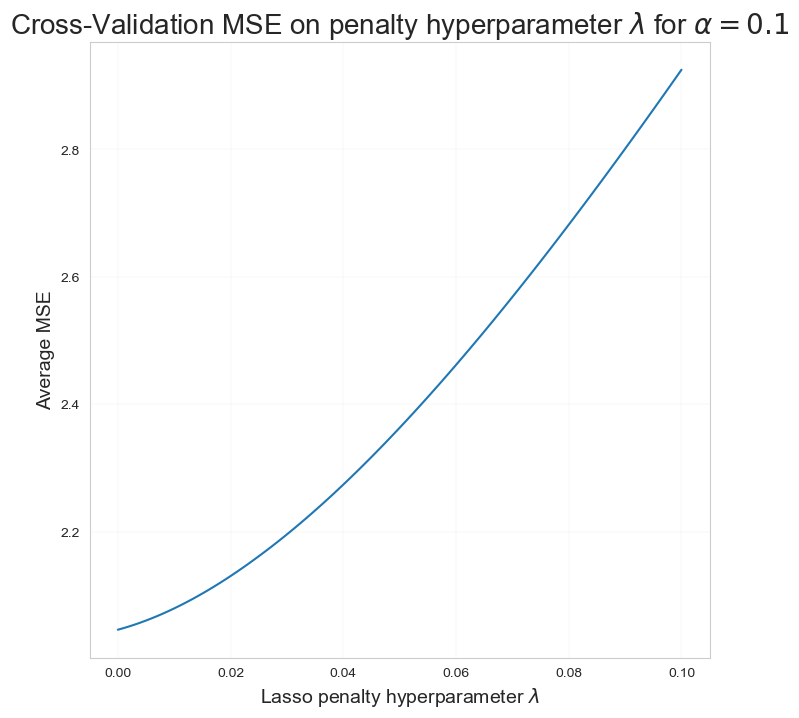

In [48]:
plt.figure(figsize=(8, 8))
font_size = 10

plt.grid(visible=True, linewidth=0.1)

plt.title(r"Cross-Validation MSE on penalty hyperparameter $\lambda$ for $\alpha = 0.1$", fontsize=2 * font_size)

plt.xlabel(r"Lasso penalty hyperparameter $\lambda$", fontsize=font_size + 4)
plt.ylabel("Average MSE", fontsize=font_size + 4)
plt.xticks(size=font_size)
plt.yticks(size=font_size)

plt.plot(lambda0_values, scores0)

plt.show()

Set $\alpha = 0.5$:

In [49]:
lambda1_values = np.linspace(0, 0.1, num=100)

# Find the best lambda for the given alpha.
lambda1, params1, scores1 = find_best_lambda_elastic_net(
    X_train, y_train,
    alpha=alpha_values[1],
    lambda_values=lambda1_values,
    folds=folds,
    return_scores=True,
)
# Retrieve parameters.
beta = params1["beta"]
beta_0 = params1["beta_0"]

# Make predictions on the test set.
y_test_pred = predict_linear(X_test, beta, offset=beta_0)

# Print values of alpha and lambda.
print("alpha:", alpha_values[1])
print("best lambda:", lambda1)

# Compute the out-of-sample metrics.
metrics1 = regression_metrics(y_test, y_test_pred)

alpha: 0.5
best lambda: 0.0


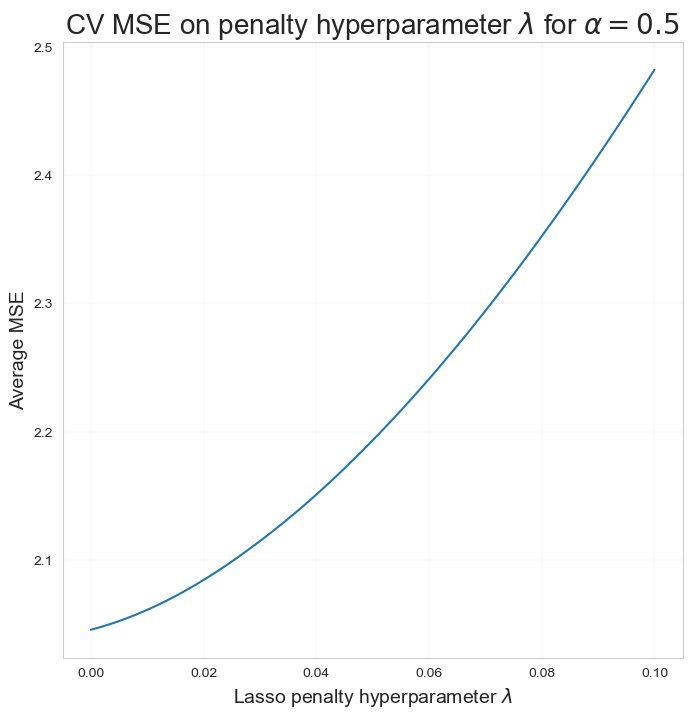

In [50]:
plt.figure(figsize=(8, 8))
font_size = 10

plt.grid(visible=True, linewidth=0.1)

plt.title(r"CV MSE on penalty hyperparameter $\lambda$ for $\alpha = 0.5$", fontsize=2 * font_size)

plt.xlabel(r"Lasso penalty hyperparameter $\lambda$", fontsize=font_size + 4)
plt.ylabel("Average MSE", fontsize=font_size + 4)
plt.xticks(size=font_size)
plt.yticks(size=font_size)

plt.plot(lambda1_values, scores1)

plt.show()

Set $\alpha = 0.9$:

In [51]:
lambda2_values = np.linspace(0, 0.01, num=100)

# Find the best lambda for the given alpha.
lambda2, params2, scores2 = find_best_lambda_elastic_net(
    X_train, y_train,
    alpha=alpha_values[2],
    lambda_values=lambda2_values,
    folds=folds,
    return_scores=True,
)
# Retrieve parameters.
beta = params2["beta"]
beta_0 = params2["beta_0"]

# Make predictions on the test set.
y_test_pred = predict_linear(X_test, beta, offset=beta_0)

# Print values of alpha and lambda.
print("alpha:", alpha_values[2])
print("best lambda:", lambda2)

# Compute the out-of-sample metrics.
metrics2 = regression_metrics(y_test, y_test_pred)

alpha: 0.9
best lambda: 0.005454545454545455


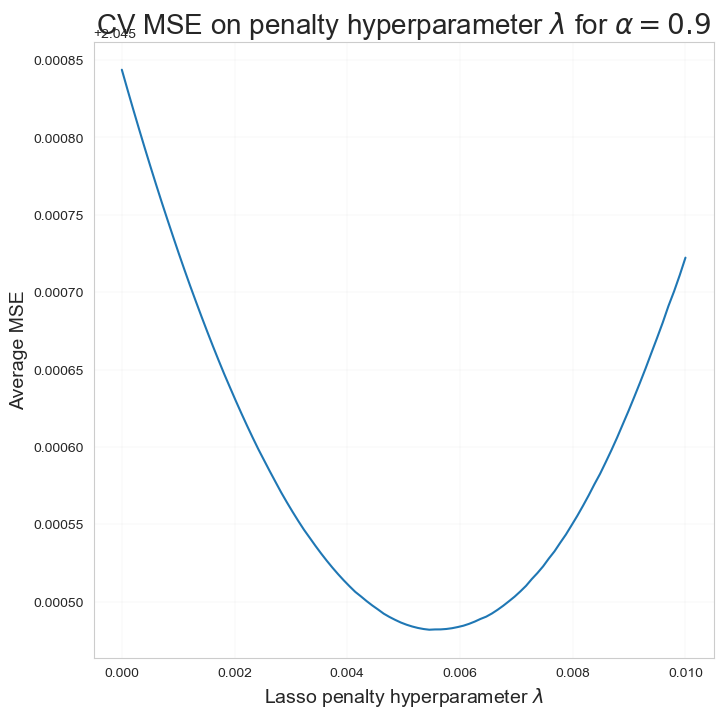

In [52]:
plt.figure(figsize=(8, 8))
font_size = 10

plt.grid(visible=True, linewidth=0.1)

plt.title(r"CV MSE on penalty hyperparameter $\lambda$ for $\alpha = 0.9$", fontsize=2 * font_size)

plt.xlabel(r"Lasso penalty hyperparameter $\lambda$", fontsize=font_size + 4)
plt.ylabel("Average MSE", fontsize=font_size + 4)
plt.xticks(size=font_size)
plt.yticks(size=font_size)

plt.plot(lambda2_values, scores2)

plt.show()

In [53]:
pd.DataFrame(
    [lambda0, lambda1, lambda2, ],
    columns=["Best lambda value"],
    index=["alpha = 0.1", "alpha = 0.5", "alpha = 0.9", ],
)

,Best lambda value
alpha = 0.1,0.000000
alpha = 0.5,0.000000
alpha = 0.9,0.005455


In [54]:
regression_metrics_table([
    ["Out-of-sample metrics for alpha = 0.1", metrics0],
    ["Out-of-sample metrics for alpha = 0.5", metrics1],
    ["Out-of-sample metrics for alpha = 0.9", metrics2],
])

,MSE,R2 Score
Out-of-sample metrics for alpha = 0.1,2.242742,0.896381
Out-of-sample metrics for alpha = 0.5,2.242742,0.896381
Out-of-sample metrics for alpha = 0.9,2.238571,0.896574


Looking at the above metrics, we infer that the best value of $\alpha$ is $0.9$ (although by a **very small** margin).

For $\alpha = 0.1$, there is almost no L1 regularization (Lasso regularization) used, with L2 regularization (Ridge regularization) being the primary one. Since the best $\lambda$ in this case is $0$, this means that Ridge regularization is not needed in the model. From this we may infer that the data has a sparse structure.
For $\alpha = 0.5$, the L1 regularization and L2 regularization have equal weights. We also get an optimal $0$ value of $\lambda$ in this case which suggests that both regularization are not needed in the model. Once again, this implies that the data exhibits a sparse structure (since Lasso regularization is not needed). However, in this case, we also observe that all features are significant, as indicated by the fact that Ridge regularization is unnecessary.
For $\alpha = 0.9$, there is almost no L2 regularization (Ridge regularization) used, with L1 regularization (Lasso regularization) being the primary one. In this case, the optimal $\alpha$ is approximately $0.005$. Although it is positive, it is very small, implying that Lasso regularization is not needed in the model. Once again, this suggests that all features are significant.

##### 1.3.3

In [55]:
# The number of alphas needs to be odd in order to have 0.5 in the list.
alpha_values = np.linspace(0, 1, num=2 * 5 + 1)
lambda_values = np.linspace(-0.5, 0.5, num=10)

params_values = []
best_lambda_values = []
for alpha in alpha_values:
    # Get the best parameters for this alpha.
    best_lambda, best_params = find_best_lambda_elastic_net(
        X_train, y_train,
        alpha=alpha,
        lambda_values=lambda_values,
        folds=folds,
    )
    # Extract the beta parameters.
    best_beta = best_params["beta"]
    best_beta = np.squeeze(best_beta)
    # Append the beta's to the list.
    params_values.append(best_beta)
    # Append the best lambda to the list.
    best_lambda_values.append(best_lambda)

params_values = np.array(params_values)

Plot the inferred parameters for every value of $\alpha$:

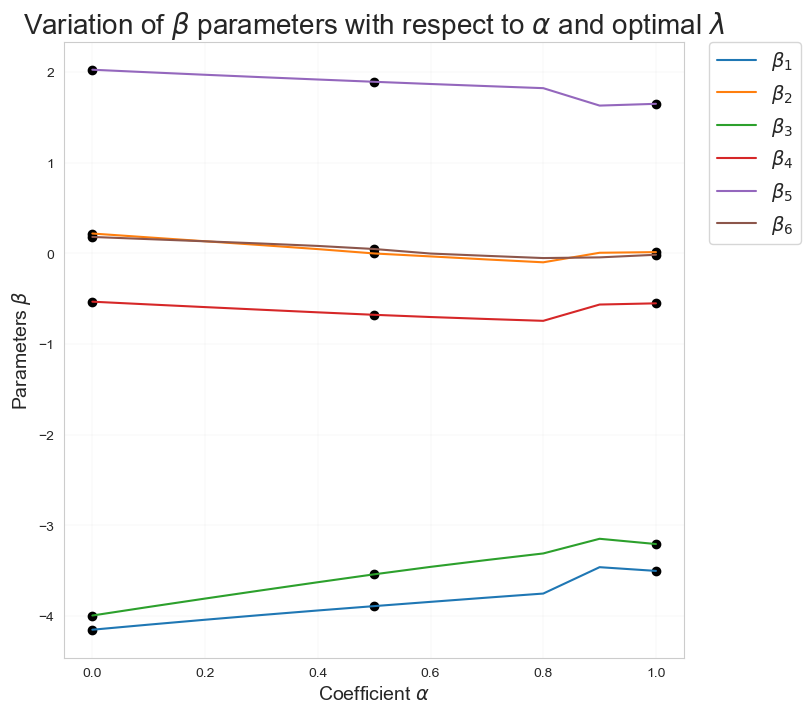

In [56]:
plt.figure(figsize=(8, 8))
font_size = 10

plt.grid(visible=True, linewidth=0.1)

plt.title(
    r"Variation of $\beta$ parameters with respect to $\alpha$ and optimal $\lambda$",
    fontsize=2 * font_size
)

plt.xlabel(r"Coefficient $\alpha$", fontsize=font_size + 4)
plt.ylabel(r"Parameters $\beta$", fontsize=font_size + 4)

plt.xticks(size=font_size)
plt.yticks(size=font_size)

D = X_train.shape[1]  # number of features
no_alphas = len(alpha_values)  # number of alpha values
for i in range(D):
    plt.plot(
        alpha_values,
        params_values[:, i],
        label=r"$\beta_{}$".format(str(i + 1))
    )
    plt.scatter([alpha_values[0]], [params_values[0, i]], color="black")
    plt.scatter([alpha_values[no_alphas // 2]], [params_values[no_alphas // 2, i]], color="black")
    plt.scatter([alpha_values[no_alphas - 1]], [params_values[no_alphas - 1, i]], color="black")

plt.legend(
    bbox_to_anchor=(1.04, 1),
    borderaxespad=0,
    loc="upper left",
    fontsize=font_size + 4
)

plt.show()

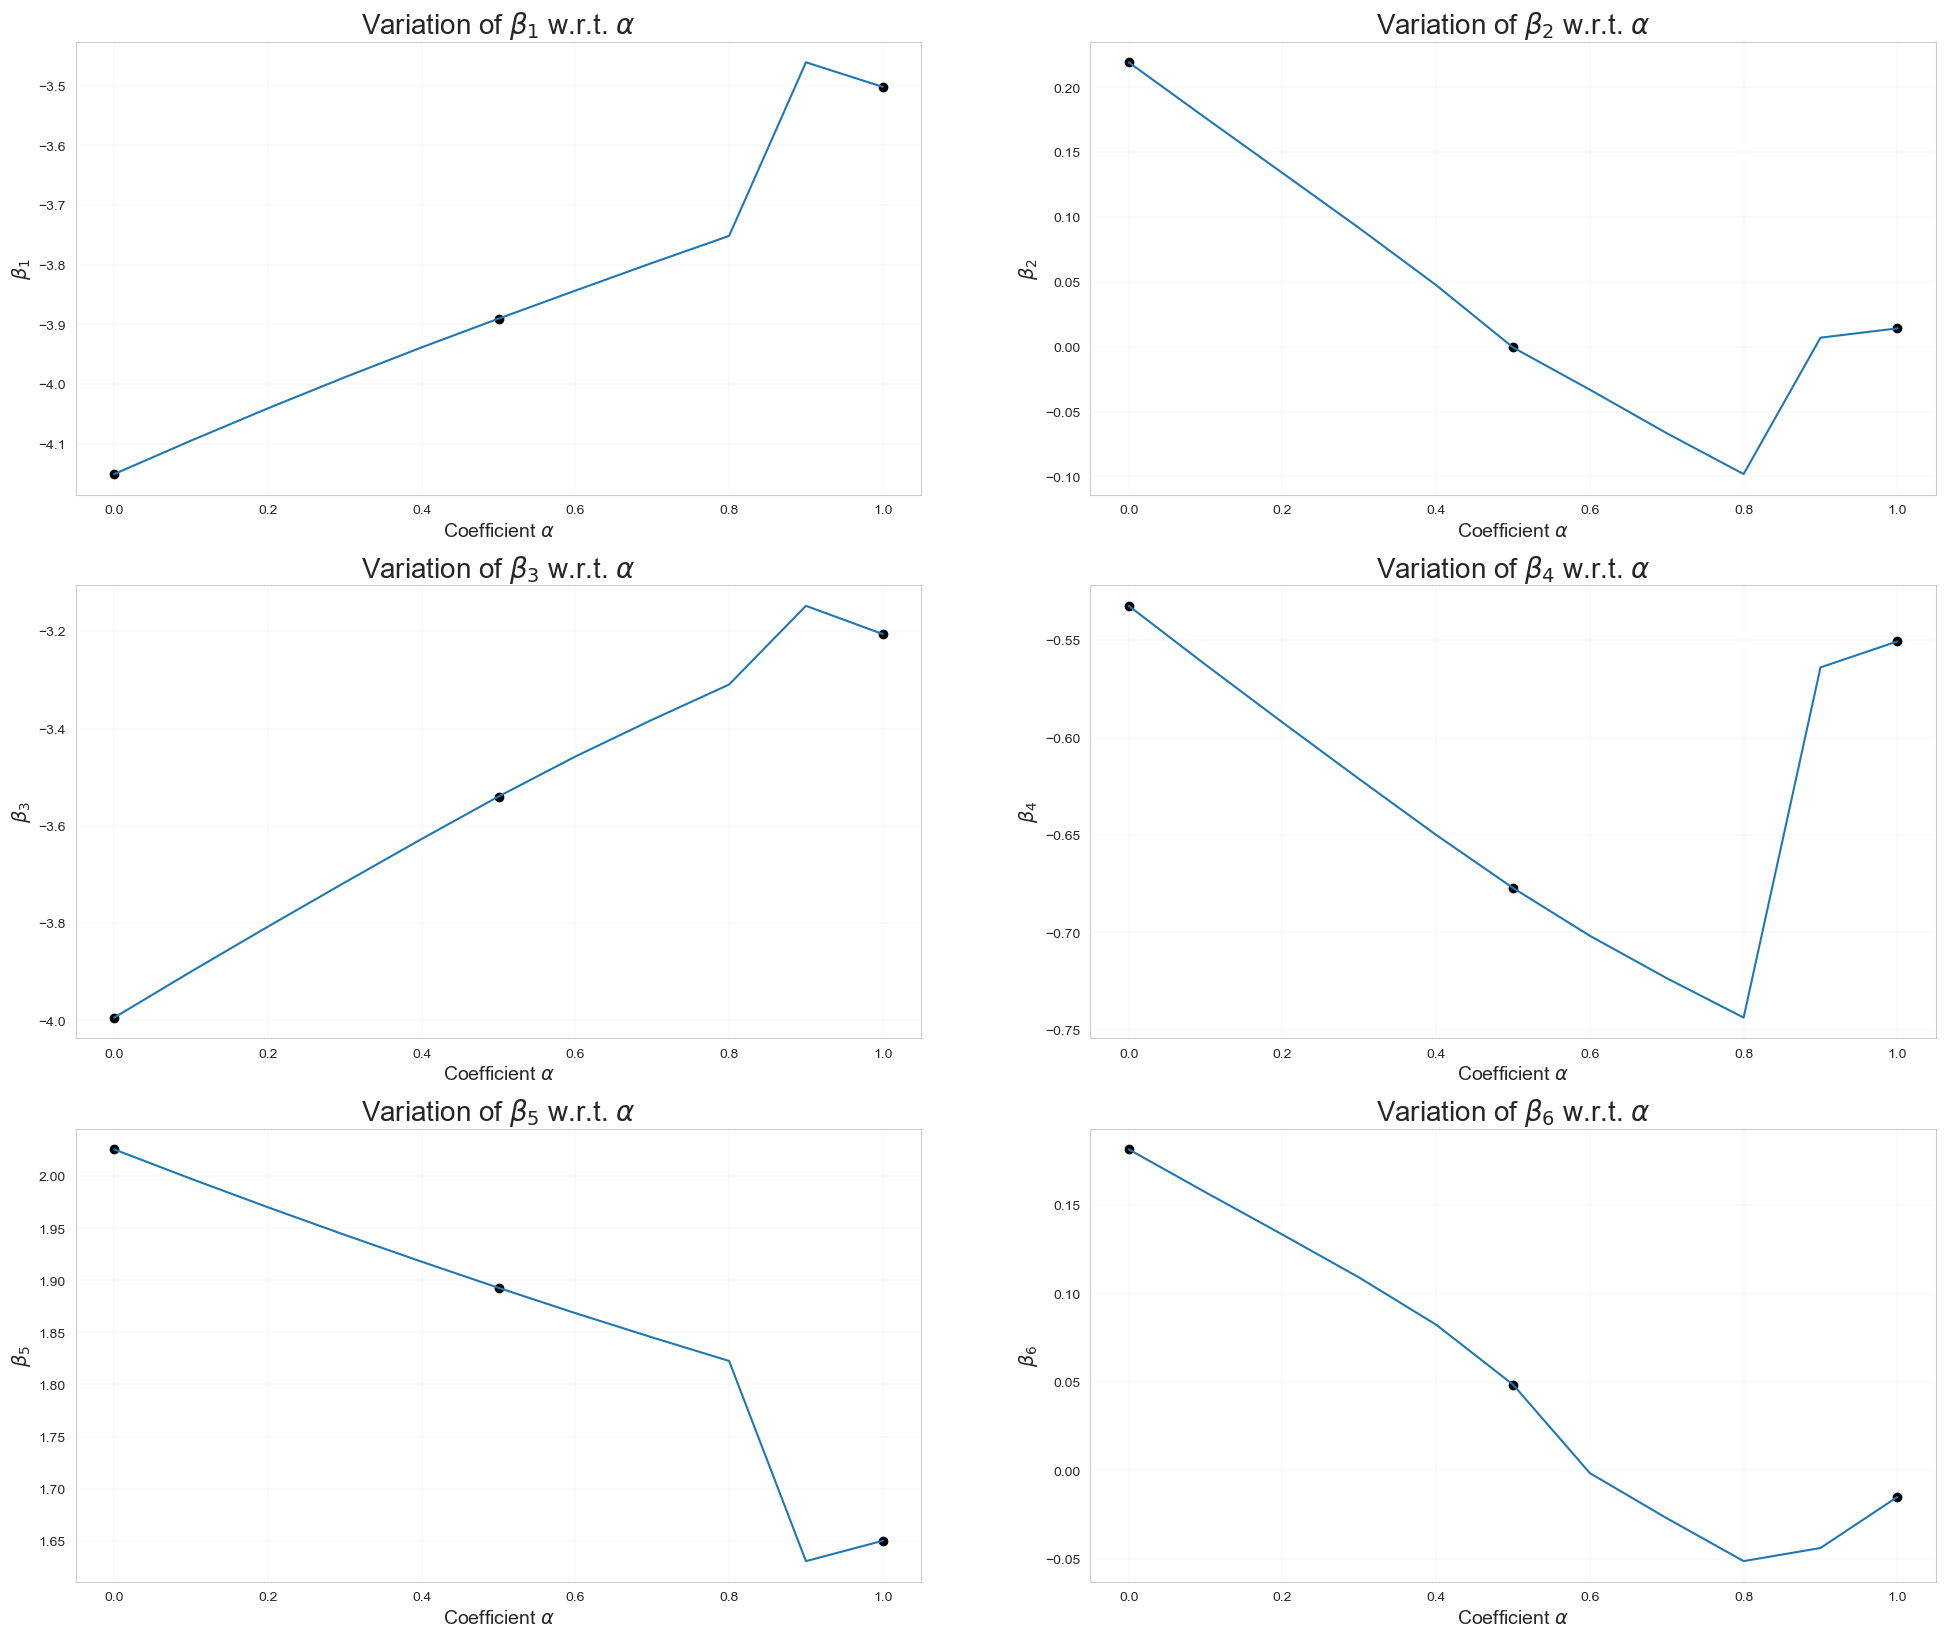

In [57]:
fig = plt.figure(figsize=(24, 20))
font_size = 10

D = X_train.shape[1]  # number of features
no_alphas = len(alpha_values)  # number of alpha values
for i in range(D):
    ax = plt.subplot(3, 2, i + 1)

    plt.grid(visible=True, linewidth=0.1)

    plt.title(
        r"Variation of $\beta_{}$ w.r.t. $\alpha$".format(str(i + 1)),
        fontsize=2 * font_size
    )

    plt.xlabel(r"Coefficient $\alpha$", fontsize=font_size + 4)
    plt.ylabel(r"$\beta_{}$".format(str(i + 1)), fontsize=font_size + 4)
    plt.xticks(size=font_size)
    plt.yticks(size=font_size)

    plt.plot(
        alpha_values,
        params_values[:, i],
        label=r"$\beta_{}$".format(str(i + 1)),
    )
    plt.scatter([alpha_values[0]], [params_values[0, i]], color="black")
    plt.scatter([alpha_values[no_alphas // 2]], [params_values[no_alphas // 2, i]], color="black")
    plt.scatter([alpha_values[no_alphas - 1]], [params_values[no_alphas - 1, i]], color="black")

plt.show()

Plot the best $\lambda$ for every value of $\alpha$:

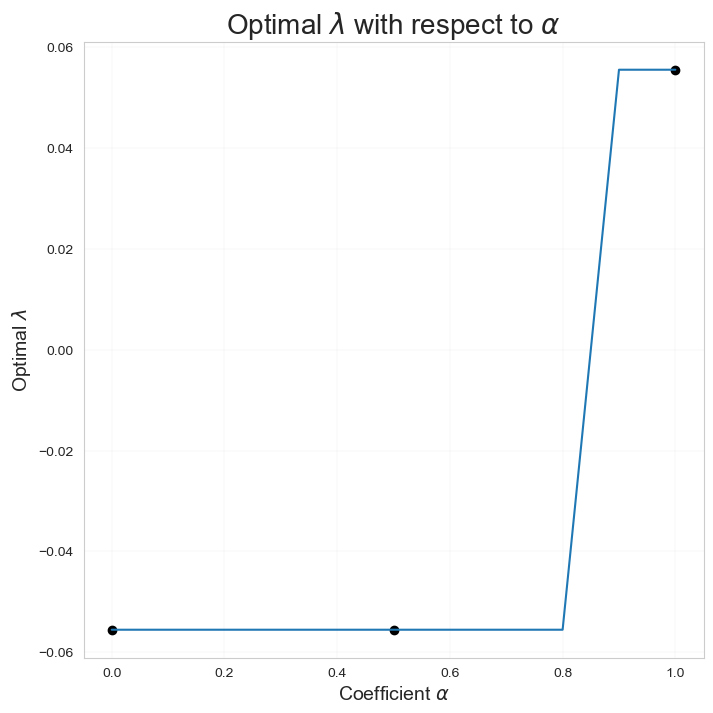

In [58]:
plt.figure(figsize=(8, 8))
font_size = 10

plt.grid(visible=True, linewidth=0.1)

plt.title(
    r"Optimal $\lambda$ with respect to $\alpha$",
    fontsize=2 * font_size
)

plt.xlabel(r"Coefficient $\alpha$", fontsize=font_size + 4)
plt.ylabel(r"Optimal $\lambda$", fontsize=font_size + 4)

plt.xticks(size=font_size)
plt.yticks(size=font_size)

D = X_train.shape[1]  # number of features
no_alphas = len(alpha_values)  # number of alpha values

plt.plot(alpha_values, best_lambda_values, )
plt.scatter([alpha_values[0]], [best_lambda_values[0]], color="black")
plt.scatter([alpha_values[no_alphas // 2]], [best_lambda_values[no_alphas // 2]], color="black")
plt.scatter([alpha_values[no_alphas - 1]], [best_lambda_values[no_alphas - 1]], color="black")

plt.show()

We notice that the parameters are not changing almost at all. By looking the optimal $\lambda$ values, we can see why: all of them are $0$ or very close to $0$. This means that almost no regularisation takes place, which implies that the parameters will be very close to the least squares ones.

Moreover, since the optimal $\lambda$ values are close to $0$, as before, we may deduce that there is no need for Lasso and Ridge regularisation in the model. Hence the data exhibits a sparse structure and all features are significant.

#### 1.4 kNN regression (10 marks)

K-Nearest Neighbors is a machine learning algorithm used for both classification and regression tasks. The algorithm predicts the label of a new data point based on the labels of its closest neighboring points in the training set.

The KNN algorithm works by first selecting a value for K, which represents the number of closest neighboring points to consider. Then, for a new data point, the algorithm identifies the K closest neighbors based on some distance metric (e.g., Euclidean distance) and their labels.
- In the **discrete** case, the algorithm usually assigns the most common label among the K neighbors as the predicted label for the new data point (other assignments also exist).
- In the **continuous** case, the algorithm usually assigns the mean of the K labels (other assignments also exist). This is what we're going to use.

KNN can be computationally expensive for large datasets, and the optimal value of K may need to be tuned.

The `euclidean_distance()` function returns the Euclidean distance between $2$ points.

In [59]:
def euclidian_distance(point1, point2):
    """
    Parameters
    ----------
    :param point1: (numpy.ndarray) of shape (D, )
        First point.
    :param point2: (numpy.ndarray) of shape (D, )
        Second point.

    Returns
    ----------
    :rtype: (scalar)
    :return:
        The distance between the 2 points.
    """

    return np.sqrt(np.sum((point2 - point1) ** 2, axis=1))

The `k_neighbours()` function returns the $k$ nearest neighbours in our training set for every point in our test dataset.

In [60]:
def k_neighbours(X_train, X_test, k=5):
    """
    Parameters
    ----------
    :param X_train: (numpy.ndarray) of shape (N_train, D)
        Vectors of training instances.
    :param X_test: (numpy.ndarray) of shape (N_test, D)
        Vectors of test instances.
    k: (scalar), optional, default=5
        Number of neighbours.

    Returns
    ----------
    :rtype: (numpy.ndarray) of shape (N_test, k)
    :return: The closest k neighbours to every point in X_test.
    """

    dist = []
    neigh_ind = []

    # Compute distance from each point x_text in X_test to all points in X_train
    point_dist = np.apply_along_axis(
        lambda x_test: euclidian_distance(x_test, X_train),
        axis=1,
        arr=X_test
    )

    # Determine which k training points are closest to each test point.
    for row in point_dist:
        enum_neigh = enumerate(row)
        sorted_neigh = sorted(enum_neigh, key=lambda x: x[1])[:k]

        ind_list = [tup[0] for tup in sorted_neigh]
        dist_list = [tup[1] for tup in sorted_neigh]

        dist.append(dist_list)
        neigh_ind.append(ind_list)

    return np.array(neigh_ind)

The `predict_knn()` function makes prediction in the following way:

1. It finds the `k` neighbours which are closest to our test points by using `k_neighbours()`.
2. Computes the average of the values of the `k` nearest neighbours and returns it.

In [61]:
def predict_knn(X_train, y_train, X_test, k=5):
    """
    Parameters
    ----------
    :param X_train: (numpy.ndarray) of shape (N_train, D)
        Train data.
    :param y_train: (numpy.ndarray) of shape (N, 1)
        Vector of training targets.
    :param X_test: (numpy.ndarray) of shape (N_test, D)
        Test data.
    :param k: (scalar), optional, default=5.
        Number of neighbours.

    Returns
    ----------
    :rtype: (numpy.ndarray) of shape (N_test, )
    :return: Predictions using k nearest neighbours.
    """

    # Each of the k neighbours contributes equally to the classification of any data point in X_test.
    neighbours = k_neighbours(X_train, X_test, k=k)

    # For every point, compute the average over the k nearest neighbours.
    y_pred = np.apply_along_axis(
        lambda neighbour: np.mean(y_train[neighbour]),
        axis=1,
        arr=neighbours
    )

    return y_pred.reshape(-1, 1)

The `cross_validation_knn()` function employs $T$-fold cross-validation and returns the average score (in our case, MSE) of the provided hyperparameter $k$ in the following way:

1. Partition the training data into $T$ equal subsets $S_1, \ldots, S_T$ called folds.
2. Iterate through the folds. For every fold $S_i$, we
    - Keep $S_i$ as the validation set.
    - Train a model on the rest of the folds.
    - Evaluate the model's performance on the validation set and compute a score (in our case, MSE).
3. Compute the average score (in our case, average MSE) over all $T$ folds.

This average score can be seen as a measure of how well the model predicts out-of-sample (that is, on unseen data during the training).

In [62]:
def cross_validation_knn(
        X_train, y_train,
        k=5,
        folds=None,
):
    """
    Parameters
    ----------
    :param X_train: (numpy.ndarray) of shape (N_train, D).
        Vector of training inputs.
    :param y_train: (numpy.ndarray) of shape (N_train, 1).
        Vector of training targets.
    :param k: (scalar), optional, default=5.
        Number of neighbours.
    :param folds: (list), optional, default=None.
        Folds used in cross-validation.
        If folds=None, 5 folds are randomly generated.

    Returns
    ----------
    :rtype: (scalar)
    :return: Average score.
    """

    N = X_train.shape[0]  # number of samples

    # Generate folds if they are missing.
    if folds is None:
        folds = generate_folds(N, num_folds=5)

    scores = []

    # Cross-Validation.
    for i in range(len(folds)):
        # Get the training/validation data.
        X_train_i, y_train_i, X_val_i, y_val_i = get_train_val_sets(X_train, y_train, folds[i])

        # Make predictions.
        y_val_i_pred = predict_knn(X_train_i, y_train_i, X_val_i, k=k)
        # Compute score.
        score_i = mse(y_val_i, y_val_i_pred)
        scores.append(score_i)

    # Return the average score.
    return np.mean(scores)

The `grid_search_knn()` function searches for the best hyperparameter $k$ from a list which needs to be provided as a parameter. It conducts $T$-fold cross-validation for each hyperparameter in the list and produces a corresponding score. Finally, the function selects the value of $k$ that results in the lowest score.

In [63]:
def grid_search_knn(
        X_train, y_train,
        k_values,
        folds=None,
        return_scores=False,
):
    """
    Parameters
    ----------
    :param X_train: (numpy.ndarray) of shape (N_train, D).
        Train data.
    :param y_train: (numpy.ndarray) of shape (N, 1).
        Vector of true values.
    :param k_values: (list).
        List of  k-values (number of neighbours).
    :param folds: (list), optional, default=None.
        Folds used in cross-validation.
        If folds=None, 5 folds are randomly generated.

    Returns
    ----------
    :rtype: (tuple)
        (scalar) Best k.
        (list) (optional) List of average MSE's for all k values.
    """

    N = X_train.shape[0]  # number of samples

    # Generate folds if they are missing.
    if folds is None:
        folds = generate_folds(N)

    # Returns the score at a given index.
    def score_at_index(i: int):
        score_i = cross_validation_knn(
            X_train, y_train,
            k=k_values[i],
            folds=folds
        )
        return score_i

    # Find all the scores.
    k_scores = np.fromfunction(
        np.vectorize(score_at_index),
        (len(k_values),),
        dtype=int,
    )

    # Get the best k.
    best_k_index = np.argmin(k_scores)
    best_k = k_values[best_k_index]

    if return_scores:
        return best_k, k_scores

    return best_k

##### 1.4.1

We train a kNN regression model on the dataset `airfoil_noise_samples.csv`.

In [64]:
# Make predictions on the train/test sets.
y_train_pred = predict_knn(X_train, y_train, X_train, k=2)
y_test_pred = predict_knn(X_train, y_train, X_test, k=2)

# Print the in-sample and out-of-sample metrics.
regression_metrics_table([
    ["In-sample", regression_metrics(y_train, y_train_pred)],
    ["Out-of-sample", regression_metrics(y_test, y_test_pred)],
])

,MSE,R2 Score
In-sample,1.288886,0.943467
Out-of-sample,3.790674,0.824863


We notice that the model is overfitting. That is because:

1. The in-sample MSE is low and the R2 score is high.
2. On the other hand, the out-of-sample MSE is high and the R2 score is low.

Therefore, it may be indicated to use grid search to find an optimal value of the hyperparameter `k`. We're going to do so using 5-fold cross-validation.

In [65]:
rng = np.random.default_rng(60012)

k_values = np.arange(1, 21)

# Generate folds.
N = X_train.shape[0]  # number of samples
folds = generate_folds(N, num_folds=5, random_generator=rng)

# Employ a 5-fold cross-validation to tune the k (number of neighbours) hyperparameter.
best_k, k_scores = grid_search_knn(
    X_train, y_train,
    k_values=k_values,
    folds=folds,
    return_scores=True,
)

# Print the scores of the k values.
for k, k_score in zip(k_values, k_scores):
    print("CV_AVG-MSE@k=", k, ": ", k_score, sep="")

CV_AVG-MSE@k=1: 5.198631374033786
CV_AVG-MSE@k=2: 3.8799503268369784
CV_AVG-MSE@k=3: 3.4230489341589254
CV_AVG-MSE@k=4: 3.1794509958798356
CV_AVG-MSE@k=5: 3.072970956504183
CV_AVG-MSE@k=6: 2.997796843490619
CV_AVG-MSE@k=7: 2.988656333387393
CV_AVG-MSE@k=8: 2.98228397641707
CV_AVG-MSE@k=9: 2.960341322934954
CV_AVG-MSE@k=10: 2.9566168883576656
CV_AVG-MSE@k=11: 2.964893234952
CV_AVG-MSE@k=12: 2.988629029679386
CV_AVG-MSE@k=13: 2.9884364464682562
CV_AVG-MSE@k=14: 3.006811703147538
CV_AVG-MSE@k=15: 3.015010050943006
CV_AVG-MSE@k=16: 3.0173680508916867
CV_AVG-MSE@k=17: 3.0408157572887555
CV_AVG-MSE@k=18: 3.0762071197227385
CV_AVG-MSE@k=19: 3.090600267600567
CV_AVG-MSE@k=20: 3.1118122542419653


In [66]:
# Print the optimal k value.
print("Best k value:", best_k)

Best k value: 10


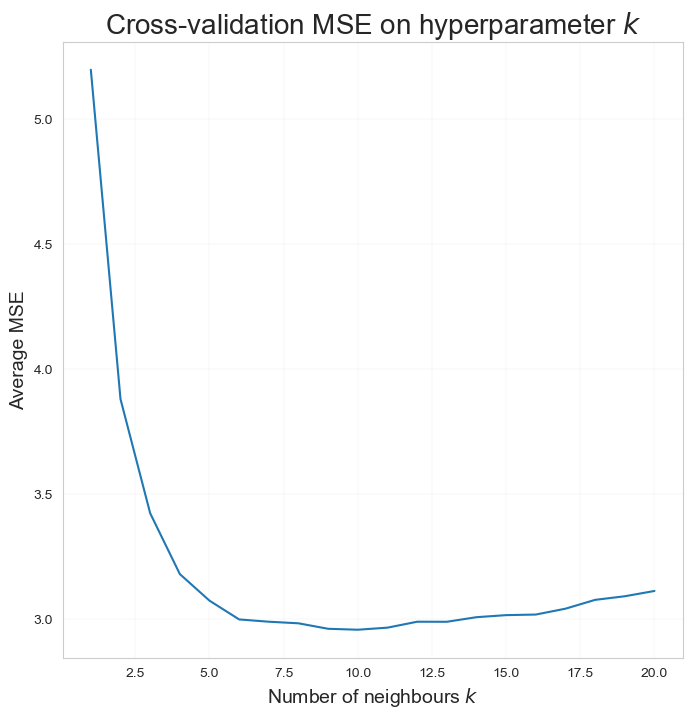

In [67]:
plt.figure(figsize=(8, 8))
font_size = 10

plt.grid(visible=True, linewidth=0.1)

plt.title(r"Cross-validation MSE on hyperparameter $k$", fontsize=2 * font_size)

plt.xlabel(r"Number of neighbours $k$", fontsize=font_size + 4)
plt.ylabel("Average MSE", fontsize=font_size + 4)
plt.xticks(size=font_size)
plt.yticks(size=font_size)

plt.plot(k_values, k_scores)

plt.show()

##### 1.4.2

Using the optimal `k`, we train a model on the dataset `airfoil_noise_samples.csv` and report the in-sample and out-of-sample metrics.

In [68]:
optimal_k = best_k

# Make predictions on the train/test sets.
y_train_pred = predict_knn(X_train, y_train, X_train, k=optimal_k)
y_test_pred = predict_knn(X_train, y_train, X_test, k=optimal_k)

# Print the in-sample and out-of-sample metrics.
regression_metrics_table([
    ["In-sample", regression_metrics(y_train, y_train_pred)],
    ["Out-of-sample", regression_metrics(y_test, y_test_pred)],
])

,MSE,R2 Score
In-sample,2.357387,0.896600
Out-of-sample,2.985675,0.862056


By looking at the metrics, as before, we may deduce that the model is performing well and has high capability of generalizing to new data.

But we notice that kNN performs slightly worse in-sample and out-of-sample than our previous regression models (we have slightly higher MSE and slightly lower R2 score). This suggests the following:

1. There is a linear relationship between the predictors and outcomes. This is supported by the high performance of our linear models.
2. The nearest data points to a new sample may not necessarily provide the most accurate prediction for the outcome. This may be a consequence of poor choice of the distance metric or quality of the data. Moreover, the performance of kNN tends to degrade as the number of features increases. By looking at the dataset, we see that it is a small one, which means that keeping all $6$ features may be too much for the kNN model. We may ammend this by using dimensionality reduction techniques or feature selection methods in order to improve the performance.

## Task 2: Classification  (50 marks)

Load the dataset and preview it.

In [69]:
# Load the datasets.
diabetes_sample = pd.read_csv('diabetes_samples.csv', thousands=".", decimal=",")
diabetes_test = pd.read_csv('diabetes_test.csv', thousands=".", decimal=",")

# Visualise the first 5 rows.
diabetes_sample.head(5)

,patient_number,cholesterol,glucose,hdl_chol,chol_hdl_ratio,age,height,weight,bmi,systolic_bp,diastolic_bp,waist,hip,waist_hip_ratio,diabetes
0,115,224,85,30,7.5,36,69,205,30.3,150,99,37,41,0.90,No diabetes
1,318,194,95,36,5.4,63,58,210,43.9,140,100,44,53,0.83,No diabetes
2,73,207,75,44,4.7,30,72,180,24.4,118,62,35,41,0.85,No diabetes
3,69,144,81,28,5.1,30,72,165,22.4,118,78,31,38,0.82,No diabetes
4,326,181,177,24,7.5,64,71,225,31.4,130,66,44,47,0.94,Diabetes


We're going to:

1. Drop the `patient_number` column since it is clearly irrelevant in deciding whether a patient has diabetes or not. Alternatively, we could set it to the index column.
2. Convert the `diabetes` column from string to boolean in order to make the data processing much easier.
3. Extract the predictors and true labels and then standardise the data.

In [70]:
# Map to convert output from string to boolean.
labels_map = {"Diabetes": True, "No diabetes": False}

In [71]:
# Extract the predictors and true labels.
X_train = diabetes_sample.drop(columns=["diabetes", "patient_number"])  # size (N_train, D)
y_train = diabetes_sample["diabetes"].replace(labels_map)  # size (N_train, )

# Extract the mean and std of the train inputs.
X_train_mean = np.mean(X_train, axis=0)  # shape (D, 1)
X_train_std = np.std(X_train, axis=0)  # shape (D, 1)

# Standardise the training inputs.
X_train = standardise(X_train, X_train_mean, X_train_std)

# Print the shapes of the arrays.
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (273, 13)
y_train shape: (273,)


In [72]:
# Extract the predictors and true labels.
X_test = diabetes_test.drop(columns=["diabetes", "patient_number"])  # size (N_test, D)
y_test = diabetes_test["diabetes"].replace(labels_map)  # size (N_test, )

# Standardise the test inputs using the train set's mean and std.
X_test = standardise(X_test, X_train_mean, X_train_std)

# Print the shapes of the arrays.
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (117, 13)
y_test shape: (117,)


#### 2.0 Helper Functions

Before starting the tasks, we will introduce some additional functions.

##### 2.0.1 Metrics

Given the correct labels, the `accuracy()` function returns the accuracy of the provided predictions.

In [73]:
def accuracy(y_true, y_pred):
    """
    Parameters
    ----------
    :param y_true: (numpy.ndarray) of shape (N, 1).
        Vector of true labels.
    :param y_pred: (numpy.ndarray) of shape (N, 1).
        Vector of predicted labels.

    Returns
    ----------
    :rtype: (scalar)
    :return: Accuracy.
    """

    return np.mean(y_true == y_pred)

The `confusion_matrix()` function builds the confusion matrix based on a set of predictions and their corresponding true labels:

$$
\text{confusion matrix} =
\begin{bmatrix}
    TP & FP \\
    FN & TN
\end{bmatrix}
$$

In [74]:
def confusion_matrix(
        y_true, y_pred,
        numerical=False,
):
    """
    Parameters
    ----------
    :param y_true: (numpy.ndarray) of shape (N, 1).
        Vector of true labels.
    :param y_pred: (numpy.ndarray) of shape (N, 1).
        Vector of predicted labels.
    :param numerical: (boolean).
        Boolean indicating if the labels are numerical or not.

    Returns
    ----------
    :rtype: (numpy.ndarray) of shape (2,2)
    :return: Confusion matrix.
    """

    positive_label = 1 if numerical else True

    TP = np.count_nonzero((y_true == positive_label) & (y_pred == positive_label))
    FN = np.count_nonzero((y_true == positive_label) & (y_pred != positive_label))
    TN = np.count_nonzero((y_true != positive_label) & (y_pred != positive_label))
    FP = np.count_nonzero((y_true != positive_label) & (y_pred == positive_label))

    confusion = np.array([[TP, FP], [FN, TN]])

    return confusion

The `metrics_from_confusion()` function calculates various metrics using the provided confusion matrix, such as
- $\text{accuracy} = \frac{TP+TN}{TP+TN+FP+FN}$, which measures the proportion of correct predictions made by a model out of all the predictions made.
- $\text{precision} = \frac{TP}{TP+FP}$, which measures the proportion of true positives among all positive predictions made.
- $\text{recall} = \frac{TP}{TP + FN}$, which measures the proportion of true positives among all actual positive instances.
- $\text{F1-score} = \frac{2 \cdot \text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$, which measures the balance between precision and recall.
- $\text{specificity} = \frac{TN}{TN + FP}$, which measures the proportion of true negatives among all negative predictions made.

In [75]:
def metrics_from_confusion(confusion):
    """
    Parameters
    ----------
    :param confusion: (numpy.ndarray) of shape (2, 2).
        Confusion matrix.

    Returns
    ----------
    :rtype: (dict)
    :return: Metrics.
        (scalar) Accuracy.
        (scalar) Precision. (positive predictive value)
        (scalar) Recall. (sensitivity | true positive rate)
        (scalar) Specificity. (true negative rate)
        (scalar) F1-score.
    """

    TP = confusion[0][0]
    FP = confusion[0][1]
    FN = confusion[1][0]
    TN = confusion[1][1]

    # Compute accuracy.
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    # Compute precision per class.
    precision = TP / (TP + FP) if TP + FP != 0 else 1
    # Compute recall per class.
    recall = TP / (TP + FN) if TP + FN != 0 else 1
    # Compute F1-score per class.
    f1_score = (2 * precision * recall) / (precision + recall) if precision + recall != 0 else 0
    # Compute specificity.
    specificity = TN / (TN + FP) if TN + FP != 0 else 1

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1_score": f1_score,
    }

The function `classification_metrics_table()` returns a Pandas DataFrame containing different metrics (accuracy, precision, recall, F1-score, specificity) using the provided dictionary.

In [76]:
def classification_metrics_table(entries):
    """
    Parameters
    ----------
    :param entries: (list)
        A list containing lists of the form:
            (string)
                Entry name.
            (dict)
                Metrics obtained using metrics_from_confusion() function.

    Returns
    ----------
    :rtype: (pd.DataFrame)
    :return: Dataframe which contains the given metrics.
    """

    data = []
    indexes = []
    columns = ["Accuracy", "Precision", "Recall", "F1 score", "Specificity"]

    for entry in entries:
        # Append index.
        indexes.append(entry[0])

        # Append metrics.
        metrics = entry[1]
        data.append([
            metrics["accuracy"],
            metrics["precision"],
            metrics["recall"],
            metrics["f1_score"],
            metrics["specificity"]
        ])

    return pd.DataFrame(data, columns=columns, index=indexes)

#### 2.1 Random forest (20 marks)

Random forest is a type of machine learning algorithm used for both classification and regression tasks. It is a learning method that combines multiple decision trees to produce a more accurate and robust model.

The random forest algorithm works by constructing a large number of decision trees and then aggregating their predictions to make a final prediction. Each decision tree is built using a subset of the data and a random subset of the features. This introduces randomness and helps to reduce overfitting, making the model more generalizable to new data.

In [77]:
# We need a dictionary indicating whether the column index maps to a categorical feature or numerical.
# In this example, all features are numerical (categorical=False).
columns_dict = {index: False for index in range(X_train.shape[1])}

Cross entropy of a list of labels with distribution $\pi$ can be computed in the following way:

$$
\operatorname{CE} [ \pi ] = - \sum_{q = 1}^N \pi_q \log ( \pi_q )
$$

where $\pi_q$ is the probability of being in class $q$.

In [78]:
def cross_entropy(y, sample_weights):
    """
    Calculate the cross-entropy for labels.

    Parameters
    ----------
    :param y: (numpy.ndarray) of shape (N,)
        Training labels.
    :param sample_weights: (numpy.ndarray) of shape (N,).
        Weights for each sample.

    Returns
    ----------
    :rtype: (float)
    :return: The cross-entropy for y.
    """

    # Count different labels in y，and store in label_weights.
    # Initialize with zero for each distinct label.
    label_weights = {yi: 0 for yi in set(y)}
    for yi, wi in zip(y, sample_weights):
        label_weights[yi] += wi

    total_weight = sum(label_weights.values())
    cross_entropy_val = 0
    for label, weight in label_weights.items():
        p = weight / total_weight
        cross_entropy_val -= p * np.log(p)

    return cross_entropy_val

The `split_samples()` function is used to split the data samples based on a feature (column) index and a value $s$ (which can be categorical or numerical).

- If the feature is a **continuous variable**, the samples with feature value **strictly less** than $s$ are assigned to the left and the rest are assigned to the right.
- If the feature is a **categorical variable**, the samples with feature value **equal** to $s$ are assigned to left and the rest are assigned to the right.

In [79]:
def split_samples(X, y, sample_weights, column, value, categorical):
    """
    Return the split of data whose column-th feature:
        1. equals value, in case `column` is categorical, or
        2. less than value, in case `column` is not categorical (i.e. numerical)

    Parameters
    ----------
    :param X: (numpy.ndarray) of shape (N, D).
        Training features.
    :param y: (numpy.ndarray) of shape (N,)
        Training labels.
    :param sample_weights: (numpy.ndarray) of shape (N,)
        Weights for each sample.
    :param column: [0 <= column < D]
        The column of the feature for splitting.
    :param value:
        Splitting threshold  the samples.
    :param categorical:
        Boolean value indicating whether column is a categorical variable or numerical.

    Returns
    ----------
    :rtype: (tuple)
    :return:
        1. tuple(np.array, np.array):
            Tuple of subsets of X split based on column-th value.
        2. tuple(np.array, np.array):
            Tuple of subsets of y split based on column-th value.
        3. tuple(np.array, np.array):
            Tuple of subsets of sample weights based on column-th value.
    """

    if categorical:
        left_mask = (X[:, column] == value)
    else:
        left_mask = (X[:, column] < value)

    X_left, X_right = X[left_mask, :], X[~left_mask, :]
    y_left, y_right = y[left_mask], y[~left_mask]
    w_left, w_right = sample_weights[left_mask], sample_weights[~left_mask]

    return (X_left, X_right), (y_left, y_right), (w_left, w_right)

Given a certain column, the `cross_entropy_split_value()` function returns the best value $s$ to use as threshold (for numerical variables) or predicate (for categorical variables). By best, we mean that the split induced by $s$ gives us the smallest cross entropy that can be obtained by making a split on that column.
It does so by calling the previously defined `cross_entropy()` and `split_samples()` functions.

In [80]:
def cross_entropy_split_value(X, y, sample_weights, column, categorical):
    """
    Calculate the cross-entropy based on `column` with the split that minimizes the cross-entropy.

    Parameters
    ----------
    :param X: (numpy.ndarray) of shape (N, D).
        Training features.
    :param y: (numpy.ndarray) of shape (N,)
        Training labels.
    :param sample_weights: (numpy.ndarray) of shape (N,)
        Weights for each sample.
    :param column: [0 <= column < D]
        The column of the feature for calculating.
    :param categorical:
        Boolean value indicating whether column is a categorical variable or numerical.

    Returns
    ----------
    :rtype: (tuple)
    :return:
        (float): The resulted cross-entropy.
        (float): The corresponding value used in splitting.
    """

    unique_vals = np.unique(X[:, column])

    assert len(unique_vals) > 1, f"There must be more than one distinct feature value. Given: {unique_vals}."

    # Initialise cross entropy value and threshold.
    cross_entropy_val, threshold = np.inf, None

    # Split the values of i-th feature and calculate the cost.
    for value in unique_vals:
        (_, _), (y_l, y_r), (w_l, w_r) = split_samples(X, y, sample_weights, column, value, categorical)

        # If one of the two sides is empty, skip this split.
        if len(y_l) == 0 or len(y_r) == 0:
            continue

        # Compute the new cost.
        p_left = sum(w_l) / (sum(w_l) + sum(w_r))
        p_right = 1 - p_left
        new_cost = p_left * cross_entropy(y_l, w_l) + p_right * cross_entropy(y_r, w_r)

        # Update the threshold, if needed.
        if new_cost < cross_entropy_val:
            cross_entropy_val, threshold = new_cost, value

    return cross_entropy_val, threshold

The function `cross_entropy_split_rf()` function chooses columns at random and searches for the optimal feature and value to split. As before, the split that results in the lowest cross entropy among all possible splits is selected.

In [81]:
def cross_entropy_split_rf(
        num_features, X, y, sample_weights, columns_dict,
        random_generator=np.random.default_rng()
):
    """
    Choose the best feature to split according to criterion.

    Parameters
    ----------
    :param num_features: (int)
        Number of sampled features.
    :param X: (numpy.ndarray) of shape (N, D).
        Training features.
    :param y: (numpy.ndarray) of shape (N,)
        Training labels.
    :param sample_weights: (numpy.ndarray) of shape (N,)
        Weights for each sample.
    :param columns_dict: (dict)
        A dictionary mapping column indices to whether the column is categorical or numerical variable.
    :param random_generator: (np.Generator), optional, default=np.random.default_rng()
        Random generator used for selecting the features.

    Returns
    ----------
    :rtype: (tuple)
    :return:
        (float): The minimized cross-entropy.
        (int): The best feature index.
        (float): The corresponding value used in splitting.
        If the feature index is None, then no valid split for the current Node.
    """

    # Randomly select the columns for the split.
    columns = random_generator.choice(list(columns_dict.keys()), size=num_features, replace=False)
    # Get the dictionary of the columns.
    columns_dict = {c: columns_dict[c] for c in columns}

    # Initialize the optimal cross entropy value, the optimal split column index and the optimal split value.
    min_cross_entropy, split_column, split_val = np.inf, 0, 0

    for column, categorical in columns_dict.items():
        # Skip column if samples are not separable by that column.
        if len(np.unique(X[:, column])) < 2:
            continue

        # Search for the best splitting value for the given column.
        cross_entropy_val, val = cross_entropy_split_value(X, y, sample_weights, column, categorical)

        # Update the overall best split, if needed.
        if cross_entropy_val < min_cross_entropy:
            min_cross_entropy, split_column, split_val = cross_entropy_val, column, val

    return min_cross_entropy, split_column, split_val

The `majority_vote()` function returns the label which appears the most in a given list of labels.

In [82]:
def majority_vote(y, sample_weights):
    """
    Return the label which appears the most in y.

    Parameters
    ----------
    :param y: (numpy.ndarray) of shape (N,)
        Vector of labels.
    :param sample_weights: (numpy.ndarray) of shape (N,)
        Weights for each sample.

    Returns
    ----------
    :rtype: (int)
    :return: The majority label.
    """

    majority_label = {yi: 0 for yi in set(y)}

    for yi, wi in zip(y, sample_weights):
        majority_label[yi] += wi

    return max(majority_label, key=majority_label.get)

Finally, the `build_tree_rf()` function builds a decision tree by using `cross_entropy_split_rf()` to find the best feature and value to split the training inputs and `split_samples()` to get the subtrees.

In [83]:
def build_tree_rf(
        num_features,
        X_train, y_train,
        sample_weights, columns_dict, feature_names, depth,
        max_depth=10,
        min_samples_leaf=2,
        random_generator=np.random.default_rng()
):
    """
    Build the decision tree according to the data.

    Parameters
    ----------
    :param num_features: (int).
        Number of sampled features.
    :param X_train: (numpy.ndarray) of shape (N, D).
        Vector of training inputs.
    :param y_train: (numpy.ndarray) of shape (N,).
        Vector of training targets.
    :param sample_weights: (numpy.ndarray) of shape (N,).
        Weights for each sample.
    :param columns_dict: (dict).
        A dictionary mapping column indices to whether the column is categorical or numerical variable.
    :param feature_names: (list).
        Record the name of features in X in the original dataset.
    :param depth: (int).
        Current depth for this node.
    :param max_depth: (int), optional, default=10.
        Maximum depth of the tree.
    :param min_samples_leaf: (int), optional, default=2.
        Minimum samples in a leaf.
    :param random_generator: (np.Generator), optional, default=np.random.default_rng().
        Random generator used for selecting the features.

    Returns
    ----------
    :rtype: (dict)
    :return:
        A dictionary denoting the decision tree (binary-tree). Each node has seven attributes:
            1. 'feature_name': The column name of the split.
            2. 'feature_index': The column index of the split.
            3. 'value': The value used for the split.
            4. 'categorical': indicator for categorical/numerical variables.
            5. 'majority_label': For leaf nodes, this stores the dominant label. Otherwise, it is None.
            6. 'left': The left subtree with the same structure.
            7. 'right' The right subtree with the same structure.
        Example:
            mytree = {
                'feature_name': 'petal length (cm)',
                'feature_index': 2,
                'value': 3.0,
                'categorical': False,
                'majority_label': None,
                'left': {
                    'feature_name': str,
                    'feature_index': int,
                    'value': float,
                    'categorical': bool,
                    'majority_label': None,
                    'left': {..etc.},
                    'right': {..etc.}
                }
                'right': {
                    'feature_name': str,
                    'feature_index': int,
                    'value': float,
                    'categorical': bool,
                    'majority_label': None,
                    'left': {..etc.},
                    'right': {..etc.}
                }
            }
    """

    # Include a clause for the cases where
    #   (i) all labels are the same,
    #   (ii) depth exceed, or
    #   (iii) X is too small
    if len(np.unique(y_train)) == 1 or depth >= max_depth or len(X_train) <= min_samples_leaf:
        return {'majority_label': majority_vote(y_train, sample_weights)}

    cross_entropy_val, split_index, split_val = cross_entropy_split_rf(
        num_features=num_features,
        X=X_train, y=y_train,
        sample_weights=sample_weights,
        columns_dict=columns_dict,
        random_generator=random_generator
    )

    # If cross entropy is infinity, it means that samples are not separable by the sampled features.
    if cross_entropy_val == np.inf:
        return {'majority_label': majority_vote(y_train, sample_weights)}

    # Get the categorical data.
    categorical = columns_dict[split_index]
    # Get the best split.
    (X_l, X_r), (y_l, y_r), (w_l, w_r) = split_samples(
        X_train, y_train, sample_weights, split_index, split_val, categorical)

    return {
        'feature_name': feature_names[split_index],
        'feature_index': split_index,
        'value': split_val,
        'categorical': categorical,
        'majority_label': None,
        'left': build_tree_rf(
            num_features=num_features,
            X_train=X_l, y_train=y_l,
            sample_weights=w_l,
            columns_dict=columns_dict,
            feature_names=feature_names,
            depth=depth + 1,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_generator=random_generator
        ),
        'right': build_tree_rf(
            num_features=num_features,
            X_train=X_r, y_train=y_r,
            sample_weights=w_r,
            columns_dict=columns_dict,
            feature_names=feature_names,
            depth=depth + 1,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_generator=random_generator
        ),
    }

Now it is time to write the training function `train_rf()` which constructs multiple decision trees, each operating on a subset of samples (with replacement, where the samples are picked using probabilities derived from the provided sample weights).

In [84]:
def train_rf(
        num_trees, num_features,
        X_train, y_train,
        columns_dict,
        max_depth=10,
        sample_weights=None,
        random_generator=np.random.default_rng(),
):
    """
    Build the decision tree according to the training data.

    Parameters
    ----------
    :param num_trees: (int)
        Number of decision trees.
    :param num_features: (int)
        Number of sampled features.
    :param X_train: (pd.Dataframe) of shape (N, D).
        Vector of training features.
    :param y_train: (pd.Series) of shape (N,).
        Vector of training labels.
    :param columns_dict: (dict).
        A dictionary mapping column indices to whether the column is categorical or numerical variable.
    :param max_depth: (int), optional, default=10.
        Maximum depth of a tree.
    :param sample_weights: (numpy.ndarray) of shape (N,), optional, default=None.
        Weights for each sample.
        If None, assume uniform distribution.
    :param random_generator: (np.Generator), optional, default=np.random.default_rng().
        Random generator used for selecting the features.

    Returns
    ----------
    :rtype: (list)
    :return: Random forest.
    """

    if sample_weights is None:
        # If the sample weights are not provided, we assume the samples have uniform weights.
        sample_weights = np.ones(X_train.shape[0]) / X_train.shape[0]
    else:
        # Normalize the sample weights.
        sample_weights = np.array(sample_weights) / np.sum(sample_weights)

    feature_names = X_train.columns.tolist()
    X_train = X_train.to_numpy()
    y_train = y_train.to_numpy()

    N = X_train.shape[0]  # number of samples
    training_indices = np.arange(N)

    trees = []
    for _ in range(num_trees):
        # Extract a subset of samples (with replacement) using the given sample weights.
        sample = random_generator.choice(
            training_indices,
            size=N,
            replace=True,
            p=sample_weights,
        )
        X_sample = X_train[sample, :]
        y_sample = y_train[sample]
        w_sample = sample_weights[sample]

        # Train the tree.
        tree = build_tree_rf(
            num_features=num_features,
            X_train=X_sample,
            y_train=y_sample,
            sample_weights=w_sample,
            columns_dict=columns_dict,
            feature_names=feature_names,
            depth=1,
            max_depth=max_depth,
            random_generator=random_generator,
        )
        trees.append(tree)

    return trees

In order to use the random forest, we need to be able to make predictions. For this purpose, we first define a function `classify_tree()` that takes a single data point `x` as an argument. Then we will write a wrapper function `predict_rf()` that calls this function.

In [85]:
def classify_tree(tree, x):
    """
    Classify a single sample with the fitted decision tree.

    Parameters
    ----------
    :param tree: (dict).
        Decision tree used for classification.
    :param x: (numpy.ndarray) of shape (D,).
        A single sample's features.

    Returns
    ----------
    :rtype: (int)
    :return: Predicted testing sample label.
    """

    if tree['majority_label'] is not None:
        return tree['majority_label']

    if tree['categorical']:
        if x[tree['feature_index']] == tree['value']:
            return classify_tree(tree['left'], x)
        return classify_tree(tree['right'], x)

    if x[tree['feature_index']] < tree['value']:
        return classify_tree(tree['left'], x)

    return classify_tree(tree['right'], x)

The prediction function `predict_rf()` aggregates the decision from all trees and returns the class with the highest probability.

In [86]:
def predict_rf(rf, X):
    """
    Predict classification results for X.

    Parameters
    ----------
    :param rf: (list).
        A trained random forest through train_rf() function.
    :param X: (numpy.ndarray) of shape (N, D).
        Testing sample features.

    Returns
    ----------
    :rtype:
        (numpy.ndarray) of shape (N, 1)
        or
        (scalar) label
    :return: Predicted testing sample labels.
    """

    def aggregate(decisions):
        count = defaultdict(int)
        for decision in decisions:
            count[decision] += 1
        return max(count, key=count.get)

    if len(X.shape) == 1:
        return aggregate([classify_tree(tree, X) for tree in rf])

    return np.array([aggregate([classify_tree(tree, x) for tree in rf]) for x in X])

The `cross_validation_rf()` function employs $T$-fold cross-validation and returns the average score (in our case, accuracy) of the provided hyperparameters in the following way:

1. Partition the training data into $T$ equal subsets $S_1, \ldots, S_T$ called folds.
2. Iterate through the folds. For every fold $S_i$, we
    - Keep $S_i$ as the validation set.
    - Train a model on the rest of the folds.
    - Evaluate the model's performance on the validation set and compute a score (in our case, accuracy).
3. Compute the average score (in our case, average accuracy) over all $T$ folds.

This average score can be seen as a measure of how well the model predicts out-of-sample (that is, on unseen data during the training).

In [87]:
def cross_validation_rf(
        X_train, y_train, columns_dict, folds,
        num_trees=1,
        max_depth=10,
        sample_weights=None,
        num_features=None,
        random_generator=np.random.default_rng()
):
    """
    Parameters
    ----------
    :param X_train: (pd.Dataframe) of shape (N, D).
        Training input data.
    :param y_train: (pd.Series) of shape (N,).
        Training labels.
    :param columns_dict: (dict).
        A dictionary mapping column indices to whether the column is categorical or numerical variable.
    :param folds: (list), optional, default=None.
        Folds used in cross-validation.
        If folds=None, 5 folds are randomly generated.
    :param num_trees: (int), optional, default=1.
        Number of decision trees.
    :param max_depth: (int), optional, default=10.
        Maximum depth of a tree.
    :param sample_weights: (numpy.ndarray) of shape (N,), optional, default=None.
        Weights for each sample.
        If None, assume uniform distribution.
    :param num_features: (int), optional, default=None.
        Number of sampled features.
        If num_features=None, set the number of features to sqrt(number of features).
    :param random_generator: (np.Generator), optional, default=np.random.default_rng().
        Random generator used for selecting the features.

    Returns
    ----------
    :rtype: (scalar)
    :return: Average accuracy.
    """

    N = X_train.shape[0]  # number of samples

    # Generate folds if they are missing.
    if folds is None:
        folds = generate_folds(N, num_folds=5)

    # If num_features is missing, set it to sqrt(number of all features).
    if num_features is None:
        num_features = int(np.sqrt(X_train.shape[1]))

    if sample_weights is None:
        # If the sample weights are not provided, we assume the samples have uniform weights.
        sample_weights = np.ones(X_train.shape[0]) / X_train.shape[0]
    else:
        # Normalize the sample weights.
        sample_weights = np.array(sample_weights) / np.sum(sample_weights)

    scores = []

    for i in range(len(folds)):
        # Extract the train and validation indexes.
        val_indexes = folds[i]
        train_indexes = list(set(range(N)) - set(val_indexes))

        # Extract the training data.
        X_train_i = X_train.iloc[train_indexes, :]
        y_train_i = y_train.iloc[train_indexes]

        # Extract the sample weights indices.
        sample_weights_i = sample_weights[train_indexes]

        # Extract the validation data.
        X_val_i = X_train.iloc[val_indexes, :]
        y_val_i = y_train.iloc[val_indexes]

        # Generate the trees.
        rf = train_rf(
            num_trees=num_trees,
            num_features=num_features,
            X_train=X_train_i,
            y_train=y_train_i,
            columns_dict=columns_dict,
            max_depth=max_depth,
            sample_weights=sample_weights_i,
            random_generator=random_generator,
        )

        # Make predictions.
        y_val_i_pred = predict_rf(rf, X_val_i.to_numpy())

        # Evaluate the trees.
        score_i = accuracy(y_val_i, y_val_i_pred)
        scores.append(score_i)

    # Return the average score.
    return np.mean(scores)

The `grid_search_rf()` function searches for the best hyperparameters `num_trees` and `max_depth` from two lists which needs to be provided as parameters. It conducts $T$-fold cross-validation for each combination of hyperparameters in the two lists and produces a corresponding score. Finally, the function selects the values of `num_trees` and `max_depth` that results in the lowest score.

In [88]:
def grid_search_rf(
        X_train, y_train, columns_dict, folds,
        num_trees_range,
        max_depth_range,
        num_features=None,
        sample_weights=None,
        random_generator=np.random.default_rng()
):
    """
    Parameters
    ----------
    :param X_train: (pd.Dataframe) of shape (N, D).
        Training input data.
    :param y_train: (pd.Series) of shape (N,).
        Training labels.
    :param columns_dict: (dict).
        A dictionary mapping column indices to whether the column is categorical or numerical variable.
    :param folds: (list), optional, default=None.
        Folds used in cross-validation.
        If folds=None, 5 folds are randomly generated.
    :param num_trees_range: (list).
        Number of decision trees.
    :param max_depth_range: (int).
        Maximum depth of a tree.
    :param num_features: (int), optional, default=None.
        Number of sampled features.
        If num_features=None, set the number of features to sqrt(number of all features).
    :param sample_weights: (numpy.ndarray) of shape (N,), optional, default=None.
        Weights for each sample.
        If None, assume uniform distribution.
    :param random_generator: (np.Generator), optional, default=np.random.default_rng().
        Random generator used for selecting the features.

    Returns
    ----------
    :rtype: (dict)
    :return: Best hyperparameters.
        "num_trees": (int).
            Number of trees.
        "max_depth": (int).
            Maximum depth.
    """

    N = X_train.shape[0]  # number of samples

    # Generate folds if they are missing.
    if folds is None:
        folds = generate_folds(N, num_folds=5)

    # If num_features is missing, set it to sqrt(number of all features).
    if num_features is None:
        num_features = int(np.sqrt(X_train.shape[1]))

    # Returns the score at a certain index.
    def score_at_index(i: int, j: int):
        score_i_j = cross_validation_rf(
            X_train=X_train, y_train=y_train,
            columns_dict=columns_dict,
            folds=folds,
            num_features=num_features,
            num_trees=num_trees_range[i],
            max_depth=max_depth_range[j],
            sample_weights=sample_weights,
            random_generator=random_generator,
        )
        return score_i_j

    # Find all the scores.
    scores = np.fromfunction(
        np.vectorize(score_at_index),
        (len(num_trees_range), len(max_depth_range)),
        dtype=int,
    )

    # Find the best hyperparameters.
    best_params_indexes = np.unravel_index(
        np.argmax(scores, axis=None),
        scores.shape
    )

    # Store the best parameters in a dictionary.
    hyperparams = {
        "num_trees": num_trees_range[best_params_indexes[0]],
        "max_depth": max_depth_range[best_params_indexes[1]],
    }

    return hyperparams

##### 2.1.1

We now train a random forest model on the dataset `diabetes_samples.csv`.

In [89]:
rng = np.random.default_rng(60012)

# Generate folds.
N = X_train.shape[0]  # number of samples
folds = generate_folds(N, num_folds=4, random_generator=rng)
# Set the number of features.
num_features = int(np.sqrt(X_train.shape[1]))

# Train a random forest using the best hyperparameters.
random_forest = train_rf(
    num_trees=3,
    num_features=num_features,
    X_train=X_train,
    y_train=y_train,
    columns_dict=columns_dict,
    max_depth=3,
    random_generator=rng,
)

# Make predictions on the train/test sets.
y_train_pred = predict_rf(random_forest, X_train.to_numpy())
y_test_pred = predict_rf(random_forest, X_test.to_numpy())

# Compute metrics on the train/test sets.
in_sample_confusion_matrix = confusion_matrix(y_train.to_numpy(), y_train_pred)
in_sample_metrics = metrics_from_confusion(in_sample_confusion_matrix)
out_of_sample_confusion_matrix = confusion_matrix(y_test.to_numpy(), y_test_pred)
out_of_sample_metrics = metrics_from_confusion(out_of_sample_confusion_matrix)

# Print the in-sample and out-of-sample metrics and confusion matrix.
print("In-sample confusion matrix:")
print(in_sample_confusion_matrix)
print("Out-of-sample confusion matrix:")
print(out_of_sample_confusion_matrix)
classification_metrics_table([
    ["In-sample", in_sample_metrics],
    ["Out-of-sample", out_of_sample_metrics]
])

In-sample confusion matrix:
[[  7   3]
 [ 37 226]]
Out-of-sample confusion matrix:
[[ 3  2]
 [13 99]]


,Accuracy,Precision,Recall,F1 score,Specificity
In-sample,0.853480,0.7,0.159091,0.259259,0.986900
Out-of-sample,0.871795,0.6,0.187500,0.285714,0.980198


The model is not performing as well as we expected, having a very low recall (hence a very low F1-score). We'll try to improve our scores by performing grid search with 4-fold cross-validation on the dataset `diabetes_samples.csv` to tune the following hyperparameters:
- number of decision trees.
- depth of decision trees.


In [90]:
rng = np.random.default_rng(60012)

# Generate folds.
N = X_train.shape[0]  # number of samples
folds = generate_folds(N, num_folds=4, random_generator=rng)
# Set the number of features.
num_features = int(np.sqrt(X_train.shape[1]))

# Perform grid search on the hyperparameters.
best_hyperparams = grid_search_rf(
    X_train, y_train,
    columns_dict=columns_dict,
    folds=folds,
    num_trees_range=np.arange(1, 11),
    max_depth_range=np.arange(1, 11),
    num_features=num_features,
    random_generator=rng,
)
# Extract the best hyperparameters.
best_num_trees = best_hyperparams["num_trees"]
best_max_depth = best_hyperparams["max_depth"]

# Print the best hyperparameters:
print("Best number of trees:", best_num_trees)
print("Best max depth:", best_max_depth)

Best number of trees: 6
Best max depth: 9


##### 2.1.2

We now re-train the optimal random forest classifier on the full dataset `diabetes_samples.csv` and report its in-sample performance and out-of-sample performance using different metrics computed from the confusion matrix.

In [91]:
rng = np.random.default_rng(60012)

# Set the number of features.
num_features = int(np.sqrt(X_train.shape[1]))

# Train a random forest using the best hyperparameters.
random_forest = train_rf(
    num_trees=best_num_trees,
    num_features=num_features,
    X_train=X_train,
    y_train=y_train,
    columns_dict=columns_dict,
    max_depth=best_max_depth,
    random_generator=rng,
)

# Make predictions on the train/test sets.
y_train_pred = predict_rf(random_forest, X_train.to_numpy())
y_test_pred = predict_rf(random_forest, X_test.to_numpy())

# Compute metrics on the train/test sets.
in_sample_confusion_matrix = confusion_matrix(y_train.to_numpy(), y_train_pred)
uniform_in_sample_metrics = metrics_from_confusion(in_sample_confusion_matrix)
out_of_sample_confusion_matrix = confusion_matrix(y_test.to_numpy(), y_test_pred)
uniform_out_of_sample_metrics = metrics_from_confusion(out_of_sample_confusion_matrix)

# Print the best hyperparameters:
print("Number of trees:", best_num_trees)
print("Max depth:", best_max_depth)
print("")

# Print the in-sample and out-of-sample metrics and confusion matrix.
print("In-sample confusion matrix:")
print(in_sample_confusion_matrix)
print("Out-of-sample confusion matrix:")
print(out_of_sample_confusion_matrix)
classification_metrics_table([
    ["In-sample", uniform_in_sample_metrics],
    ["Out-of-sample", uniform_out_of_sample_metrics]
])

Number of trees: 6
Max depth: 9

In-sample confusion matrix:
[[ 33   1]
 [ 11 228]]
Out-of-sample confusion matrix:
[[ 6  3]
 [10 98]]


,Accuracy,Precision,Recall,F1 score,Specificity
In-sample,0.956044,0.970588,0.750,0.846154,0.995633
Out-of-sample,0.888889,0.666667,0.375,0.480000,0.970297


The accuracy is high on both train and test datasets, thus the model is performing well at classifying the data.
But notice the following: the model has high precision and F1-score on the training set and low precision and F1-score on the test set. Precision represents the proportion of true positives among all positive predictions made, while the F1-score measures the balance between precision and recall. Moreover, recall (which measures the proportion of true positives among all actual positive instances) is also low on the test set. We deduce that the model is not good at classifying positives, which may be due to several reasons:

1. The model is overfitting. To address this issue, one can simplify the model or reduce the complexity of the features used. Since we used grid search to find the optimal hyperparameters, this is unlikely to be the cause.
2. The dataset is imbalanced, and this is confirmed by our analysis in 2.1.3. We can also notice this by looking at the confusion matrix reported above.

##### 2.1.3

The `predict_prob_rf()` function uses all the predictions generated by the random forest to determine the probability of each instance in the input being true.

In [92]:
def predict_prob_rf(rf, X):
    """
    Compute the probability of each instance in X being true.

    Parameters
    ----------
    :param rf: (list).
        A trained random forest through train_rf() function.
    :param X: (numpy.ndarray) of shape (N, D).
        Testing sample features.

    Returns
    ----------
    :rtype: (scalar)
    :return: Probability of X being true.
    """

    def probability(decisions):
        return np.count_nonzero(decisions) / len(decisions)

    if len(X.shape) == 1:
        return probability([classify_tree(tree, X) for tree in rf])

    return np.array([probability([classify_tree(tree, x) for tree in rf]) for x in X])

We construct the ROC (Receiver Operating Characteristic) curves in the following way:

1. We provide the true labels and a set of predicted probabilities for the positive class.
2. We vary the threshold probability to the values in the provided list. (above the threshold, we predict the label as being positive; otherwise we predict it as negative). For a specific threshold, we compute TPR and FPR.
3. Plot the TPR values on the y-axis and the FPR values on the x-axis to create an ROC curve.

The ROC curve can be used to evaluate the performance of the classification model by calculating the AUC (Area Under the Curve) value. The AUC value represents the probability that a randomly chosen positive instance is ranked higher than a randomly chosen negative instance by the model. Higher AUC values indicate better model performance.

In [93]:
def roc_curve(y_true, probabilities):
    """
    Parameters
    ----------
    :param y_true: (numpy.ndarray) of shape (N, 1)
        Vector of true values.
    :param probabilities: (numpy.ndarray) of shape (N, 1)
        Vector of probabilities.

    Returns
    ----------
    :rtype: (tuple)
    :return:
        (scalar) AUC: Area under the curve
        (list) A list of true positive rate (TPR) values for each scanned threshold.
        (list) A list of false positive rate (FPR) values for each scanned threshold.
        (list) The scanned thresholds in descending order.
    """

    # A sorted list of unique probability values in descending order.
    thresholds = reversed(sorted(set(probabilities)))

    # Initialise the TPR and FPR lists.
    tpr_list, fpr_list = [], []

    # Iterate through the thresholds.
    for threshold in thresholds:
        # Apply thresholding.
        y_thresholded = (probabilities >= threshold)

        TP = np.sum(y_true & y_thresholded)  # true positives count
        TN = np.sum((~y_true) & (~y_thresholded))  # true negatives count
        FP = np.sum((~y_true) & y_thresholded)  # false positives count
        FN = np.sum(y_true & (~y_thresholded))  # false negatives count

        # Compute true positive rate.
        tpr = TP / (TP + FN)
        # Compute false positive rate.
        fpr = FP / (TN + FP)

        # Append tpr and fpr to the corresponding lists.
        tpr_list.append(tpr)
        fpr_list.append(fpr)

    # Compute the AUC using Trapezoidal rule.
    auc = np.trapz(tpr_list, fpr_list)

    return auc, tpr_list, fpr_list, thresholds

We construct the Precision-Recall curves in the following way:

1. We provide the true labels and a set of predicted probabilities for the positive class.
2. We vary the threshold probability to the values in the provided list. (above the threshold, we predict the label as being positive; otherwise we predict it as negative). For a specific threshold, we compute precision and recall.
3. Plot the precision values on the y-axis and the recall values on the x-axis to create a precision-recall curve.

The precision-recall curve can be used to evaluate the performance of the classification model by comparing the trade-off between precision and recall at different threshold values.

In [94]:
def precision_recall_curve(y_true, probabilities):
    """
    Parameters
    ----------
    :param y_true: (numpy.ndarray) of shape (N, 1)
        Vector of true values.
    :param probabilities: (numpy.ndarray) of shape (N, 1)
        Vector of probabilities.

    Returns
    ----------
    :rtype: (tuple)
    :return:
        (list) A list of precision values for each scanned threshold.
        (list) A list of recall values for each scanned threshold.
        (list) The scanned thresholds in descending order.
    """

    # A sorted list of unique probability values in descending order.
    thresholds = reversed(sorted(set(probabilities)))

    # Initialise the precision and recall lists.
    precision_list, recall_list = [], []

    # Iterate through the thresholds
    for threshold in thresholds:
        # Apply thresholding.
        y_thresholded = (probabilities >= threshold)

        TP = np.sum(y_true & y_thresholded)  # true positives count
        FP = np.sum((~y_true) & y_thresholded)  # false positives count
        FN = np.sum(y_true & (~y_thresholded))  # false negatives count

        # Compute precision.
        precision = TP / (TP + FP)
        # Compute recall.
        recall = TP / (TP + FN)

        # Append the precision and recall to the corresponding lists.
        precision_list.append(precision)
        recall_list.append(recall)

    return precision_list, recall_list, thresholds

We construct the ROC and precision-recall curves using the previously trained random forest.

In [95]:
# Compute probabilities.
y_train_prob = predict_prob_rf(random_forest, X_train.to_numpy())
y_test_prob = predict_prob_rf(random_forest, X_test.to_numpy())

# Compute the ROC curves.
train_auc, train_tpr, train_fpr, train_thresholds = roc_curve(
    y_train.to_numpy(), y_train_prob
)
test_auc, test_tpr, test_fpr, test_thresholds = roc_curve(
    y_test.to_numpy(), y_test_prob
)

# Compute the precision-recall curves.
train_precision, train_recall, train_thresholds = precision_recall_curve(
    y_train.to_numpy(), y_train_prob
)
test_precision, test_recall, test_thresholds = precision_recall_curve(
    y_test.to_numpy(), y_test_prob
)

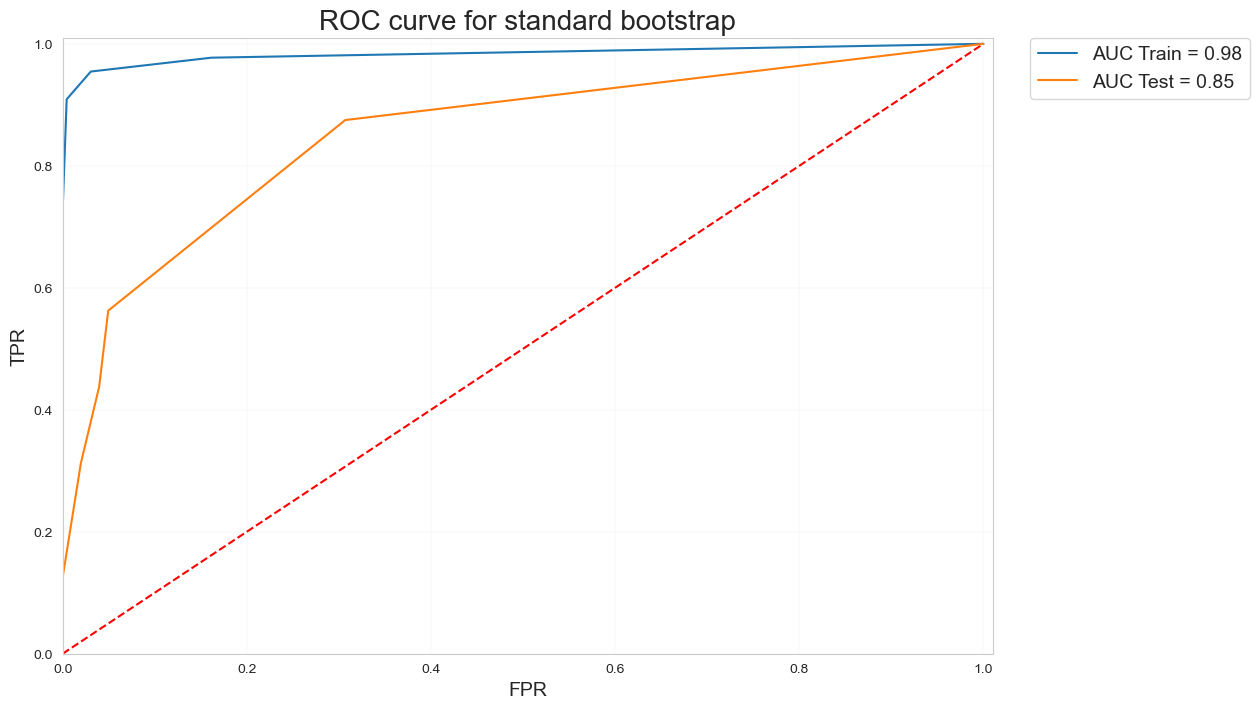

In [96]:
plt.figure(figsize=(12, 8))
font_size = 10

plt.grid(visible=True, linewidth=0.1)

plt.title(r"ROC curve for standard bootstrap", fontsize=2 * font_size)

plt.xlabel("FPR", fontsize=font_size + 4)
plt.ylabel("TPR", fontsize=font_size + 4)
plt.xticks(size=font_size)
plt.yticks(size=font_size)
plt.xlim([0, 1.01])
plt.ylim([0, 1.01])

plt.plot([0, 1], [0, 1], 'r--')
plt.plot(train_fpr, train_tpr, label=f"AUC Train = {train_auc:0.2f}")
plt.plot(test_fpr, test_tpr, label=f"AUC Test = {test_auc:0.2f}")

plt.legend(
    bbox_to_anchor=(1.04, 1),
    borderaxespad=0,
    loc="upper left",
    fontsize=font_size + 4
)

plt.show()

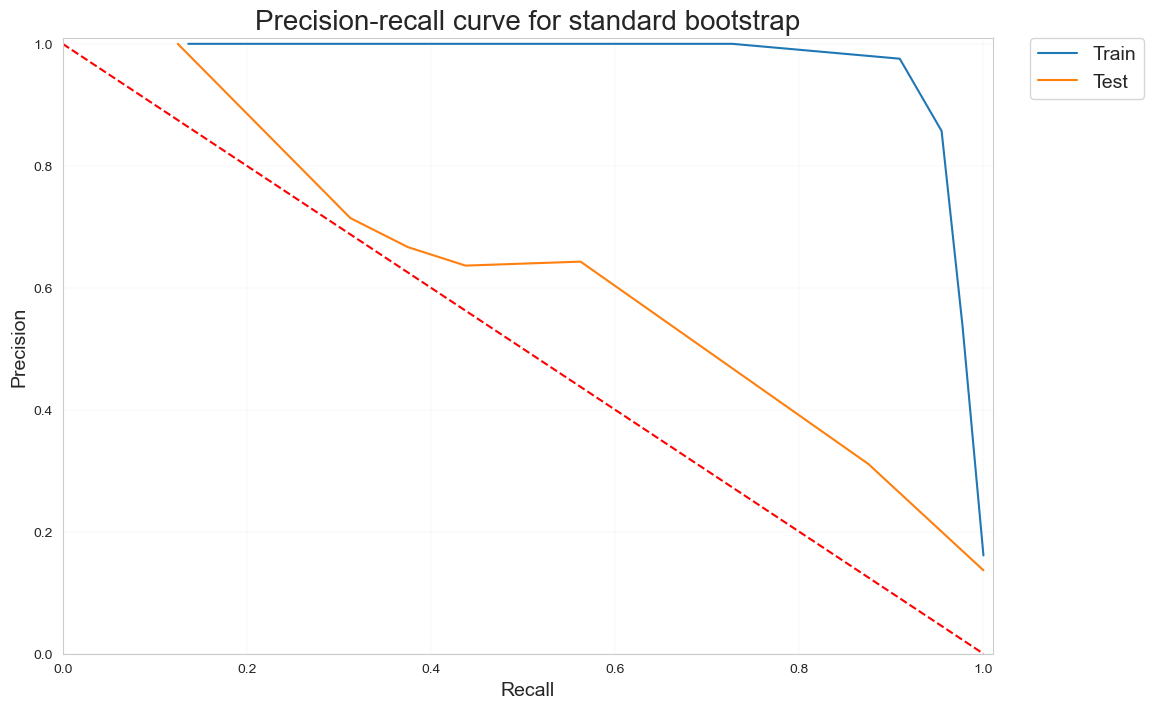

In [97]:
plt.figure(figsize=(12, 8))
font_size = 10

plt.grid(visible=True, linewidth=0.1)

plt.title(r"Precision-recall curve for standard bootstrap", fontsize=2 * font_size)

plt.xlabel("Recall", fontsize=font_size + 4)
plt.ylabel("Precision", fontsize=font_size + 4)
plt.xticks(size=font_size)
plt.yticks(size=font_size)
plt.xlim([0, 1.01])
plt.ylim([0, 1.01])

plt.plot([0, 1], [1, 0], 'r--')
plt.plot(train_recall, train_precision, label="Train")
plt.plot(test_recall, test_precision, label="Test")

plt.legend(
    bbox_to_anchor=(1.04, 1),
    borderaxespad=0,
    loc="upper left",
    fontsize=font_size + 4
)

plt.show()

Now we're going to look at the balance in the dataset `diabetes_samples.csv`. Compute the frequencies of diagnosis outcomes:

In [98]:
# Count the number of "Diabetes" and "No diabetes".
num_diabetes = list(y_train).count(True)
num_non_diabetes = list(y_train).count(False)

# Print the number of occurrences.
print('Number of patients with diabetes in the training set:', num_diabetes)
print('Number of patients with no diabetes in the training set:', num_non_diabetes)

# Print the frequencies.
print('Frequency of patients with diabetes in the training set:', num_diabetes / len(y_train))
print('Frequency of patients with no diabetes in the training set:', num_non_diabetes / len(y_train))

Number of patients with diabetes in the training set: 44
Number of patients with no diabetes in the training set: 229
Frequency of patients with diabetes in the training set: 0.16117216117216118
Frequency of patients with no diabetes in the training set: 0.8388278388278388


The training set clearly exhibits an imbalance, given that it consists of $44$ diabetic individuals and $229$ non-diabetic individuals. To rectify this issue, we introduce weights as a means of balancing the training set.

Each diabetic person will have the weight $\text{weight}_{\text{diabetic}} = \frac{1}{2 \cdot \text{number of diabetics}}$.

Each non-diabetic person will have the weight $\text{weight}_{\text{non-diabetic}} = \frac{1}{2 \cdot \text{number of non-diabetics}}$.

In this way, the training set becomes balanced because $\sum_{\text{diabetics}} \text{weight}_{\text{diabetic}} = \sum_{\text{non-diabetics}} \text{weight}_{\text{non-diabetic}} = \frac{1}{2}$.

In [99]:
N = y_train.shape[0]  # number of samples


# Find the weight ar a certain index.
def weight_at_index(i: int):
    if y_train[i]:
        return 1 / (2 * num_diabetes)
    return 1 / (2 * num_non_diabetes)


# Find all the weights.
balanced_weights = np.fromfunction(
    np.vectorize(weight_at_index),
    (N,),
    dtype=int,
)

Using weight balancing on the training set, we perform grid search on the hyperparameters and then train a random forest on the whole training set.

In [100]:
rng = np.random.default_rng(60012)

# Generate folds.
N = X_train.shape[0]  # number of samples
folds = generate_folds(N, num_folds=4, random_generator=rng)
# Set the number of features.
num_features = int(np.sqrt(X_train.shape[1]))

# Perform grid search on the hyperparameters.
best_hyperparams = grid_search_rf(
    X_train, y_train,
    columns_dict=columns_dict,
    folds=folds,
    num_trees_range=np.arange(1, 11),
    max_depth_range=np.arange(1, 11),
    num_features=num_features,
    sample_weights=balanced_weights,
    random_generator=rng,
)
# Extract the best hyperparameters.
best_num_trees = best_hyperparams["num_trees"]
best_max_depth = best_hyperparams["max_depth"]

# Print the best hyperparameters:
print("Best number of trees:", best_num_trees)
print("Best max depth:", best_max_depth)

Best number of trees: 8
Best max depth: 10


In [101]:
rng = np.random.default_rng(60012)

# Train a random forest using the best hyperparameters.
random_forest = train_rf(
    num_trees=best_num_trees,
    num_features=num_features,
    X_train=X_train,
    y_train=y_train,
    columns_dict=columns_dict,
    max_depth=best_max_depth,
    sample_weights=balanced_weights,
    random_generator=rng,
)

# Make predictions on the train/test sets.
y_train_pred = predict_rf(random_forest, X_train.to_numpy())
y_test_pred = predict_rf(random_forest, X_test.to_numpy())

# Compute metrics on the train/test sets.
in_sample_confusion_matrix = confusion_matrix(y_train.to_numpy(), y_train_pred)
weighted_in_sample_metrics = metrics_from_confusion(in_sample_confusion_matrix)
out_of_sample_confusion_matrix = confusion_matrix(y_test.to_numpy(), y_test_pred)
weighted_out_of_sample_metrics = metrics_from_confusion(out_of_sample_confusion_matrix)

# Print the best hyperparameters:
print("Number of trees:", best_num_trees)
print("Max depth:", best_max_depth)
print("")

# Print the in-sample and out-of-sample metrics and confusion matrix.
print("In-sample confusion matrix:")
print(in_sample_confusion_matrix)
print("Out-of-sample confusion matrix:")
print(out_of_sample_confusion_matrix)
classification_metrics_table([
    ["In-sample", weighted_in_sample_metrics],
    ["Out-of-sample", weighted_out_of_sample_metrics]
])

Number of trees: 8
Max depth: 10

In-sample confusion matrix:
[[ 44   7]
 [  0 222]]
Out-of-sample confusion matrix:
[[12  7]
 [ 4 94]]


,Accuracy,Precision,Recall,F1 score,Specificity
In-sample,0.974359,0.862745,1.00,0.926316,0.969432
Out-of-sample,0.905983,0.631579,0.75,0.685714,0.930693


We now plot the ROC and Precision-Recall curves.

In [102]:
# Compute probabilities.
y_train_prob = predict_prob_rf(random_forest, X_train.to_numpy())
y_test_prob = predict_prob_rf(random_forest, X_test.to_numpy())

# Compute the ROC curves.
train_auc, train_tpr, train_fpr, train_thresholds = roc_curve(
    y_train.to_numpy(), y_train_prob
)
test_auc, test_tpr, test_fpr, test_thresholds = roc_curve(
    y_test.to_numpy(), y_test_prob
)

# Compute the precision-recall curves.
train_precision, train_recall, train_thresholds = precision_recall_curve(
    y_train.to_numpy(), y_train_prob
)
test_precision, test_recall, test_thresholds = precision_recall_curve(
    y_test.to_numpy(), y_test_prob
)

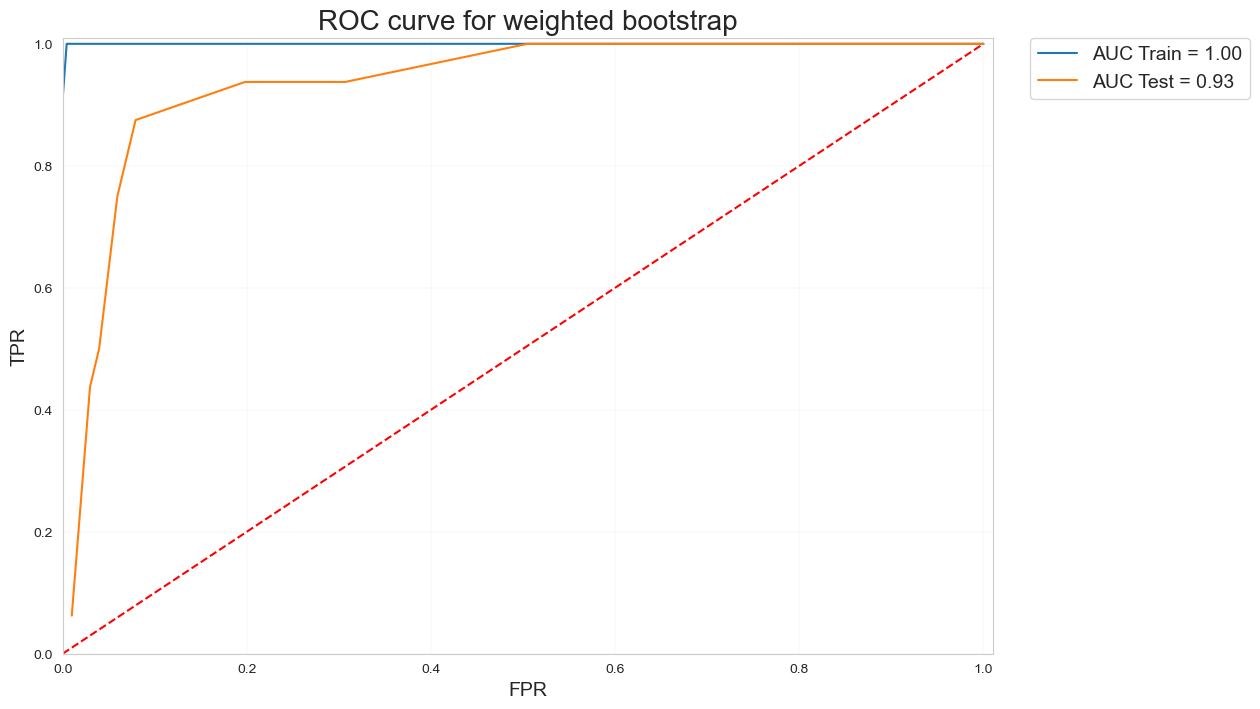

In [103]:
plt.figure(figsize=(12, 8))
font_size = 10

plt.grid(visible=True, linewidth=0.1)

plt.title(r"ROC curve for weighted bootstrap", fontsize=2 * font_size)

plt.xlabel("FPR", fontsize=font_size + 4)
plt.ylabel("TPR", fontsize=font_size + 4)
plt.xticks(size=font_size)
plt.yticks(size=font_size)
plt.xlim([0, 1.01])
plt.ylim([0, 1.01])

plt.plot([0, 1], [0, 1], 'r--')
plt.plot(train_fpr, train_tpr, label=f"AUC Train = {train_auc:0.2f}")
plt.plot(test_fpr, test_tpr, label=f"AUC Test = {test_auc:0.2f}")

plt.legend(
    bbox_to_anchor=(1.04, 1),
    borderaxespad=0,
    loc="upper left",
    fontsize=font_size + 4
)

plt.show()

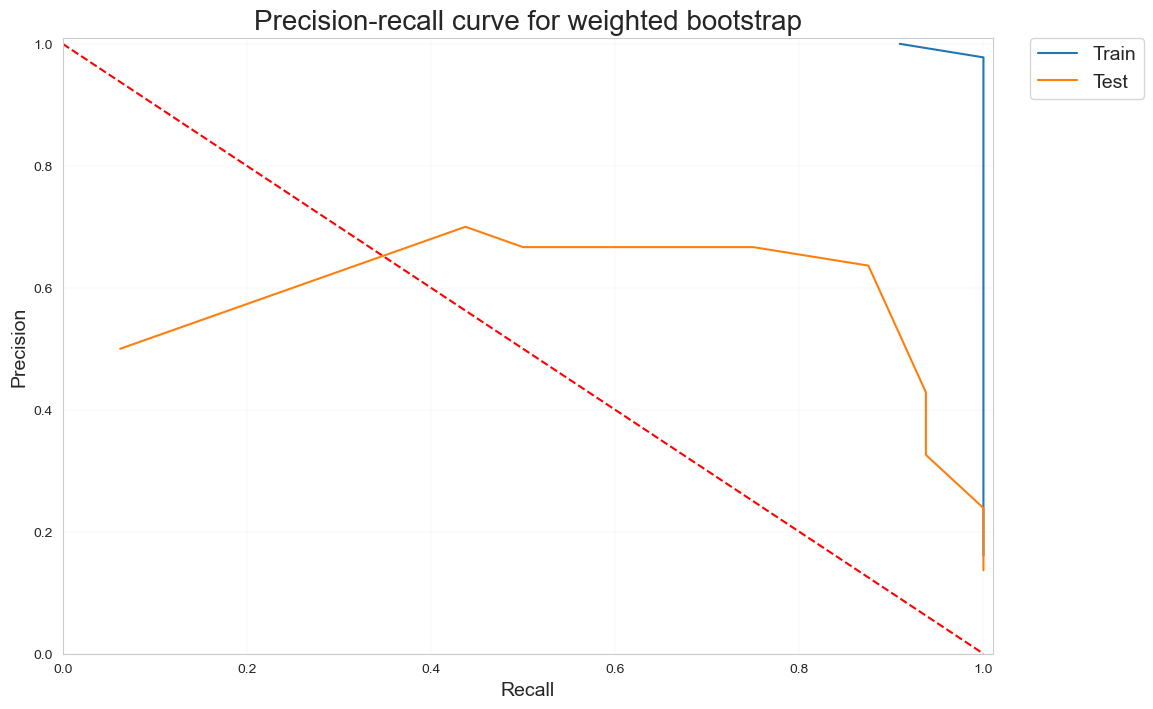

In [104]:
plt.figure(figsize=(12, 8))
font_size = 10

plt.grid(visible=True, linewidth=0.1)

plt.title(r"Precision-recall curve for weighted bootstrap", fontsize=2 * font_size)

plt.xlabel("Recall", fontsize=font_size + 4)
plt.ylabel("Precision", fontsize=font_size + 4)
plt.xticks(size=font_size)
plt.yticks(size=font_size)
plt.xlim([0, 1.01])
plt.ylim([0, 1.01])

plt.plot([0, 1], [1, 0], 'r--')
plt.plot(train_recall, train_precision, label="Train")
plt.plot(test_recall, test_precision, label="Test")

plt.legend(
    bbox_to_anchor=(1.04, 1),
    borderaxespad=0,
    loc="upper left",
    fontsize=font_size + 4
)

plt.show()

We now take a look at the standard and weighted bootstrap performance:

In [105]:
print("Normal bootstrap performance:")
classification_metrics_table([
    ["In-sample", uniform_in_sample_metrics],
    ["Out-of-sample", uniform_out_of_sample_metrics]
])

Normal bootstrap performance:


,Accuracy,Precision,Recall,F1 score,Specificity
In-sample,0.956044,0.970588,0.750,0.846154,0.995633
Out-of-sample,0.888889,0.666667,0.375,0.480000,0.970297


In [106]:
print("Weighted bootstrap performance:")
classification_metrics_table([
    ["In-sample", weighted_in_sample_metrics],
    ["Out-of-sample", weighted_out_of_sample_metrics]
])

Weighted bootstrap performance:


,Accuracy,Precision,Recall,F1 score,Specificity
In-sample,0.974359,0.862745,1.00,0.926316,0.969432
Out-of-sample,0.905983,0.631579,0.75,0.685714,0.930693


Upon analyzing the metrics, going from standard bootstrap to weighted bootstrap results in small increase in accuracy, a decrease in precision, a high increase in recall and F1-score and a small decrease in specificity.

By looking at the ROC curves and AUC, we notice that both models are above random and have high AUC, but the weighted one performs better both in-sample and out-of-sample. This may happen because of the following reasons:
1. The weighted bootstrap can improve the quality of the training data by creating more balanced datasets.
2. The weighted bootstrap can help to reduce overfitting on the majority class. When training a model on imbalanced data, it is common for the model to become overly biased towards the majority class, leading to poor performance on the minority class.

After examining the precision-recall curves, we notice that both models exhibit very good in-sample performance, but they don't perform so well out-of-sample, with the weighted bootstrap precision-recall curve lying partially under the diagonal. This is because adding weights affects the balance of the classes in the training data and cause the model to be biased towards the majority class. In our case, the model becomes too focused on the minority class and performs worse on the majority class.

Overall, the weighted bootstrap model seems to be performing better than the standard one.

#### 2.2	Support Vector Machine (SVM) (30 marks)

We convert the output labels from boolean to binary.

In [107]:
# Map to convert output from boolean to binary (-1 and 1).
labels_map = {True: 1.0, False: -1.0}

In [108]:
X_train_svm = X_train.to_numpy()
y_train_svm = y_train.replace(labels_map).to_numpy()

X_test_svm = X_test.to_numpy()
y_test_svm = y_test.replace(labels_map).to_numpy()

# Change the type of the output array to np.float64.
y_train_svm = y_train_svm.astype('float64')
y_test_svm = y_test_svm.astype('float64')

##### 2.2.1

Linear Support Vector Machine (SVM) is a machine learning algorithm used for classification tasks. It learns a linear decision boundary that separates the classes in the data, making it particularly useful for problems where the classes are well separated.

It works by finding the hyperplane that maximally separates the two classes in the training data, based on a margin that is defined as the distance between the hyperplane and the closest data points from each class.

One of the disadvantages of linear SVM is that it assumes a linear decision boundary, which may not be appropriate for all datasets.

The hinge loss is defined as
$$
\mathcal L (\boldsymbol w)
= \frac{1}{2} \| \boldsymbol w \|^2
    + \lambda \sum_{i=1}^n \max \bigg( 0, 1-y_i (x^{(i)} \cdot \boldsymbol w  + \boldsymbol b) \bigg) \, .
$$
where
- $\boldsymbol w$ is the vector of weights.
- $\lambda$ the regularisation parameter.
- $\boldsymbol b$ is the intercept (it is **not** included in our `X` as an additional column of $1$'s).

In [109]:
def loss_svm_linear(
        X, y, weights, intercept,
        regul_strength=1e6
):
    """
    Parameters
    ----------
    :param X: (numpy.ndarray) of shape (N, D).
        Input data.
    :param y: (numpy.ndarray) of shape (N, ).
        Labels.
    :param weights: (numpy.ndarray) of shape (D, ).
        Weights for the given features.
    :param intercept: (scalar).
        Intercept.
    :param regul_strength: (scalar), optional, default=1e5
        Regularisation strength (lambda in our formula).

    Returns
    ----------
    :rtype: (scalar)
    :return: Hinge loss.
    """

    distances = 1 - y * (X @ weights + intercept)
    distances[distances < 0] = 0  # Equivalent to max(0, distance).
    hinge = regul_strength * distances.sum()

    # Return cost.
    return 0.5 * np.dot(weights, weights) + hinge

The gradients of the loss function with respect to the weights and bias are given by:

$$
\frac{\partial L}{\partial w}
    = w + \lambda \sum_{i = 1}^{N}
        \begin{cases}
            0                 & \quad \text{, if } 1 - y^{(i)} \left( x^{(i)} w + b \right) \le 0 \\
            - y^{(i)} x^{(i)} & \quad \text{, otherwise} \\
        \end{cases}
$$

$$
\frac{\partial L}{\partial b}
    = \lambda \sum_{i = 1}^{N}
        \begin{cases}
            0         & \quad \text{, if } 1 - y^{(i)} \left( x^{(i)} w + b \right) \le 0 \\
            - y^{(i)} & \quad \text{, otherwise} \\
        \end{cases}
$$

In [110]:
def gradients_svm_linear(
        X_batch, y_batch, weights, intercept,
        regul_strength=1e6
):
    """
    Parameters
    ----------
    :param X_batch: (numpy.ndarray) of shape (N, D).
        Input data.
    :param y_batch: (numpy.ndarray) of shape (N, ).
        Labels.
    :param weights: (numpy.ndarray) of shape (D, ).
        Weights for the given features.
    :param intercept: (scalar).
        Intercept.
    :param regul_strength: (scalar), optional, default=1e6
        Regularisation strength (lambda in our formula).

    Returns
    ----------
    :rtype: (scalar)
    :return: Hinge loss.
    """

    # If only one example is passed:
    if type(y_batch) == np.float64:
        y_batch = np.asarray([y_batch])
        X_batch = np.asarray([X_batch])  # gives multidimensional array

    N, D = X_batch.shape  # number of samples and number of features

    # Compute distances.
    distances = 1 - (y_batch * (X_batch @ weights + intercept))

    # Compute the derivative w.r.t. weights.
    der_weights = weights.copy()  # derivative of the first term
    der_max = np.zeros((D,))
    for ind, dist in enumerate(distances):
        if max(0, dist) != 0:
            der_max -= y_batch[ind] * X_batch[ind]
    der_weights += regul_strength * der_max  # derivative of the second term

    # Compute the derivative w.r.t. intercept.
    der_max = 0  # derivative of the first term
    for ind, dist in enumerate(distances):
        if max(0, dist) != 0:
            der_max -= y_batch[ind]
    der_intercept = regul_strength * der_max  # derivative of the second term

    return der_weights, der_intercept

Both of the previous functions are used to implement stochastic gradient descent (SGD). The weights are updated iteratively using a specified learning rate $\alpha$. In addition, we incorporate a stopping condition that terminates the learning process as soon as the cost function has not changed beyond a manually specified percentage.

The learning happens through updating the weights and intercept according to

$$
w = w - \alpha \frac{\partial L}{\partial w}
$$

$$
b = b - \alpha \frac{\partial L}{\partial b}
$$

where

- $w$ are the weights and $b$ is the intercept.
- $L$ is the hinge loss, which is computed using `loss_svm_linear()`.
- the gradients $\frac{\partial L}{\partial w}$ and $\frac{\partial L}{\partial b}$ are computed using `gradients_svm_linear()`.

In [111]:
def sgd_svm_linear(
        X, y,
        max_iterations=2000,
        stop_criterion=0.01,
        learning_rate=1e-5,
        regul_strength=1e6,
        random_generator=np.random.default_rng(),
        print_intermediate=False,
):
    """
    Parameters
    ----------
    :param X: (numpy.ndarray) of shape (N, D).
        Input data.
    :param y: (numpy.ndarray) of shape (N, ).
        Input labels.
    :param max_iterations: (int)
        Maximum number of iterations.
    :param stop_criterion: (scalar)
        Stop criterion value.
    :param learning_rate: (scalar).
        Learning rate used in gradient descent.
    :param regul_strength: (scalar), optional, default=1e6
        Regularisation strength (lambda in our formula).
    :param random_generator: (np.Generator), optional, default=np.random.default_rng().
        Random generator used for shuffling the indexes.
    :param print_intermediate: (boolean)
        If true, print the outcome and the (2^n)th iterations.

    Returns
    ----------
    :rtype: (tuple)
    :return:
        (numpy.ndarray) Weights.
        (scalar) Intercept.
    """

    D = X.shape[1]  # number of features

    # Initialise weights and intercept to 0.
    weights = np.zeros(D)
    intercept = 0

    nth = 0
    # Initialise starting cost as infinity.
    prev_cost = np.inf

    # Stochastic gradient descent
    indices = np.arange(len(y))
    for iteration in range(1, max_iterations + 1):
        # Shuffle to prevent repeating update cycles.
        random_generator.shuffle(indices)
        X, y = X[indices], y[indices]

        for xi, yi in zip(X, y):
            # Compute gradients.
            der_weights, der_intercept = gradients_svm_linear(
                xi, yi, weights, intercept,
                regul_strength=regul_strength
            )
            # Update weights and intercept.
            weights -= learning_rate * der_weights
            intercept -= learning_rate * der_intercept

        # Convergence check on (2^n)'th iteration.
        if iteration == 2 ** nth or iteration == max_iterations:
            # Compute cost
            cost = loss_svm_linear(
                X, y, weights, intercept,
                regul_strength=regul_strength
            )

            # Print intermediate costs.
            if print_intermediate:
                print("Iteration is:", iteration, ", Cost is:", cost)

            # Stop criterion.
            if abs(prev_cost - cost) < stop_criterion * prev_cost:
                return weights, intercept

            # Update cost and nth value.
            prev_cost = cost
            nth += 1

    return weights, intercept

The predictions of a linear SVM are given by:

$$
y_{\text{pred}} = \operatorname{sign} (XW + b)
$$

In [112]:
def predict_svm_linear(X, weights, intercept):
    """
    Parameters
    ----------
    :param X: (numpy.ndarray) of shape (N, D).
        Input data.
    :param weights: (numpy.ndarray) of shape (D, ).
        Weights for the given features.
    :param intercept: (scalar).
        Intercept.

    Returns
    ----------
    :rtype: (numpy.ndarray) of shape (N, )
    :return: Predictions.
    """

    return np.sign(X @ weights + intercept)

The `cross_validation_svm_linear()` function employs $T$-fold cross-validation and returns the average score (in our case, accuracy) of the provided hyperparameters in the following way:

1. Partition the training data into $T$ equal subsets $S_1, \ldots, S_T$ called folds.
2. Iterate through the folds. For every fold $S_i$, we
    - Keep $S_i$ as the validation set.
    - Train a model on the rest of the folds.
    - Evaluate the model's performance on the validation set and compute a score (in our case, accuracy).
3. Compute the average score (in our case, average accuracy) over all $T$ folds.

This average score can be seen as a measure of how well the model predicts out-of-sample (that is, on unseen data during the training).

In [113]:
def cross_validation_svm_linear(
        X_train, y_train, folds,
        max_iterations=2000,
        stop_criterion=0.01,
        learning_rate=1e-5,
        regul_strength=1e6,
        random_generator=np.random.default_rng(),
):
    """
    Parameters
    ----------
    :param X_train: (pd.Dataframe) of shape (N, D).
        Training input data.
    :param y_train: (pd.Series) of shape (N,).
        Training labels.
    :param folds: (list), optional, default=None.
        Folds used in cross-validation.
        If folds=None, 5 folds are randomly generated.
    :param max_iterations: (int)
        Maximum number of iterations.
    :param learning_rate: (scalar).
        Learning rate used in gradient descent.
    :param regul_strength: (scalar), optional, default=1e6
        Regularisation strength (lambda in our formula).
    :param random_generator: (np.Generator), optional, default=np.random.default_rng().
        Random generator used for shuffling the indexes.

    Returns
    ----------
    :rtype: (scalar)
    :return: Average accuracy.
    """

    N = X_train.shape[0]  # number of samples

    # Generate folds if they are missing.
    if folds is None:
        folds = generate_folds(N, num_folds=5)

    scores = []

    for i in range(len(folds)):
        # Get the training/validation data.
        X_train_i, y_train_i, X_val_i, y_val_i = get_train_val_sets(X_train, y_train, folds[i])

        # Compute the weights and bias.
        weights, intercept = sgd_svm_linear(
            X_train_i, y_train_i,
            max_iterations=max_iterations,
            stop_criterion=stop_criterion,
            learning_rate=learning_rate,
            regul_strength=regul_strength,
            random_generator=random_generator,
        )

        # Make predictions.
        y_val_i_pred = predict_svm_linear(X_val_i, weights, intercept)

        # Evaluate the SVM.
        score_i = accuracy(y_val_i, y_val_i_pred)
        scores.append(score_i)

    # Return the average score.
    return np.mean(scores)

We now use a 4-fold cross-validation to optimise the hardness hyperparameter $\lambda$, which controls the boundary violation penalty.

In [114]:
rng = np.random.default_rng(seed=60012)

lambda_values = np.linspace(10, 1000, num=100)

# Generate folds.
N = X_train.shape[0]  # number of samples
folds = generate_folds(N, num_folds=4, random_generator=rng)

lambda_scores = np.zeros(lambda_values.shape)
for i, lamb in enumerate(lambda_values):
    lambda_scores[i] = cross_validation_svm_linear(
        X_train_svm, y_train_svm, folds,
        max_iterations=2000,
        stop_criterion=0.01,
        learning_rate=1e-5,
        regul_strength=lamb,
        random_generator=rng,
    )
    # print("CV_AVG-ACC@regul_strength=", lamb, ": ", lambda_scores[i], sep="")

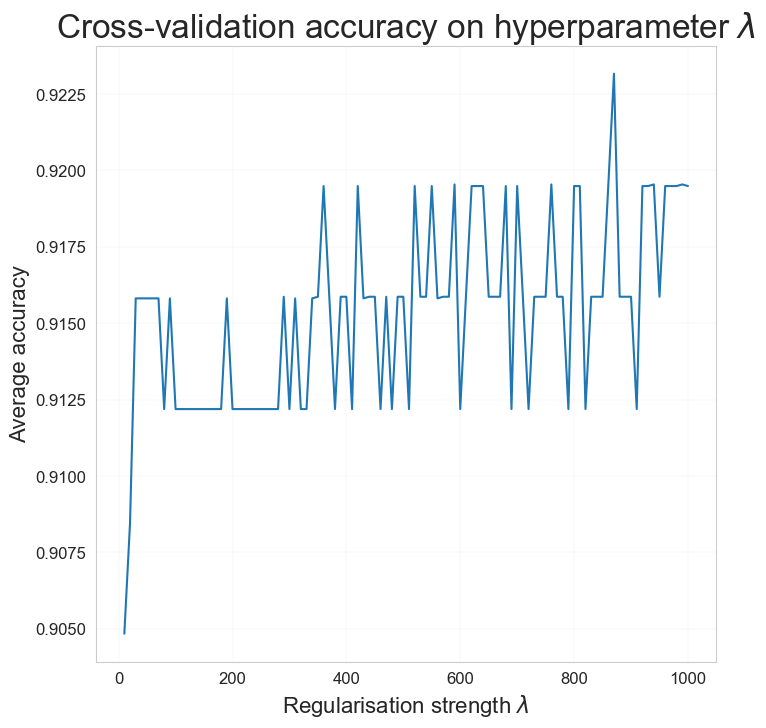

In [115]:
plt.figure(figsize=(8, 8))
font_size = 12

plt.grid(visible=True, linewidth=0.1)

plt.title(r"Cross-validation accuracy on hyperparameter $\lambda$", fontsize=2 * font_size)

plt.xlabel(r"Regularisation strength $\lambda$", fontsize=font_size + 4)
plt.ylabel("Average accuracy", fontsize=font_size + 4)
plt.xticks(size=font_size)
plt.yticks(size=font_size)

plt.plot(lambda_values, lambda_scores)

plt.show()

The limits of low hardness and high hardness in linear SVM can be discussed as follows:
1. **Low hardness** (small value of $\lambda$): The model allows for more misclassifications within the margin, leading to a wider margin and a more flexible decision boundary. This can be useful when the data is not linearly separable or when there is too much noise, as a more flexible decision boundary can better capture the underlying patterns in the data.
    However, its disadvantage is that overfitting may occur if the margin is too wide and captures too much noise in the data.
2. **High hardness** (large value of $\lambda$): The model enforces a stricter constraint on the margin, leading to a narrower margin and a more rigid decision boundary. This can be useful when the data is linearly separable and when there is minimal noise, as a rigid decision boundary can better capture the true underlying structure of the data.
    However, its disadvantage is that underfitting may occur if the margin is too narrow and fails to capture the true decision boundary of the data.

In our case, as we increase $\lambda$, the accuracy keeps increasing until it starts fluctuating. This may happen because of the randomness of stochastic gradient descent and the stopping criterion. Moreover, this fluctuation suggests that no matter how much we increase the penalty, the model doesn't perform any better. This is a strong indication that the data in the model is not linearly separable.

Thus, we restrict the $\lambda$ range and repeat the process.

In [116]:
rng = np.random.default_rng(seed=60012)

lambda_values = np.linspace(2, 50, num=25)

# Generate folds.
N = X_train.shape[0]  # number of samples
folds = generate_folds(N, num_folds=4, random_generator=rng)

lambda_scores = np.zeros(lambda_values.shape)
for i, lamb in enumerate(lambda_values):
    lambda_scores[i] = cross_validation_svm_linear(
        X_train_svm, y_train_svm, folds,
        max_iterations=2000,
        stop_criterion=0.01,
        learning_rate=1e-5,
        regul_strength=lamb,
        random_generator=rng,
    )
    # print("CV_AVG-ACC@regul_strength=", lamb, ": ", lambda_scores[i], sep="")

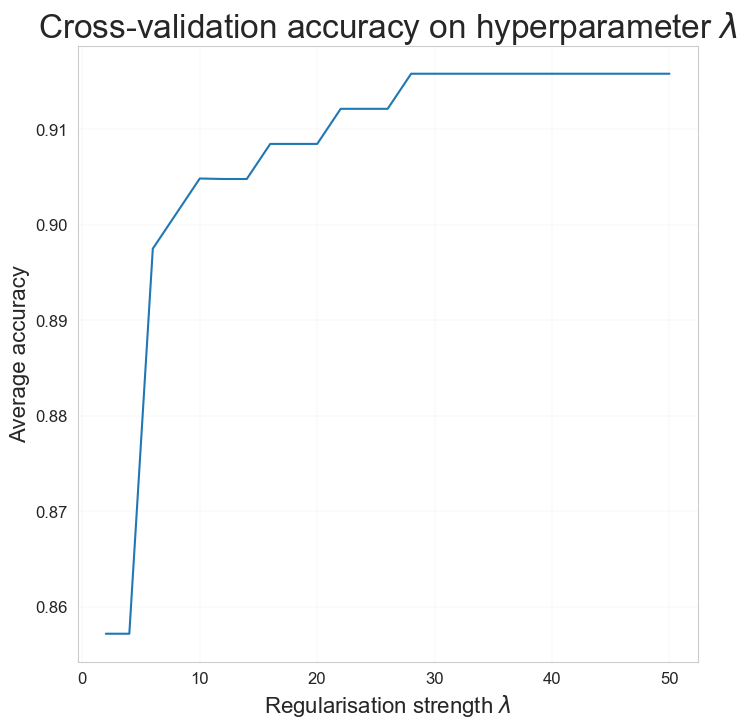

In [117]:
plt.figure(figsize=(8, 8))
font_size = 12

plt.grid(visible=True, linewidth=0.1)

plt.title(r"Cross-validation accuracy on hyperparameter $\lambda$", fontsize=2 * font_size)

plt.xlabel(r"Regularisation strength $\lambda$", fontsize=font_size + 4)
plt.ylabel("Average accuracy", fontsize=font_size + 4)
plt.xticks(size=font_size)
plt.yticks(size=font_size)

plt.plot(lambda_values, lambda_scores)

plt.show()

##### 2.2.2

For two hyperplanes $y = xw_1 + b_1$ and $y = xw_2 + b_2$, the cosine of the angle between them is given by:

$$
\frac{w_1 \cdot w_2}{||w_1||||w_2||}
$$

In [118]:
def cosine_hyperplanes(weights1, weights2):
    """
    Parameters
    ----------
    :param weights1: (numpy.ndarray) of shape (D, ).
        Weights of the first hyperplane.
    :param weights2: (numpy.ndarray) of shape (D, ).
        Weights of the second hyperplane.

    Returns
    ----------
    :rtype: (scalar)
    :return: Cosine of the angle between the 2 hyperplanes.
    """

    norm_weights1 = np.linalg.norm(weights1)
    norm_weights2 = np.linalg.norm(weights2)

    return np.dot(weights1, weights2) / (norm_weights1 * norm_weights2)

In section 2.2.1, we explore various values of the hardness hyperparameter $\lambda$. For each value, we obtain a hyperplane. Now we compute the cosine of the angle between each pair of hyperplanes and present the results on a square heatmap as a function of the hardness hyperparameter.

In [119]:
rng = np.random.default_rng(seed=60012)

# Get the hyperplanes weights.
hyperplanes_weights = []
for lamb in lambda_values:
    weights, _ = sgd_svm_linear(
        X_train_svm, y_train_svm,
        max_iterations=2000,
        stop_criterion=0.01,
        learning_rate=1e-5,
        regul_strength=lamb,
        random_generator=rng,
    )
    hyperplanes_weights.append(weights)


# Return the cosine at a given index.
def cosine_at_index(i: int, j: int):
    return cosine_hyperplanes(hyperplanes_weights[i], hyperplanes_weights[j])


# Get the cosine between each pair of hyperplanes.
cosine_array = np.fromfunction(
    np.vectorize(cosine_at_index),
    (len(lambda_values), len(lambda_values)),
    dtype=int
)

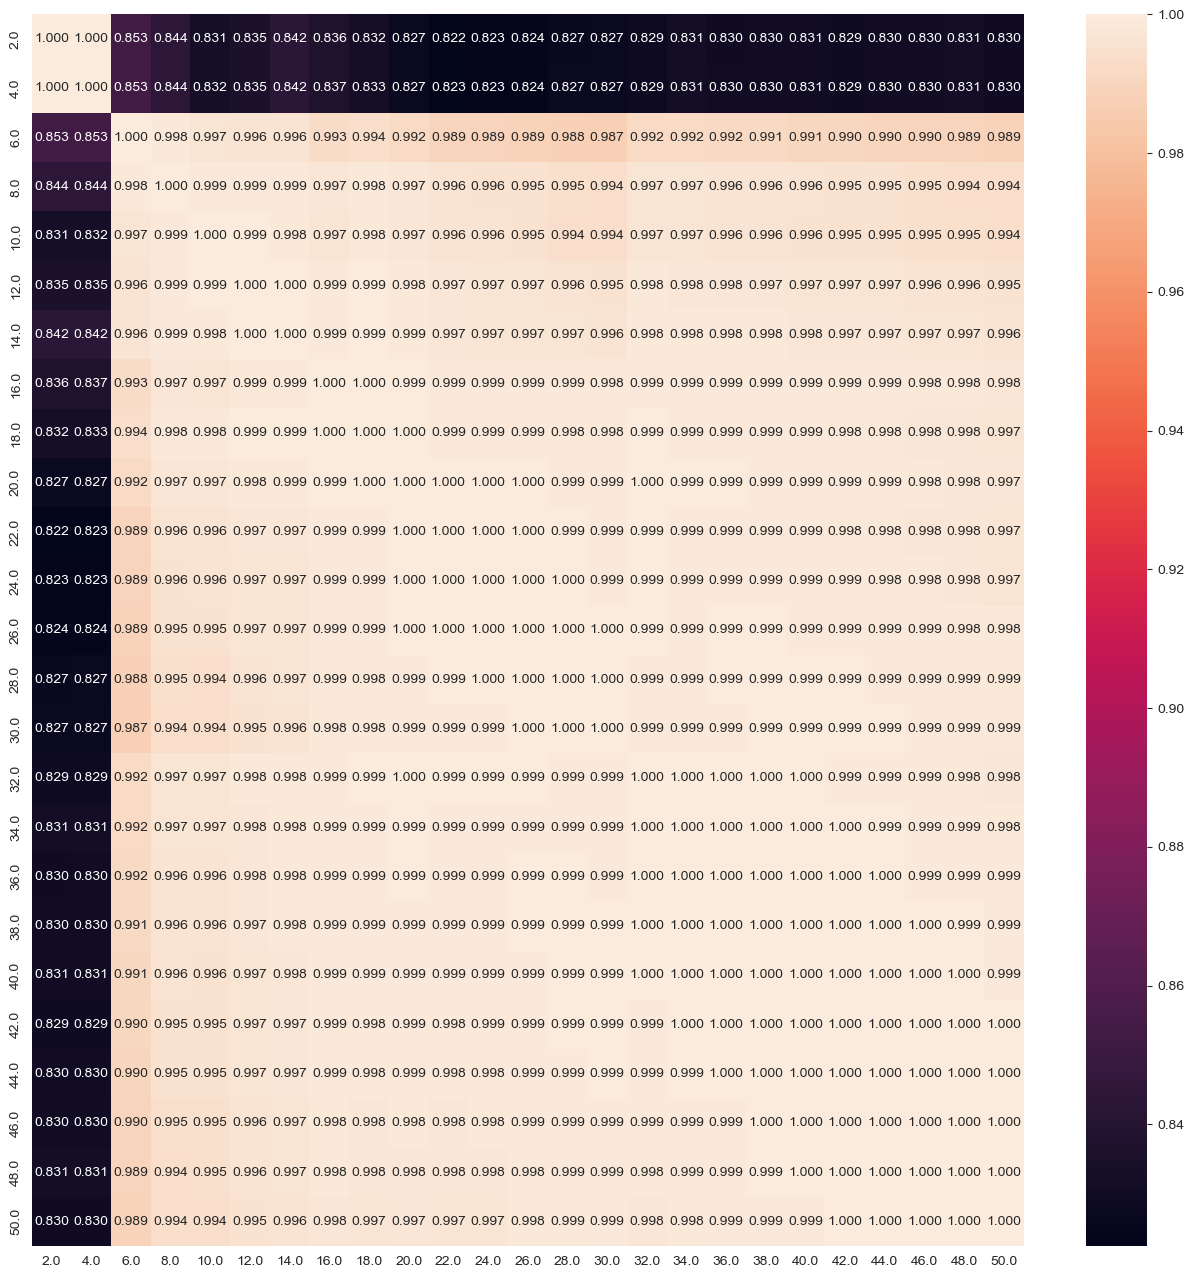

In [120]:
plt.figure(figsize=(16, 16))

sns.heatmap(
    cosine_array,
    xticklabels=lambda_values,
    yticklabels=lambda_values,
    annot=True,
    fmt='.3f',
)

plt.show()

We observe that the cosine values converge to 1, indicating that, regardless of the penalty, the model will produce the same plane or parallel planes. This supports our earlier hypothesis that there exists a point beyond which increasing the penalty does not lead to further improvements in the model's performance.

##### 2.2.3

We will now set the hardness hyperparameter $\lambda$ to its optimal value and proceed to train the linear SVM using the complete `diabetes_samples.csv` dataset. Afterward, we will evaluate the model's performance on the `diabetes_test.csv` dataset using accuracy, precision, and F-score metrics.

In [121]:
rng = np.random.default_rng(seed=60012)

# Get the best lambda.
best_lambda_index = np.argmax(lambda_scores)
best_lambda = lambda_values[best_lambda_index]

# Train the linear SVM on the full dataset.
weights, intercept = sgd_svm_linear(
    X_train_svm, y_train_svm,
    max_iterations=2000,
    stop_criterion=0.01,
    learning_rate=1e-5,
    regul_strength=5,
    random_generator=rng
)

# Make predictions on the train/test sets.
y_train_pred = predict_svm_linear(X_train_svm, weights, intercept)
y_test_pred = predict_svm_linear(X_test_svm, weights, intercept)

# Compute metrics on the train/test sets.
in_sample_confusion_matrix = confusion_matrix(y_train_svm, y_train_pred, numerical=True)
in_sample_metrics = metrics_from_confusion(in_sample_confusion_matrix)
out_of_sample_confusion_matrix = confusion_matrix(y_test_svm, y_test_pred, numerical=True)
out_of_sample_metrics = metrics_from_confusion(out_of_sample_confusion_matrix)

# Print the best lambda:
print("Best lambda:", best_lambda)

# Print the in-sample and out-of-sample metrics and confusion matrix.
print("In-sample confusion matrix:")
print(in_sample_confusion_matrix)
print("Out-of-sample confusion matrix:")
print(out_of_sample_confusion_matrix)
classification_metrics_table([
    ["In-sample", in_sample_metrics],
    ["Out-of-sample", out_of_sample_metrics]
])

Best lambda: 28.0
In-sample confusion matrix:
[[ 21   3]
 [ 23 226]]
Out-of-sample confusion matrix:
[[  8   1]
 [  8 100]]


,Accuracy,Precision,Recall,F1 score,Specificity
In-sample,0.904762,0.875000,0.477273,0.617647,0.986900
Out-of-sample,0.923077,0.888889,0.500000,0.640000,0.990099


The accuracy is high on both train and test datasets, thus the model is performing well at classifying the data.

But notice that the model has high precision and low F1-score (thus low recall) on both sets. Precision represents the proportion of true positives among all positive predictions made, while recall measures the proportion of true positives among all actual positive instances. This means that the model has correctly identified a small proportion of the positive instances and has made very few false positive predictions. Hence, the model has a high probability of correctly identifying the positive cases, but a low probability of identifying all the positive cases (since it is likely to miss a large number of actual positive instances).
This behaviour can also be explained by the imbalance in the dataset: in order to maximize the accuracy, the model needs to be able to precisely identify the negative instances (since that is the predominant class). By looking at the specificity, we see that we are correct: it is close to 1 in both datasets.

##### 2.2.4

Kernel Support Vector Machine (SVM) is machine learning algorithm that extends the capabilities of linear SVM by allowing for non-linear decision boundaries.

It works by transforming the input data into a high-dimensional feature space using a kernel function, which allows the algorithm to find a non-linear decision boundary that separates the classes in the data.

The `kernel_matrix()` function returns the sigmoid kernel.

In [122]:
def kernel_matrix(X1, X2, sigma):
    """
    Parameters
    ----------
    :param X1: (numpy.ndarray) of shape (N1, D1).
    :param X2: (numpy.ndarray) of shape (N2, D2).
    :param sigma: (scalar)
        Sigma Hyperparameter.

    Returns
    ----------
    :rtype: (numpy.ndarray) of shape (N1, N2).
    :return: Returns the K matrix of sigmoid kernel expressions.
    """

    n1 = X1.shape[0]
    n2 = X2.shape[0]
    kernel = np.zeros((n1, n2))

    # Here we define the sigmoid kernel.
    for i in range(n1):
        for j in range(n2):
            kernel[i][j] = np.tanh(sigma * (X1[i] @ X2[j]) + 1)

    return kernel

The loss function is computed using the following formula:

$$
L = \frac{1}{2} u^T K u + \lambda \sum_{i = 1}^{N} \max \left\{ 0, 1 - y^{(i)} \left( K^{(i)} u + b \right) \right\}
$$


In [123]:
def loss_svm_kernel(
        u, K, y,
        regul_strength=1e3,
        intercept=0
):
    """
    Parameters
    ----------
    :param u: (numpy.ndarray).
        Weights.
    :param K: (numpy.ndarray).
        Kernel matrix.
    :param y: (numpy.ndarray).
        Vector of training targets.
    :param regul_strength: (scalar), optional, default=1e3
        Regularisation strength (lambda in our formula).
    :param intercept: (scalar), optional, default=0.
        Intercept.

    Returns
    ----------
    :rtype: (scalar).
    :return: Loss value.
    """

    distances = 1 - y * (K @ u + intercept)
    distances[distances < 0] = 0  # equivalent to max(0, distance)
    hinge = regul_strength * distances.sum()

    return 0.5 * np.dot(u, K @ u) + hinge

The gradients of the loss function with respect to the weights and bias are given by:

$$
\frac{\partial L}{\partial w}
    = K u + \lambda \sum_{i = 1}^{N}
        \begin{cases}
            0                 & \quad \text{, if } 1 - y^{(i)} \left( K^{(i)} u + b \right) \le 0 \\
            - y^{(i)} K^{(i)} & \quad \text{, otherwise} \\
        \end{cases}
$$

$$
\frac{\partial L}{\partial b}
    = \lambda \sum_{i = 1}^{N}
        \begin{cases}
            0         & \quad \text{, if } 1 - y^{(i)} \left( K^{(i)} u + b \right) \le 0 \\
            - y^{(i)} & \quad \text{, otherwise} \\
        \end{cases}
$$

In [124]:
def gradients_svm_kernel(
        u, K_batch, y_batch,
        regul_strength=1e3,
        intercept=0
):
    """
    Parameters
    ----------
    :param u: (numpy.ndarray).
        Weights.
    :param K_batch: (numpy.ndarray).
        Batches of kernel matrix's, obtained from batches of X).
    :param y_batch: (numpy.ndarray).
        Batches of vectors of training target variables.
    :param regul_strength: (scalar), optional, default=1e3
        Regularisation strength (lambda in our formula).
    :param intercept: (scalar), optional, default=0.
        Intercept.

    Returns
    ----------
    :rtype: (tuple).
    :return:
        (numpy.ndarray) Derivative w.r.t. weights (u).
        (scalar) Derivative w.r.t. intercept.
    """

    # If only one example is passed
    if type(y_batch) == np.float64 or type(y_batch) == np.int32:
        y_batch = np.asarray([y_batch])
        K_batch = np.asarray([K_batch])  # gives multidimensional array

    N = len(y_batch)  # number of samples

    distances = 1 - y_batch * (K_batch @ u + intercept)

    # Compute the gradient w.r.t. weights.
    der_weights = np.zeros(len(u))
    der_weights += K_batch @ u  # derivative of the first term
    der_max = np.zeros(len(u))
    for ind, dist in enumerate(distances):
        if max(0, dist) != 0:
            der_max -= y_batch[ind] * K_batch[ind]
    der_weights += regul_strength * der_max  # derivative of the second term

    # Compute the derivative w.r.t. intercept.
    der_max = 0  # derivative of the first term
    for ind, dist in enumerate(distances):
        if max(0, dist) != 0:
            der_max -= y_batch[ind]
    der_intercept = regul_strength * der_max  # derivative of the second term

    return der_weights, der_intercept

Both of the previous functions are used to implement stochastic gradient descent (SGD). The weights are updated iteratively using a specified learning rate $\alpha$. In addition, we incorporate a stopping condition that terminates the learning process as soon as the cost function has not changed beyond a manually specified percentage.

The learning happens through updating the weights and intercept according to

$$
w = w - \alpha \frac{\partial L}{\partial w}
$$

$$
b = b - \alpha \frac{\partial L}{\partial b}
$$

where

- $w$ are the weights and $b$ is the intercept.
- $L$ is the previously defined loss, which is computed using `loss_svm_kernel()`.
- the gradients $\frac{\partial L}{\partial w}$ and $\frac{\partial L}{\partial b}$ are computed using `gradients_svm_kernel()`.

In [125]:
def sgd_svm_kernel(
        K, y,
        batch_size=32,
        max_iterations=4000,
        stop_criterion=0.001,
        learning_rate=1e-4,
        regul_strength=1e3,
        random_generator=np.random.default_rng(),
        print_intermediate=False
):
    """
    Parameters
    ----------
    :param K: (numpy.ndarray).
        Kernel matrix.
    :param y: (numpy.ndarray).
        Vector of training targets.
    :param max_iterations: (int)
        Maximum number of iterations.
    :param learning_rate: (scalar).
        Learning rate used in gradient descent.
    :param stop_criterion: (scalar)
        Stop criterion value.
    :param regul_strength: (scalar), optional, default=1e6
        Regularisation strength (lambda in our formula).
    :param random_generator: (np.Generator), optional, default=np.random.default_rng().
        Random generator used for shuffling the indexes.
    :param print_intermediate: (boolean)
        If true, print the outcome and the (2^n)th iterations.

    Returns
    ----------
    :rtype: (tuple)
    :return:
        (numpy.ndarray) Optimised weights (u).
        (scalar) Optimised intercept.
    """

    # Initialise u and intercept.
    u = np.zeros(K.shape[1])
    intercept = 0

    nth = 0
    # Initialise starting cost as infinity.
    prev_cost = np.inf

    # Stochastic gradient descent.
    indices = np.arange(len(y))
    for iteration in range(1, max_iterations + 1):
        # Shuffle to prevent repeating update cycles.
        random_generator.shuffle(indices)
        batch_idx = indices[:batch_size]
        K_b, y_b = K[batch_idx], y[batch_idx]

        for ki, yi in zip(K_b, y_b):
            # Compute gradient.
            der_u, der_intercept = gradients_svm_kernel(
                u, ki, yi,
                regul_strength=regul_strength,
                intercept=intercept
            )
            # Update u and intercept.
            u -= learning_rate * der_u
            intercept -= learning_rate * der_intercept

        # Convergence check on (2^n)'th iteration.
        if iteration == 2 ** nth or iteration == max_iterations:
            # Compute cost.
            cost = loss_svm_kernel(
                u, K, y,
                regul_strength=regul_strength,
                intercept=intercept,
            )

            # Print intermediate results.
            if print_intermediate:
                print("Iteration is:", iteration, ", Cost is:", cost)

            # Stop criterion.
            if abs(prev_cost - cost) < stop_criterion * prev_cost:
                return u, intercept

            # Update cost and nth value.
            prev_cost = cost
            nth += 1

    return u, intercept

The predictions of a kernel SVM are given by:

$$
y_{\text{pred}} = \operatorname{sign} (Ku + b)
$$

In [126]:
def predict_svm_kernel(
        X, X_train, u, sigma,
        intercept=0,
):
    """
    Parameters
    ----------
    :param X: (numpy.ndarray) of shape (K, D)
        Incoming input features.
    :param X_train: (numpy.ndarray) of shape (N, D)
        Training input features.
    :param u: (numpy.ndarray).
        Weights.
    :param intercept: (scalar), optional, default=0.
        Intercept.
    :param sigma: (scalar)
        Sigma Hyperparameter.

    Returns
    ----------
    :rtype: (int).
    :return: Prediction (-1, 0, 1).
    """

    ker_matrix = kernel_matrix(X, X_train, sigma)

    return np.sign(ker_matrix @ u + intercept)

We now fix the hardness hyper-parameter $\lambda = 10$ and train the soft margin kernelised SVM classifier on the dataset `diabetes_samples.csv` by varying the values of the coefficient $\sigma \in \{ 0.01, 0.1, 1, 2 \}$.

In [127]:
rng = np.random.default_rng(60012)

lamb = 10

# Compute intercept for sigma = 0.01.
sigma1 = 0.01
K_train_sigma1 = kernel_matrix(X_train_svm, X_train_svm, sigma=sigma1)
u1, intercept1 = sgd_svm_kernel(
    K_train_sigma1, y_train_svm,
    batch_size=32,
    max_iterations=4000,
    stop_criterion=0.0001,
    learning_rate=1e-4,
    regul_strength=lamb,
    random_generator=rng,
)

# Compute intercept for sigma = 0.1.
sigma2 = 0.1
K_train_sigma2 = kernel_matrix(X_train_svm, X_train_svm, sigma=sigma2)
u2, intercept2 = sgd_svm_kernel(
    K_train_sigma2, y_train_svm,
    batch_size=32,
    max_iterations=4000,
    stop_criterion=0.0001,
    learning_rate=1e-4,
    regul_strength=lamb,
    random_generator=rng,
)

# Compute intercept for sigma = 1.
sigma3 = 1
K_train_sigma3 = kernel_matrix(X_train_svm, X_train_svm, sigma=sigma3)
u3, intercept3 = sgd_svm_kernel(
    K_train_sigma3, y_train_svm,
    batch_size=32,
    max_iterations=4000,
    stop_criterion=0.0001,
    learning_rate=1e-4,
    regul_strength=lamb,
    random_generator=rng,
)

# Compute intercept for sigma = 2.
sigma4 = 2
K_train_sigma4 = kernel_matrix(X_train_svm, X_train_svm, sigma=sigma4)
u4, intercept4 = sgd_svm_kernel(
    K_train_sigma4, y_train_svm,
    batch_size=32,
    max_iterations=4000,
    stop_criterion=0.0001,
    learning_rate=1e-4,
    regul_strength=lamb,
    random_generator=rng,
)

# Report the best intercept for the given sigmas.
pd.DataFrame(
    [intercept1, intercept2, intercept3, intercept4, ],
    columns=["Best intercept"],
    index=[
        "sigma = 0.01",
        "sigma = 0.1",
        "sigma = 1",
        "sigma = 2",
    ],
)

,Best intercept
sigma = 0.01,-1.131
sigma = 0.1,-1.484
sigma = 1,-1.990
sigma = 2,-1.873


Since the values are pretty similar, the kernel hyperplanes go roughly through the same point. Thus, their performance will be primarily determined by the weights (that is, by the angles).

##### 2.2.5

In [128]:
# Compute predictions for sigma = 0.01.
y_train_pred = predict_svm_kernel(X_train_svm, X_train_svm, u1, sigma1, intercept=intercept1)
y_test_pred = predict_svm_kernel(X_test_svm, X_train_svm, u1, sigma1, intercept=intercept1)
# Compute metrics on the train/test sets.
in_sample_confusion_matrix = confusion_matrix(y_train, y_train_pred)
in_sample_metrics = metrics_from_confusion(in_sample_confusion_matrix)
out_of_sample_confusion_matrix = confusion_matrix(y_test, y_test_pred)
out_of_sample_metrics = metrics_from_confusion(out_of_sample_confusion_matrix)

# Print the value of sigma.
print("sigma =", sigma1, "\n")

# Print the in-sample and out-of-sample metrics and confusion matrix.
print("In-sample confusion matrix:")
print(in_sample_confusion_matrix)
print("Out-of-sample confusion matrix:")
print(out_of_sample_confusion_matrix)
classification_metrics_table([
    ["In-sample", in_sample_metrics],
    ["Out-of-sample", out_of_sample_metrics]
])

sigma = 0.01 

In-sample confusion matrix:
[[  0   0]
 [ 44 229]]
Out-of-sample confusion matrix:
[[  0   0]
 [ 16 101]]


,Accuracy,Precision,Recall,F1 score,Specificity
In-sample,0.838828,1,0.0,0.0,1.0
Out-of-sample,0.863248,1,0.0,0.0,1.0


In [129]:
# Compute predictions for sigma = 0.1.
y_train_pred = predict_svm_kernel(X_train_svm, X_train_svm, u2, sigma2, intercept=intercept2)
y_test_pred = predict_svm_kernel(X_test_svm, X_train_svm, u2, sigma2, intercept=intercept2)
# Compute metrics on the train/test sets.
in_sample_confusion_matrix = confusion_matrix(y_train, y_train_pred)
in_sample_metrics = metrics_from_confusion(in_sample_confusion_matrix)
out_of_sample_confusion_matrix = confusion_matrix(y_test, y_test_pred)
out_of_sample_metrics = metrics_from_confusion(out_of_sample_confusion_matrix)

# Print the value of sigma.
print("sigma =", sigma2, "\n")

# Print the in-sample and out-of-sample metrics and confusion matrix.
print("In-sample confusion matrix:")
print(in_sample_confusion_matrix)
print("Out-of-sample confusion matrix:")
print(out_of_sample_confusion_matrix)
classification_metrics_table([
    ["In-sample", in_sample_metrics],
    ["Out-of-sample", out_of_sample_metrics]
])

sigma = 0.1 

In-sample confusion matrix:
[[ 30   4]
 [ 14 225]]
Out-of-sample confusion matrix:
[[10  2]
 [ 6 99]]


,Accuracy,Precision,Recall,F1 score,Specificity
In-sample,0.934066,0.882353,0.681818,0.769231,0.982533
Out-of-sample,0.931624,0.833333,0.625000,0.714286,0.980198


In [130]:
# Compute predictions for sigma = 1.
y_train_pred = predict_svm_kernel(X_train_svm, X_train_svm, u3, sigma3, intercept=intercept3)
y_test_pred = predict_svm_kernel(X_test_svm, X_train_svm, u3, sigma3, intercept=intercept3)
# Compute metrics on the train/test sets.
in_sample_confusion_matrix = confusion_matrix(y_train, y_train_pred)
in_sample_metrics = metrics_from_confusion(in_sample_confusion_matrix)
out_of_sample_confusion_matrix = confusion_matrix(y_test, y_test_pred)
out_of_sample_metrics = metrics_from_confusion(out_of_sample_confusion_matrix)

# Print the value of sigma.
print("sigma =", sigma3, "\n")

# Print the in-sample and out-of-sample metrics and confusion matrix.
print("In-sample confusion matrix:")
print(in_sample_confusion_matrix)
print("Out-of-sample confusion matrix:")
print(out_of_sample_confusion_matrix)
classification_metrics_table([
    ["In-sample", in_sample_metrics],
    ["Out-of-sample", out_of_sample_metrics]
])

sigma = 1 

In-sample confusion matrix:
[[ 44   0]
 [  0 229]]
Out-of-sample confusion matrix:
[[ 9  9]
 [ 7 92]]


,Accuracy,Precision,Recall,F1 score,Specificity
In-sample,1.000000,1.0,1.0000,1.000000,1.000000
Out-of-sample,0.863248,0.5,0.5625,0.529412,0.910891


In [131]:
# Compute predictions for sigma = 2.
y_train_pred = predict_svm_kernel(X_train_svm, X_train_svm, u4, sigma4, intercept=intercept4)
y_test_pred = predict_svm_kernel(X_test_svm, X_train_svm, u4, sigma4, intercept=intercept4)
# Compute metrics on the train/test sets.
in_sample_confusion_matrix = confusion_matrix(y_train, y_train_pred)
in_sample_metrics = metrics_from_confusion(in_sample_confusion_matrix)
out_of_sample_confusion_matrix = confusion_matrix(y_test, y_test_pred)
out_of_sample_metrics = metrics_from_confusion(out_of_sample_confusion_matrix)

# Print the value of sigma.
print("sigma =", sigma4, "\n")

# Print the in-sample and out-of-sample metrics and confusion matrix.
print("In-sample confusion matrix:")
print(in_sample_confusion_matrix)
print("Out-of-sample confusion matrix:")
print(out_of_sample_confusion_matrix)
classification_metrics_table([
    ["In-sample", in_sample_metrics],
    ["Out-of-sample", out_of_sample_metrics]
])

sigma = 2 

In-sample confusion matrix:
[[ 44   0]
 [  0 229]]
Out-of-sample confusion matrix:
[[11 10]
 [ 5 91]]


,Accuracy,Precision,Recall,F1 score,Specificity
In-sample,1.000000,1.00000,1.0000,1.000000,1.00000
Out-of-sample,0.871795,0.52381,0.6875,0.594595,0.90099


By looking at all the metrics, the model seems to perform best for $\sigma = 0.1$.

For $\sigma = 0.01$, the model predicts everything as negative. Because the algorithm tries to maximize the accuracy, we can infer from this that the dataset is imbalanced with negatives as the majority class.

For $\sigma \in \{ 1, 2 \}$, the model gets $100\%$ accuracy on the training set and very low accuracy on the test set. This means that the model starts overfitting for these parameters.

By looking at the specificity, we notice something: it is high in all cases. This is another indication that the dataset is imbalanced and comprised mostly of negatives.

The linear SVM and kernel SVM perform very similar. They have good performance, but they don't seem to capture all the information about the data.

For the linear SVM, we inferred that the data is not linearly separable. However, this shouldn't be the reason that the kernel SVM is not performing any better since it allows for greater freedom.

To increase the performance of the kernel SVM, we can try the following:
1. Tune hyperparameters such as learning rate, number of iterations, stopping criterion and regularisation strength.
2. Tune the $\sigma$ hyperparameter of the sigmoid kernel function.
2. Change the kernel function: this can have a huge effect on the performance of the SVM, as it can change the way the boundary is built. The sigmoid kernel might not be the best one to model the data. For example, we could try using a Gaussian kernel.

